In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from bm3d import bm3d_rgb, BM3DProfile
import sys
module_dir = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/bm3d-4.0.3/bm3d-4.0.3/examples" 
sys.path.insert(0, module_dir)
from experiment_funcs import get_experiment_noise, get_psnr, get_cropped_psnr
from PIL import Image
import math
import torch
import torch.nn as nn
import torch.optim as optim
from thop import profile
from einops import rearrange 
from einops.layers.torch import Rearrange, Reduce
from timm.models.layers import trunc_normal_, DropPath

module_dir_scu = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet" 
sys.path.insert(0, module_dir_scu)
from models.network_scunet import SCUNet as SCUNet
from torch.utils.data import Dataset
from utils import utils_image as util
import joblib
from sklearn.preprocessing import MinMaxScaler

2026-02-10 14:44:14.004471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770763454.018205  618136 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770763454.022433  618136 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770763454.034523  618136 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770763454.034534  618136 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770763454.034536  618136 computation_placer.cc:177] computation placer alr

In [2]:
model_samp = str(240700000)
print("modules loaded")


modules loaded


In [3]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    ref_d = file['density'][:]

In [4]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [5]:
def D_JS(p1,p2,tol=1e-16):
    p1= p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [6]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [7]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [8]:
print("enc dec loaded")

enc dec loaded


In [9]:
############### scunet_Pretrained ###############

def scunet_pre_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    # Load pretrained model
    model = SCUNet(in_nc=3, config=[4, 4, 4, 4, 4, 4, 4], dim=64)
    model_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet/model_zoo/scunet_color_25.pth'  # Adjust if needed
    model.load_state_dict(torch.load(model_path, map_location='cpu'), strict=True)
    model.eval()
    model.to('cuda' if torch.cuda.is_available() else 'cpu')

    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Args:
            rgb_image_np: (H, W, 3), float32 or float64, values in [0,1]
            model: SCUNet model
            device: 'cuda' or 'cpu'
        
        Returns:
            Denoised image (H, W, 3), uint8
        """
        # Make sure image is float32 in [0,1]
        img = rgb_image_np.astype(np.float32)
        img_tensor = util.single2tensor4(img).to(device)
        with torch.no_grad():
            output_tensor = model(img_tensor)
        output_np = util.tensor2single(output_tensor)
        return np.clip(output_np.transpose(1, 2, 0), 0, 1)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    

    for i in range(test_rgb.shape[0]):
        
        noisy_slice = test_rgb[i]

        #gray_input = noisy_slice[:, :, 0]  # just one channel
        #denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        #denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)
        denoise =denoise_with_scunet(noisy_slice, model, device=device)
        denoised_rgb[i] = np.transpose(denoise, (0,2,1))
        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)
    #denoised_d = np.mean(denoised_rgb,axis=3)
    #print(np.linalg.norm(denoised_d))
    #print("ref")

    #print(np.linalg.norm(ref_d))
    #print(np.linalg.norm(np.sum(np.mean(ref_rgb,axis=3),axis=0)))

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [10]:
print("scunet pretrained loaded")

scunet pretrained loaded


In [11]:
############### scunet_Trained ###############

def scunet_trained_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    
    torch.serialization.add_safe_globals([SCUNet])
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_trained_Models/'+model_samp+'_scunet_trained', weights_only=False, map_location=torch.device("cpu"))
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cpu'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
       ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d -ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [12]:
print("scunet trained loaded")

scunet trained loaded


In [13]:
############## scunet_TL ##################


def scunet_FT_test_pipeline(test_d, ref_d):
    # Set device first
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)

    # Optional: only needed if loading full model with class definition
    torch.serialization.add_safe_globals([SCUNet])

    # Load model AFTER setting device
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_FT_Models/'+model_samp+'_scunet_FT', map_location='cpu', weights_only=False)
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)

    
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [14]:
print("scunet TL loaded")

scunet TL loaded


In [15]:
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf
@tf.keras.utils.register_keras_serializable()
class OnesLikeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.ones_like(inputs)
def ones_like_fn(a):
    return tf.ones_like(a)
# Now load the model
nature_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Nature_Models/'+model_samp+'_Nature.keras',
    custom_objects={'ones_like_fn': ones_like_fn}
)

from keras.layers import Lambda

layer = Lambda(lambda x: x, output_shape=(64, 64, 3))
def Nature_test_pipeline(test_d, ref_d):
    test_rgb = encode_voxel_to_rgb(test_d)
    denoised_rgb = CAE_mod.predict(test_rgb)
    ref_rgb  = encode_voxel_to_rgb(ref_d)
    print(denoised_rgb.shape,"x_test_shape")

    # Denoise each of 64 RGB slices
    #denoised_rgb = np.zeros_like(test_rgb)
    
    #denoised_rgb = nature_mod.predict(noisy_slice)  # shape: (H, W, 3)
    


    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


I0000 00:00:1770763605.668785  618136 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
I0000 00:00:1770763605.670439  618136 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38366 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1770763605.672038  618136 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38366 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1770763605.675272  618136 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38366 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


In [16]:
print("natrure model loaded")

natrure model loaded


In [17]:
############### CAE_img_enc ###############
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_mod = load_model('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_img_Models/'+model_samp+'_2d_CAE_IMG_enc.keras')
from keras.layers import Lambda

def CAE_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    
    denoised_rgb = CAE_mod.predict(test_rgb)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)
    


In [18]:
print("CAE img loaded")

CAE img loaded


In [19]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_3D_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/'+model_samp+'CAE_3D.keras',
    custom_objects={
        "RenormalizeToEight": RenormalizeToEight,
        "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
    }
)
from keras.layers import Lambda

def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [20]:
print("IMG 3D loaded")

IMG 3D loaded


In [21]:
from bm3d import bm3d
def bm3d_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    N = 100
    sigma = np.sqrt(1.0 / N)
    print("here")
    print(test_rgb.shape)



    #######
    for i in range(64):
        noisy_slice = test_rgb[i]

        gray_input = noisy_slice[:, :, 0]  # just one channel
        denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)

In [22]:
print("BM3D Loaded")

BM3D Loaded


In [23]:
def run_denoising_pipeline(noisy_path, ref_path, model_name, output_file='denoised_output.npy'):
    # convert h5 arrays 
    import h5py
    import numpy as np

    # Load data
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    # Pick model pipeline
    if model_name == 'scunet_trained':
        denoised_density,jsd_denoised =scunet_trained_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_pre':
        denoised_density,jsd_denoised =scunet_pre_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_ft':
        denoised_density,jsd_denoised =scunet_FT_test_pipeline(test_d, ref_d)
    elif model_name == 'nature':
        denoised_density,jsd_denoised =Nature_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE':
        denoised_density,jsd_denoised =CAE_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE_3D':
        denoised_density,jsd_denoised =CAE_3D_test_pipeline(test_d, ref_d)
    elif model_name == 'bm3d':
        denoised_density,jsd_denoised =bm3d_test_pipeline(test_d, ref_d)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Save denoised result
    #np.save(output_file, denoised_density)
    print(f"\n Denoised matrix saved to {output_file}")
    return(denoised_density,jsd_denoised)


Found 33 noisy files.

=== Running model: scunet_trained ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0050
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.006937

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0050
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.006937


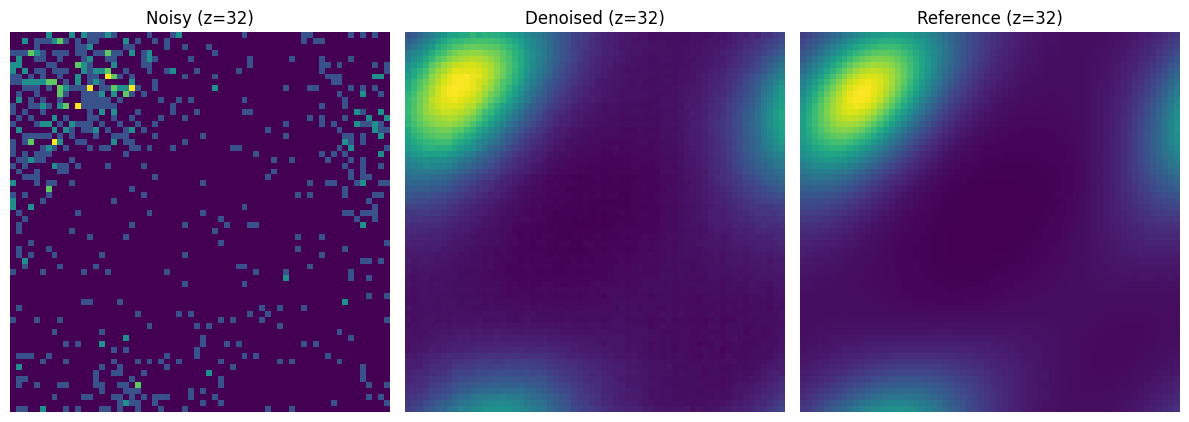


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000010240_scunet_trained_denoised.npy
Sample 10240 | scunet_trained JSD = 0.006937

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0024
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.002144

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0024
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.002144


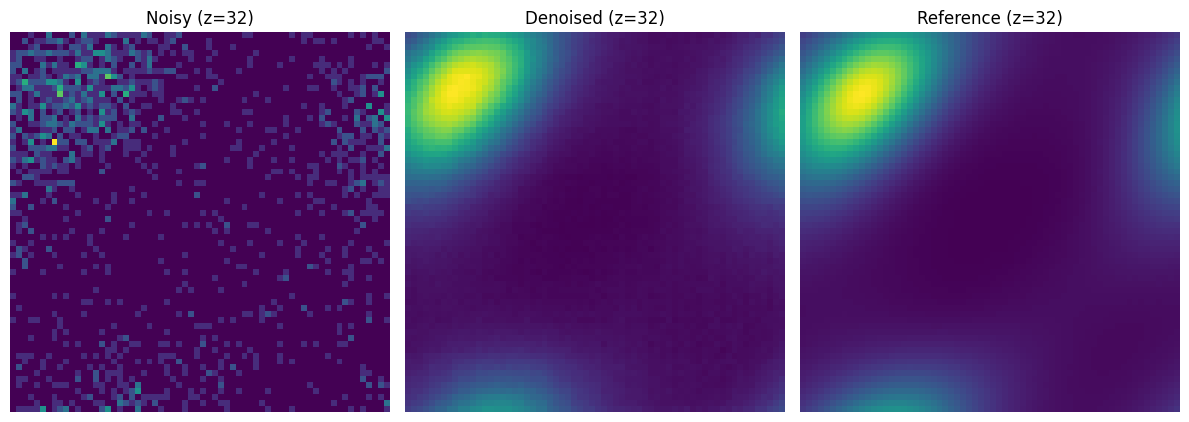


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000020480_scunet_trained_denoised.npy
Sample 20480 | scunet_trained JSD = 0.002144

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.000842

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.000842


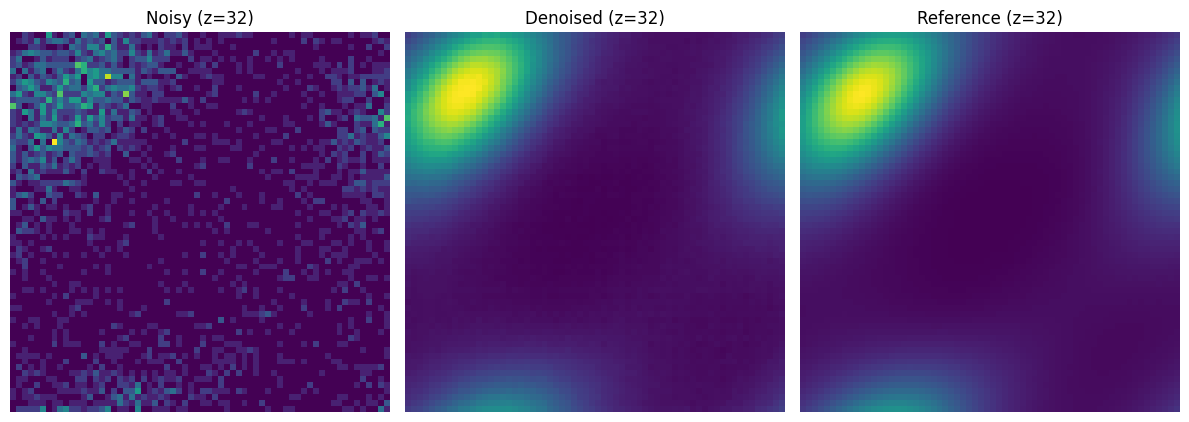


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000040960_scunet_trained_denoised.npy
Sample 40960 | scunet_trained JSD = 0.000842

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.000478

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.000478


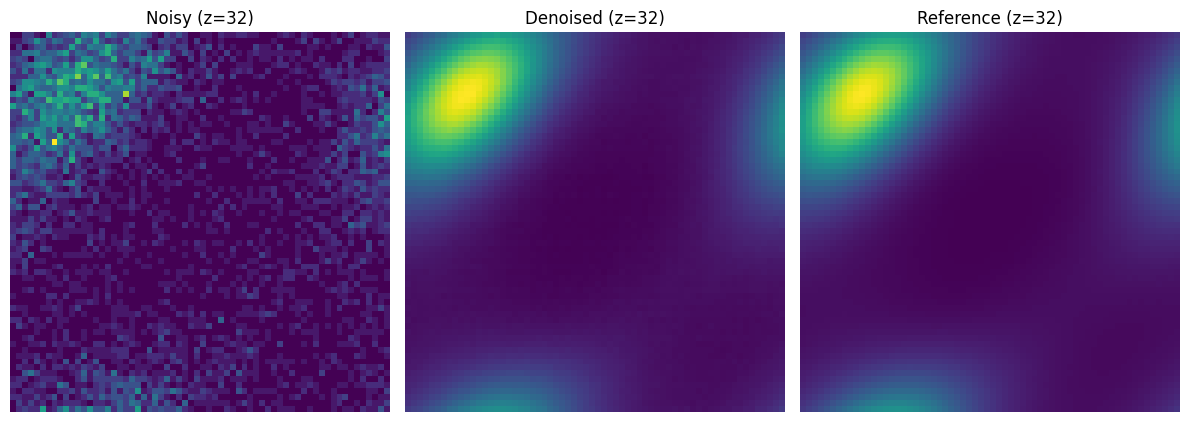


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000081920_scunet_trained_denoised.npy
Sample 81920 | scunet_trained JSD = 0.000478

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000412

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000412


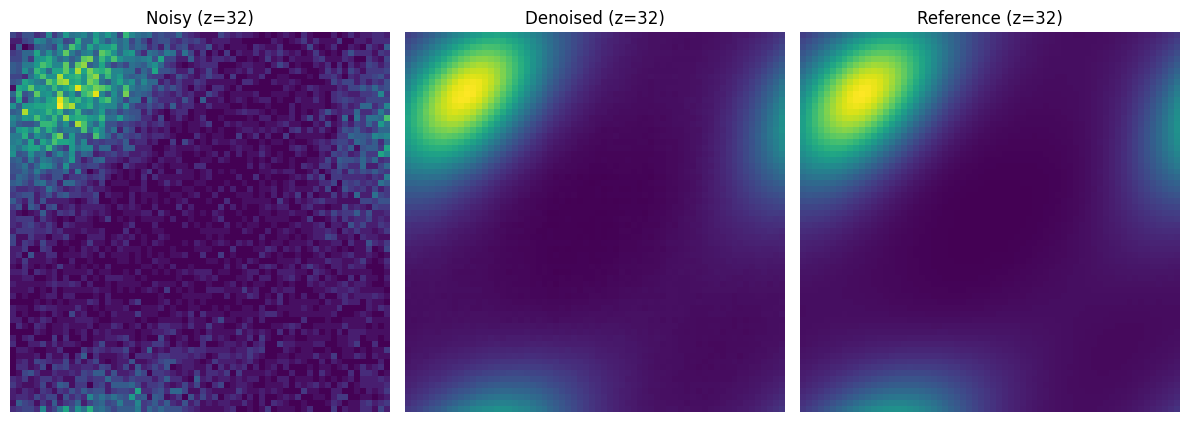


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000163840_scunet_trained_denoised.npy
Sample 163840 | scunet_trained JSD = 0.000412

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000421

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000421


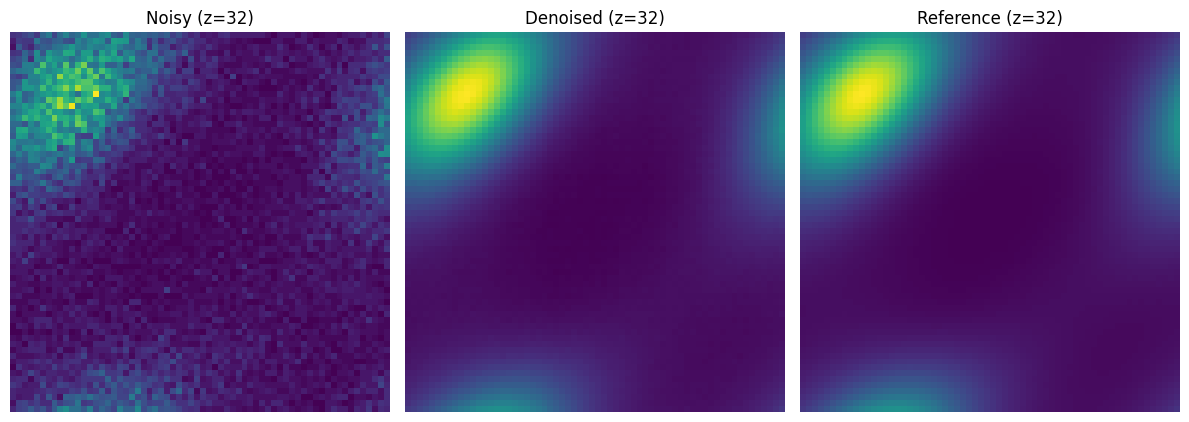


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000327680_scunet_trained_denoised.npy
Sample 327680 | scunet_trained JSD = 0.000421

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000427

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000427


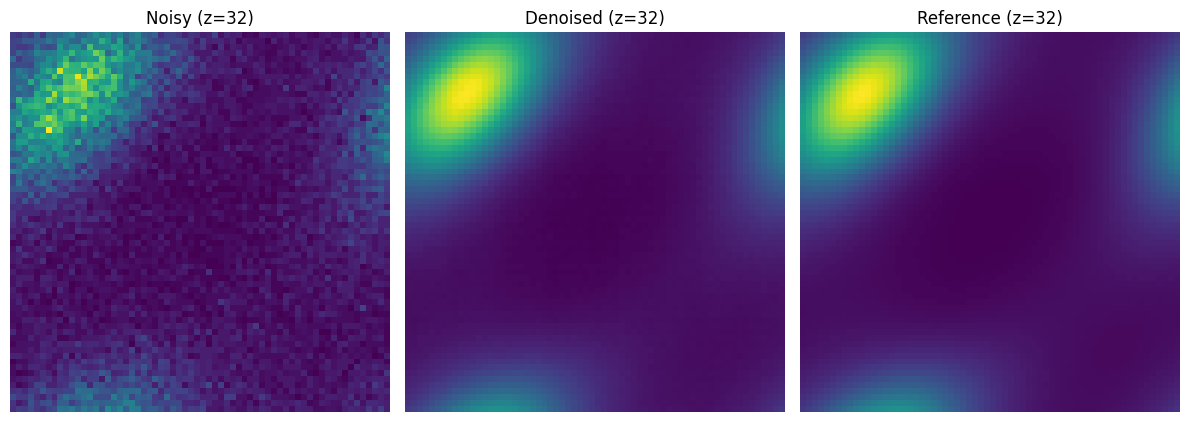


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000430080_scunet_trained_denoised.npy
Sample 430080 | scunet_trained JSD = 0.000427

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000457

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000457


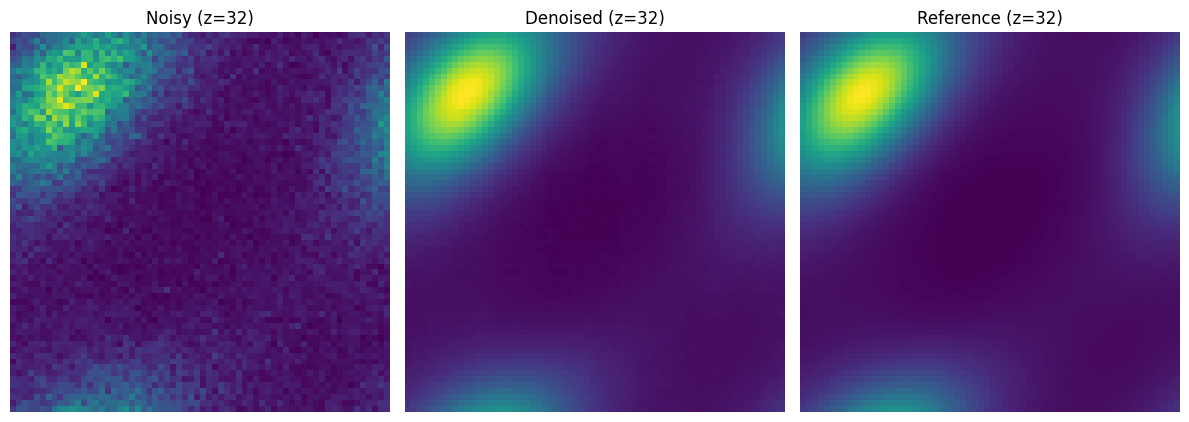


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360_scunet_trained_denoised.npy
Sample 655360 | scunet_trained JSD = 0.000457

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000455

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000455


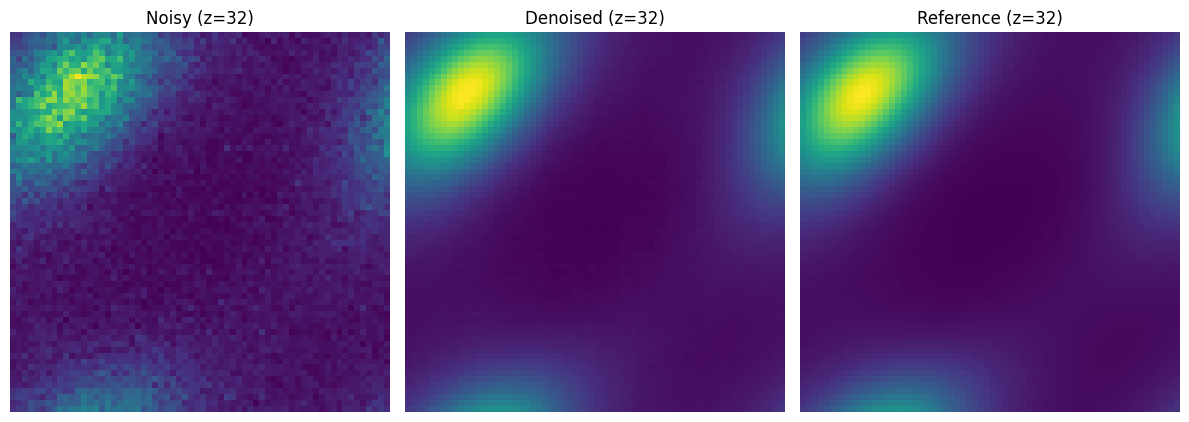


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000860160_scunet_trained_denoised.npy
Sample 860160 | scunet_trained JSD = 0.000455

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000478

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000478


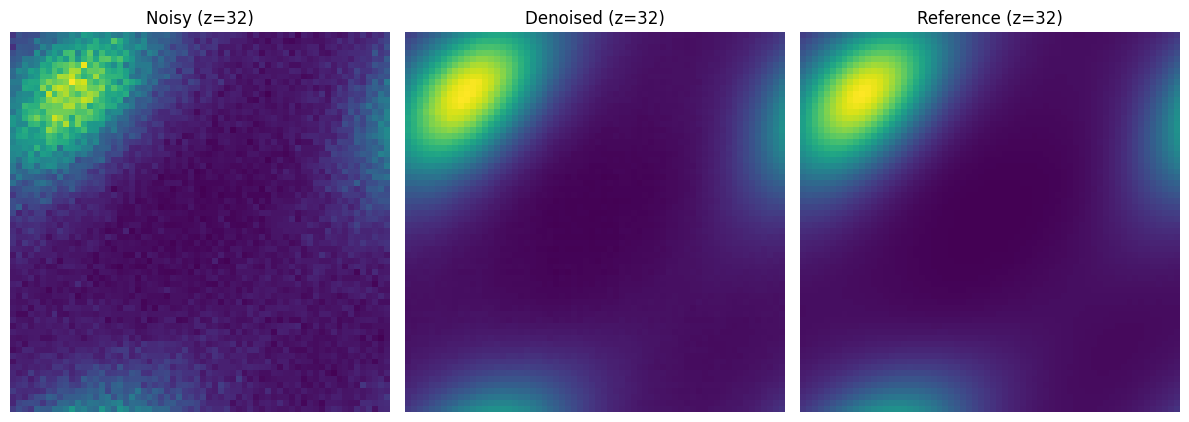


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001310720_scunet_trained_denoised.npy
Sample 1310720 | scunet_trained JSD = 0.000478

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000420

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000420


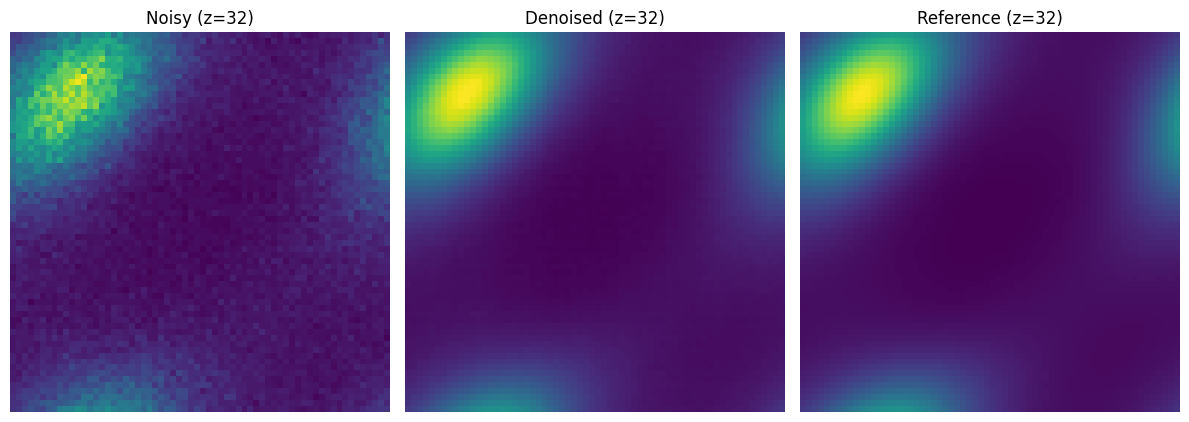


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001720320_scunet_trained_denoised.npy
Sample 1720320 | scunet_trained JSD = 0.000420

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000358

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000358


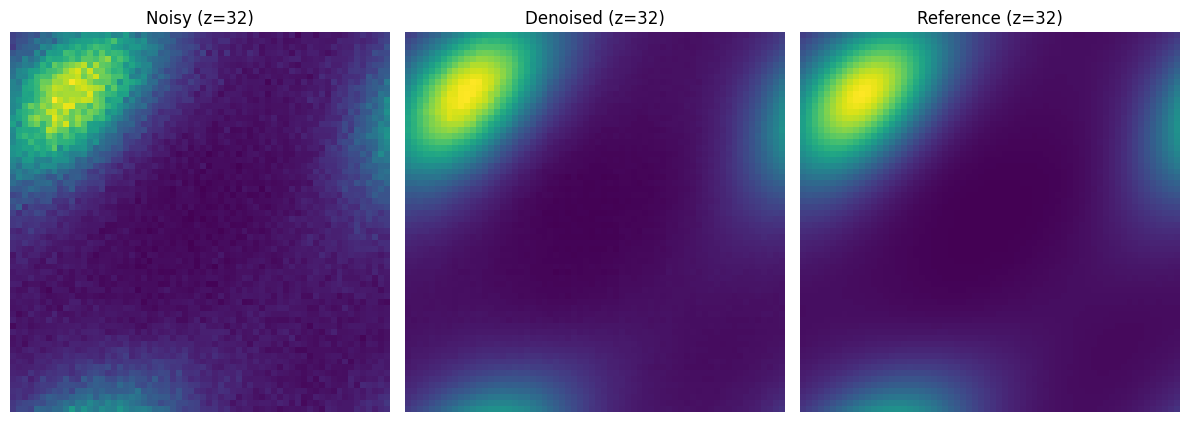


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0002621440_scunet_trained_denoised.npy
Sample 2621440 | scunet_trained JSD = 0.000358

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000345

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000345


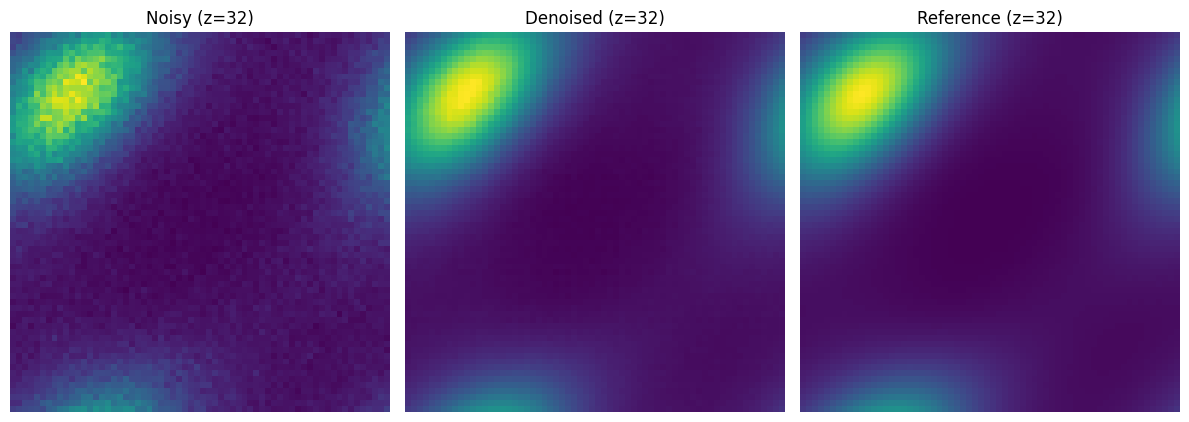


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0003440640_scunet_trained_denoised.npy
Sample 3440640 | scunet_trained JSD = 0.000345

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000303

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000303


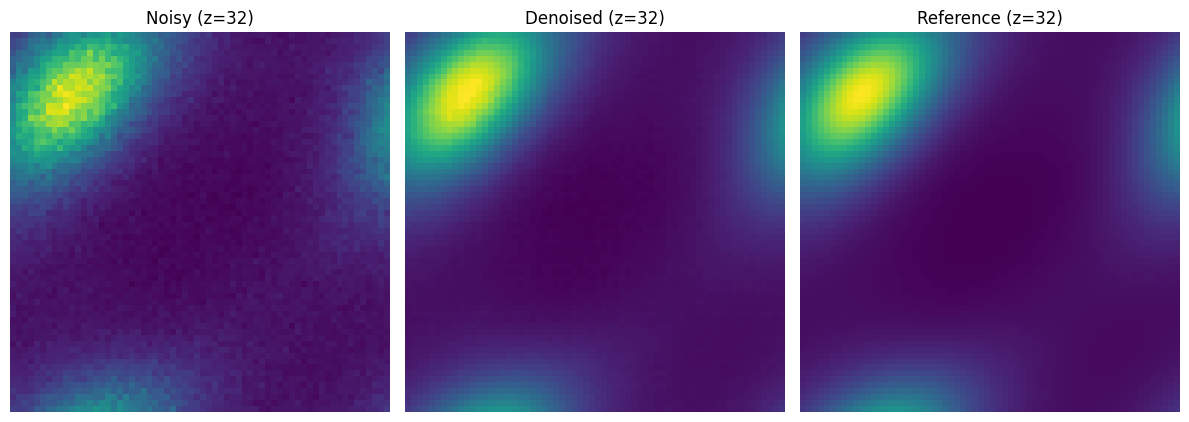


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005160960_scunet_trained_denoised.npy
Sample 5160960 | scunet_trained JSD = 0.000303

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000300

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000300


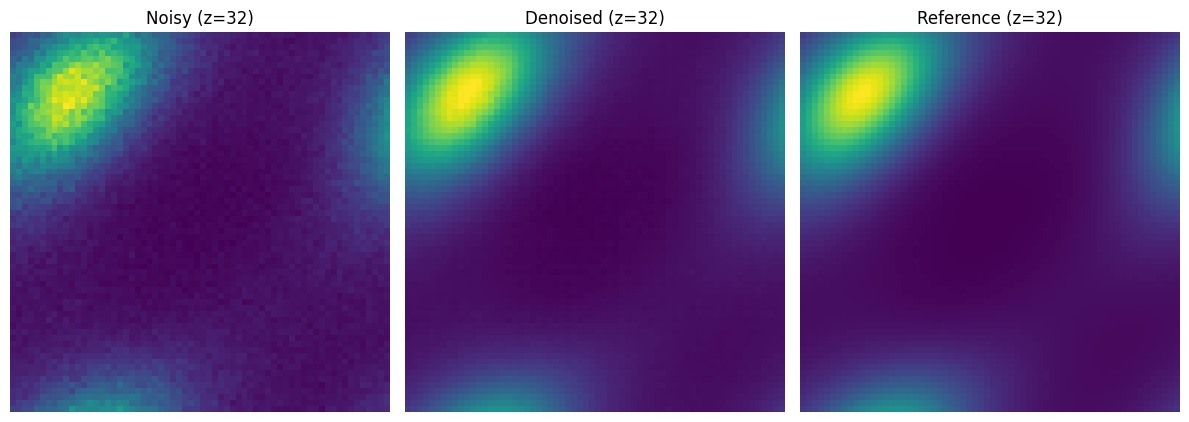


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005242880_scunet_trained_denoised.npy
Sample 5242880 | scunet_trained JSD = 0.000300

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000287

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000287


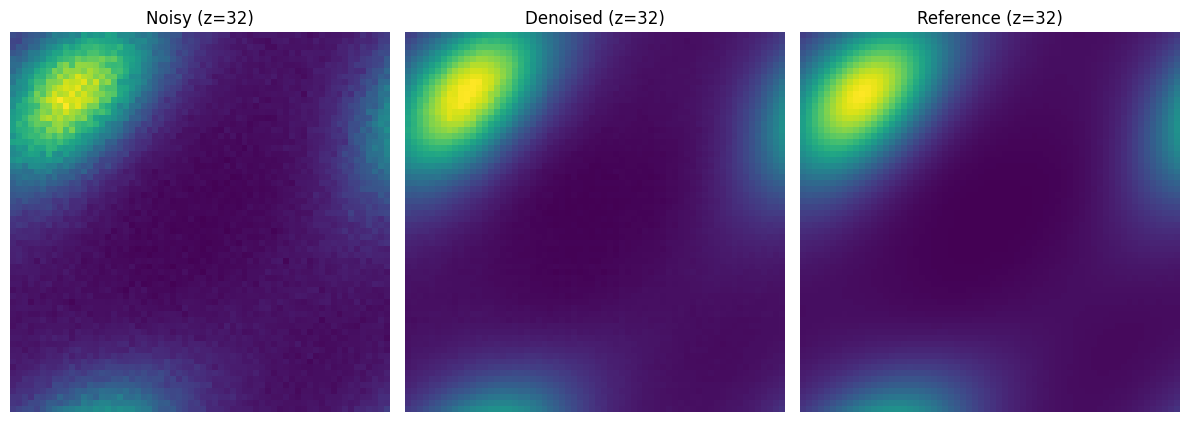


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0006881280_scunet_trained_denoised.npy
Sample 6881280 | scunet_trained JSD = 0.000287

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000296

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000296


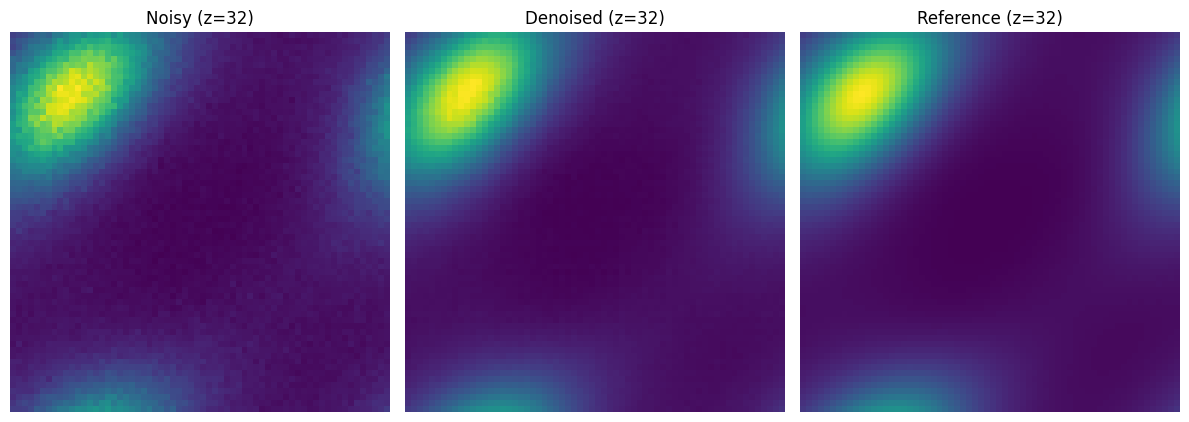


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010321920_scunet_trained_denoised.npy
Sample 10321920 | scunet_trained JSD = 0.000296

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000293

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000293


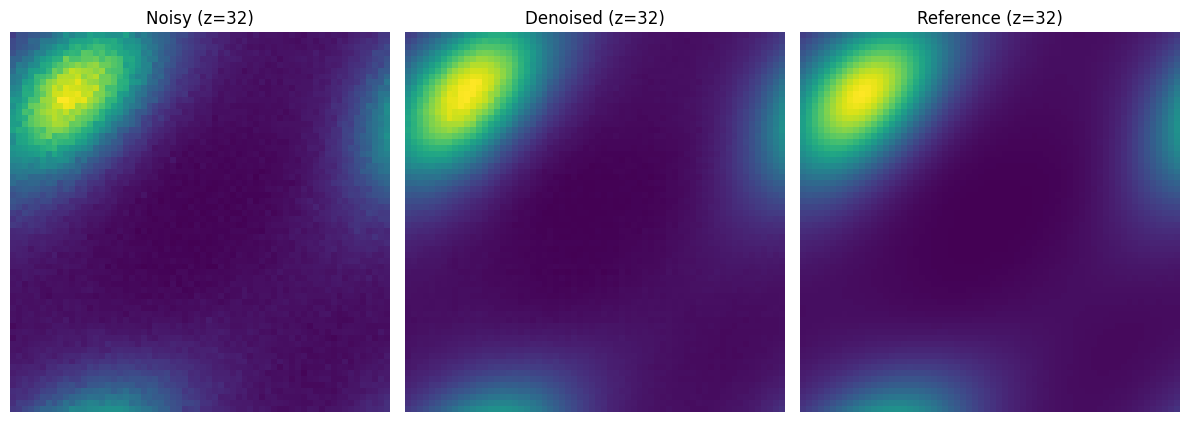


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010485760_scunet_trained_denoised.npy
Sample 10485760 | scunet_trained JSD = 0.000293

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000290

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000290


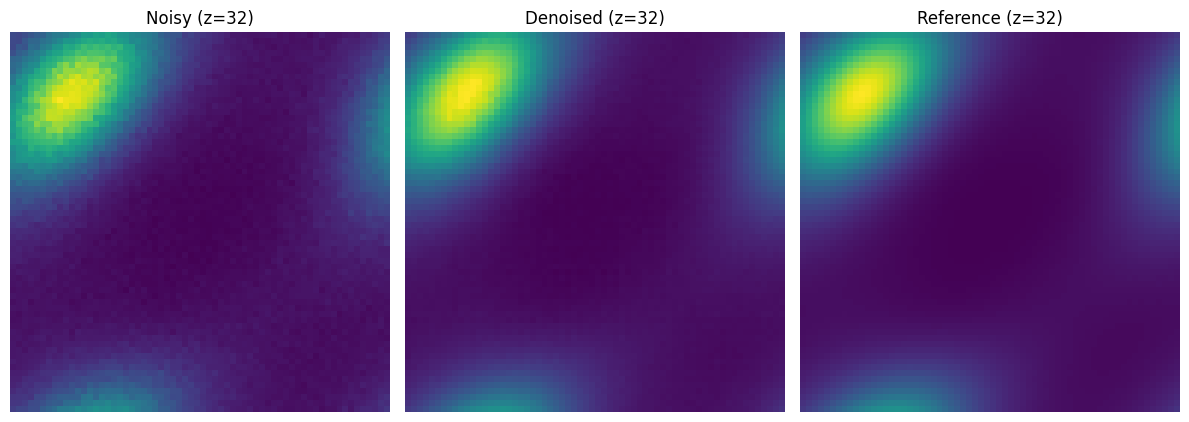


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0013762560_scunet_trained_denoised.npy
Sample 13762560 | scunet_trained JSD = 0.000290

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000311

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000311


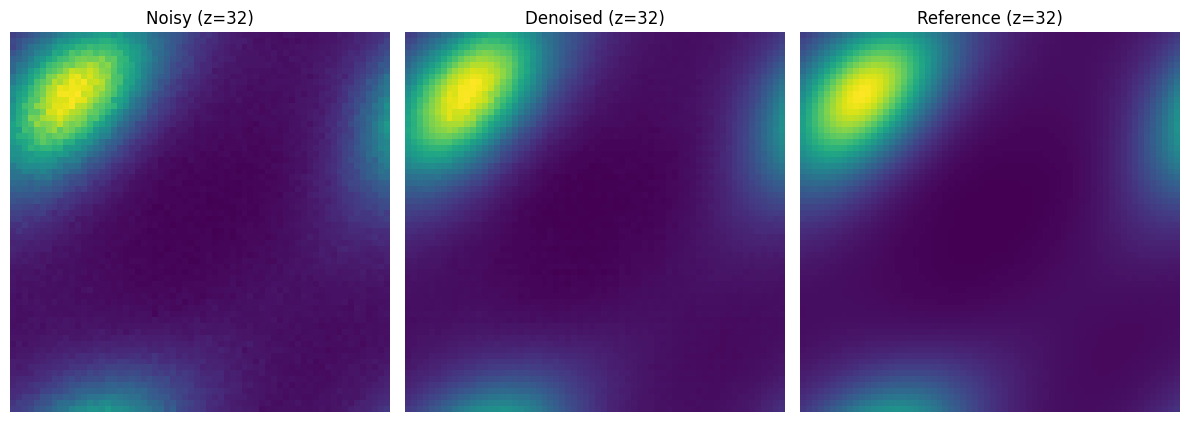


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0020643840_scunet_trained_denoised.npy
Sample 20643840 | scunet_trained JSD = 0.000311

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000312

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000312


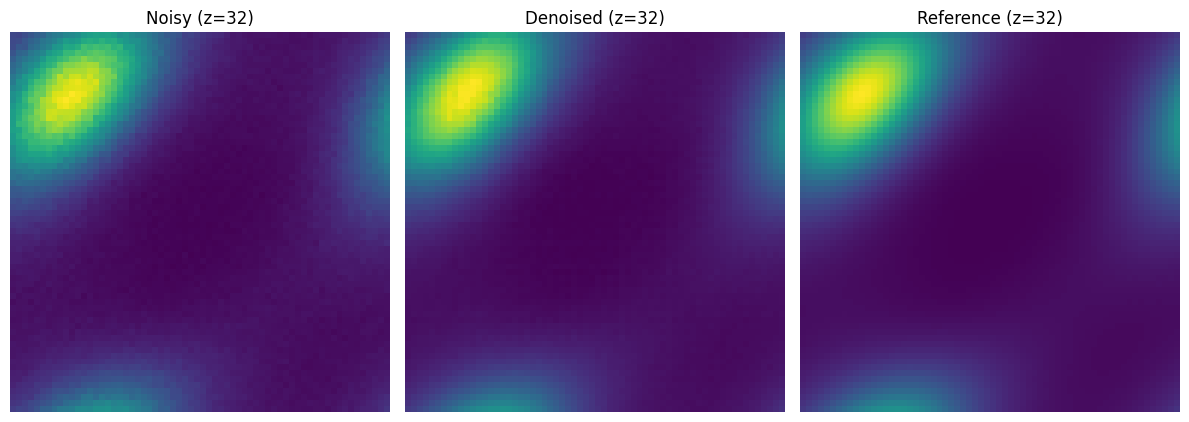


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0027525120_scunet_trained_denoised.npy
Sample 27525120 | scunet_trained JSD = 0.000312

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000330

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000330


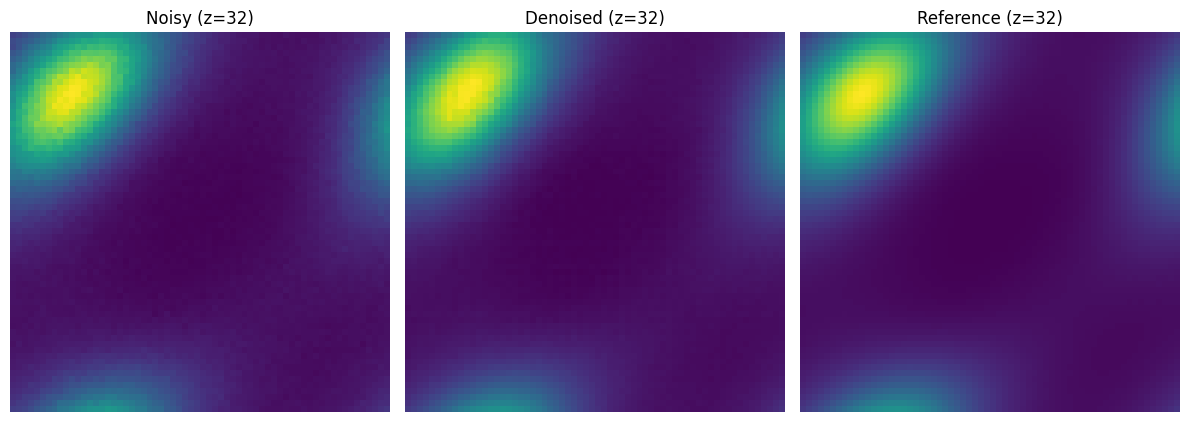


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0041287680_scunet_trained_denoised.npy
Sample 41287680 | scunet_trained JSD = 0.000330

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000339

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000339


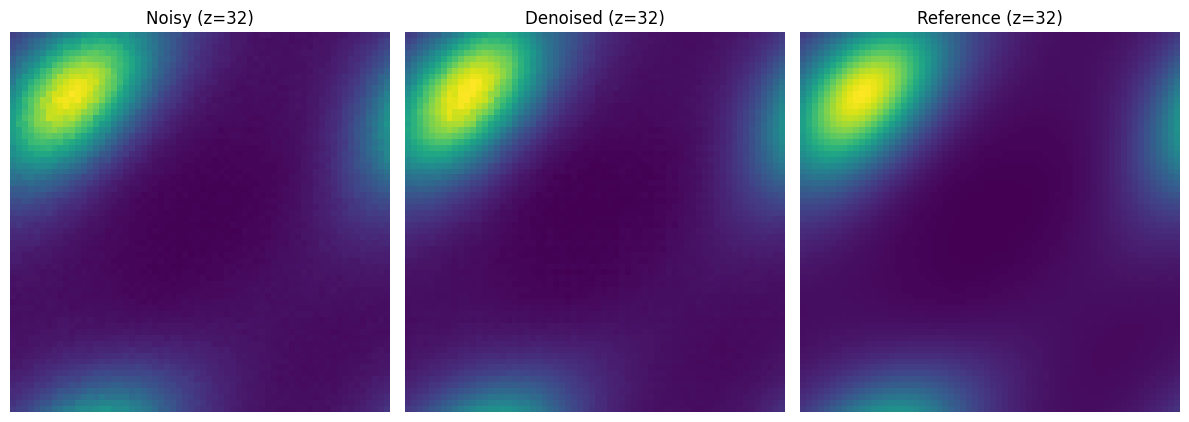


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0055050240_scunet_trained_denoised.npy
Sample 55050240 | scunet_trained JSD = 0.000339

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000350

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000350


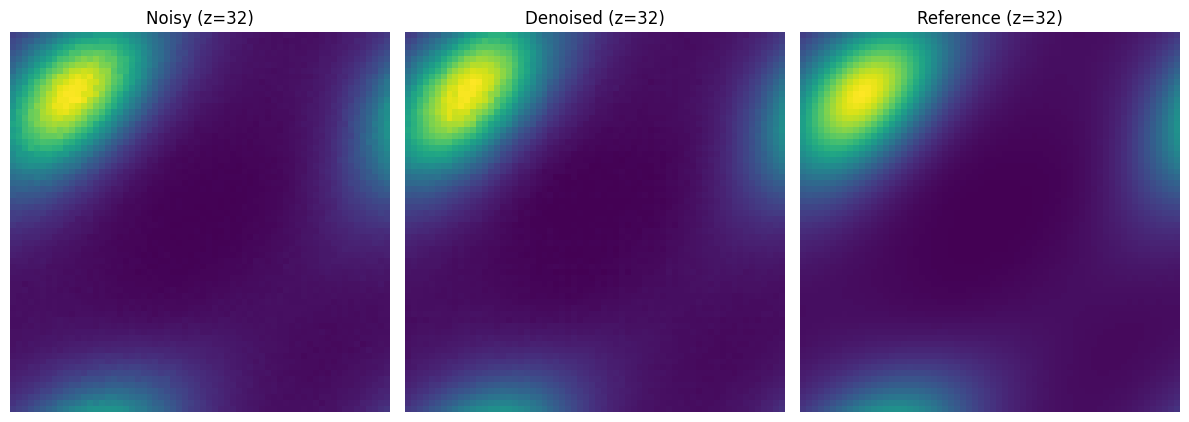


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0082575360_scunet_trained_denoised.npy
Sample 82575360 | scunet_trained JSD = 0.000350

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000356

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000356


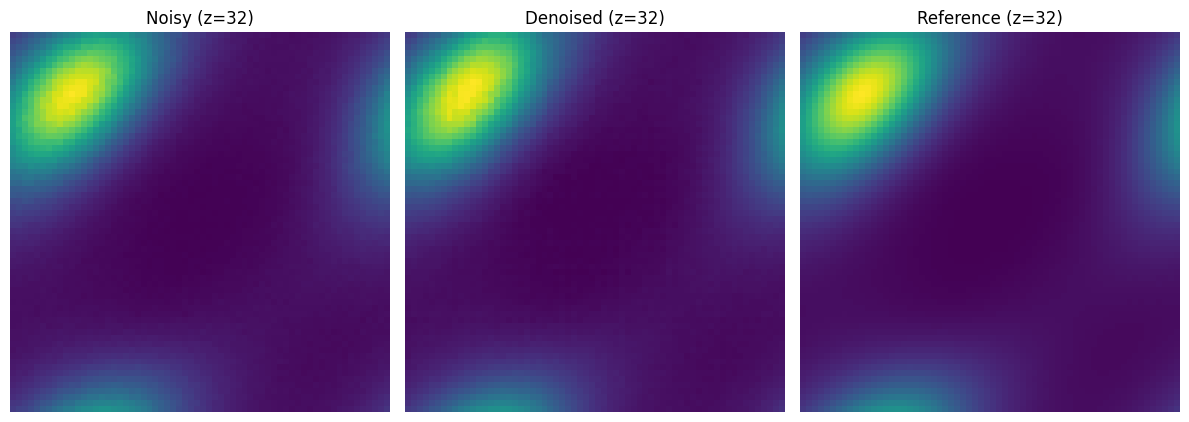


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0110100480_scunet_trained_denoised.npy
Sample 110100480 | scunet_trained JSD = 0.000356

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000364

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000364


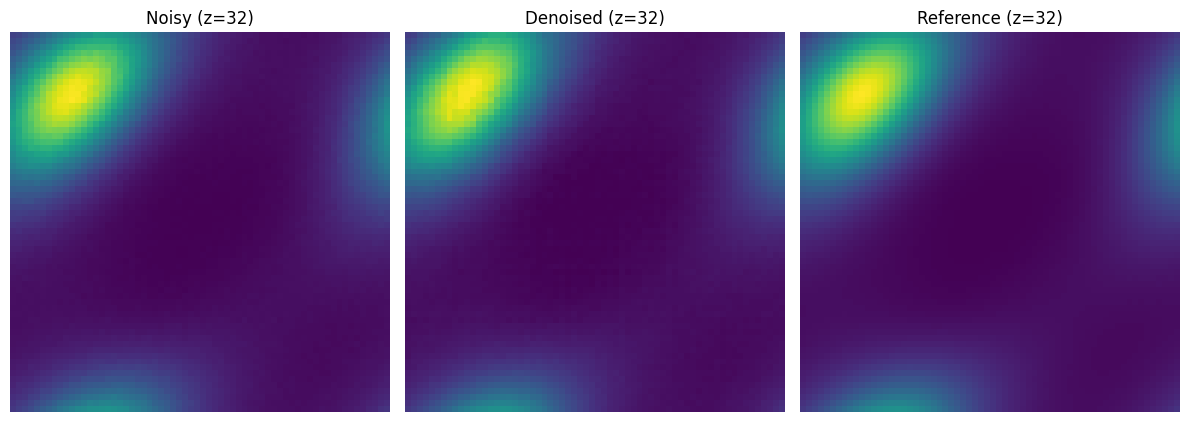


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0165150720_scunet_trained_denoised.npy
Sample 165150720 | scunet_trained JSD = 0.000364

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000369

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000369


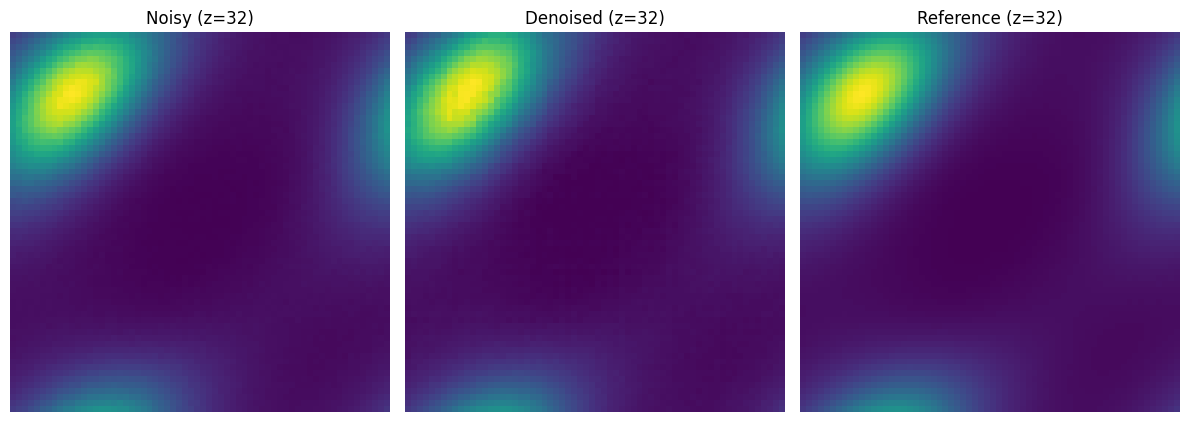


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0220200960_scunet_trained_denoised.npy
Sample 220200960 | scunet_trained JSD = 0.000369

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000377

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000377


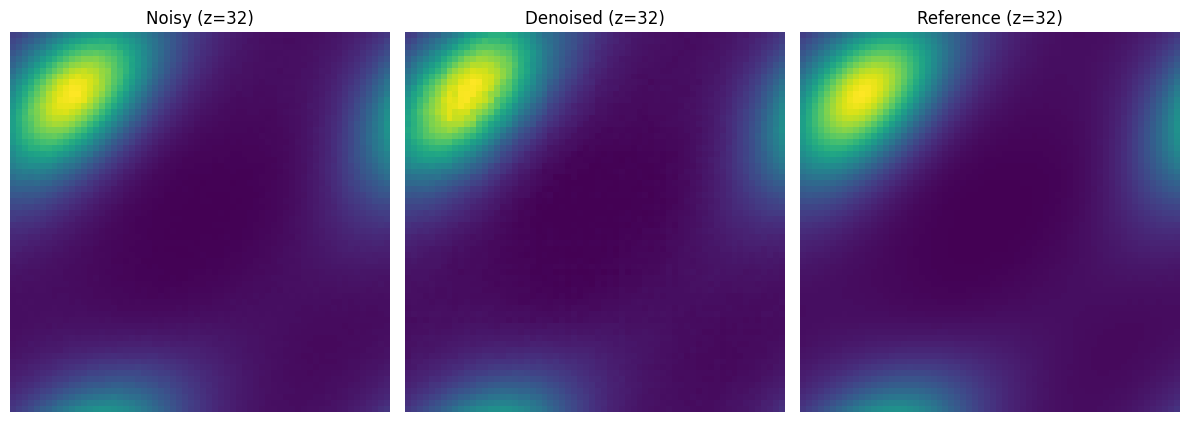


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0330301440_scunet_trained_denoised.npy
Sample 330301440 | scunet_trained JSD = 0.000377

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.000381

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.000381


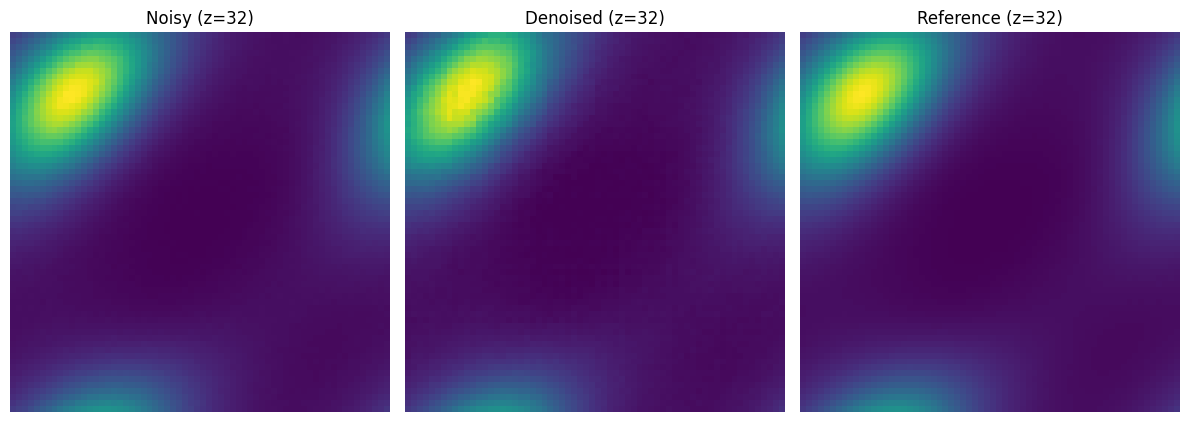


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0440401920_scunet_trained_denoised.npy
Sample 440401920 | scunet_trained JSD = 0.000381

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.000388

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.000388


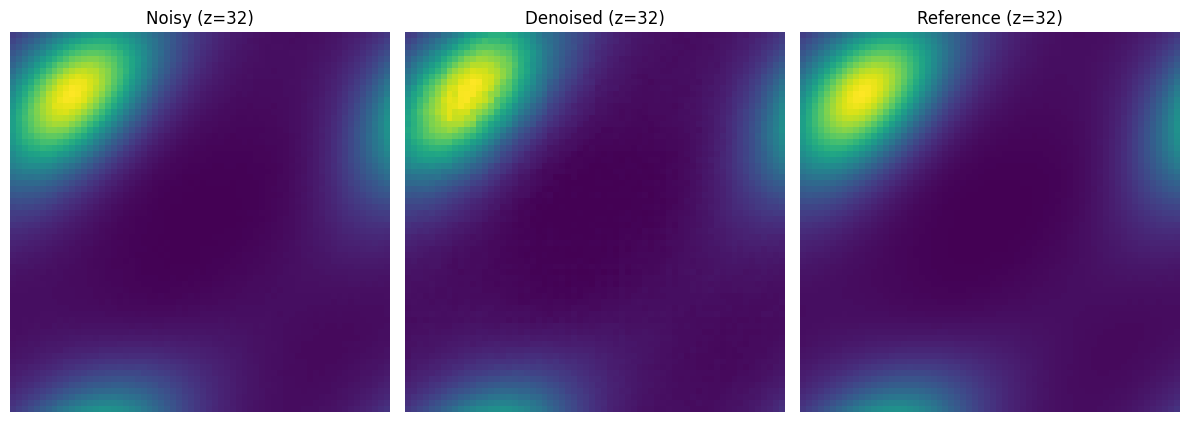


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0660602880_scunet_trained_denoised.npy
Sample 660602880 | scunet_trained JSD = 0.000388

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000394

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000394


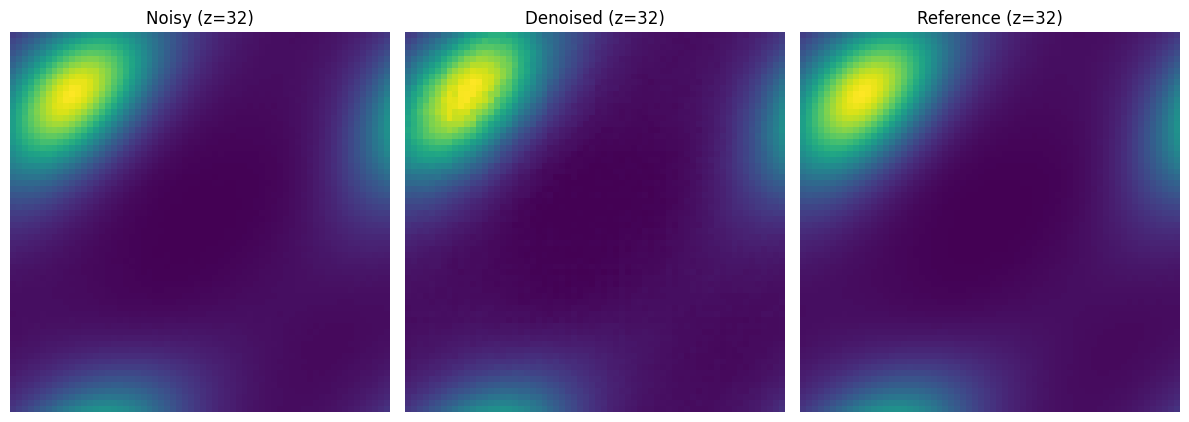


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_1321205760_scunet_trained_denoised.npy
Sample 1321205760 | scunet_trained JSD = 0.000394

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000400

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000400


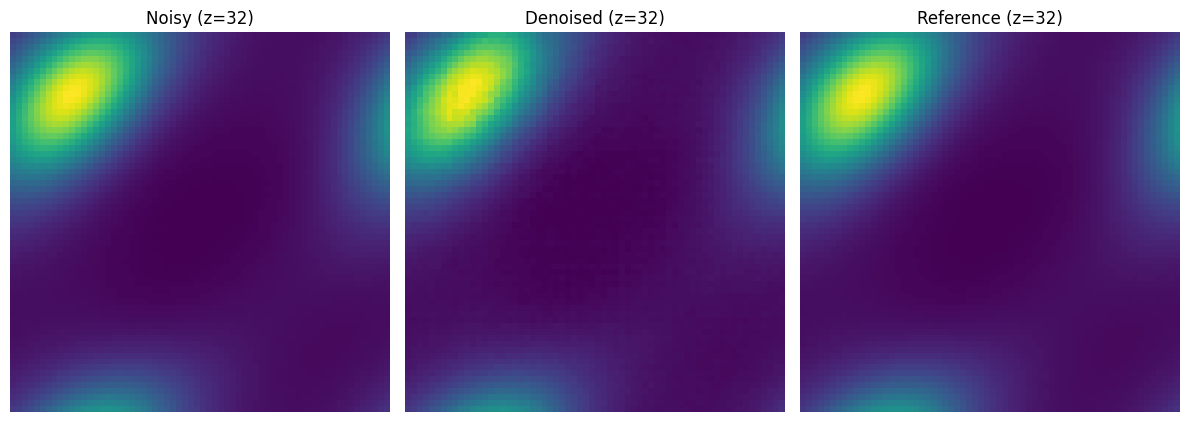


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_2642411520_scunet_trained_denoised.npy
Sample 2642411520 | scunet_trained JSD = 0.000400

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000403

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000403


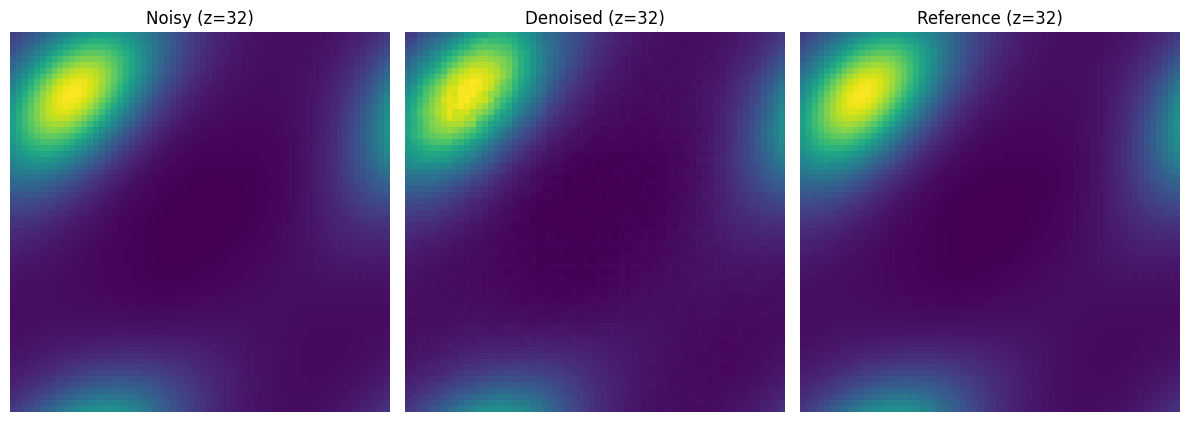


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_5284823040_scunet_trained_denoised.npy
Sample 5284823040 | scunet_trained JSD = 0.000403

=== Running model: scunet_pre ===
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.00

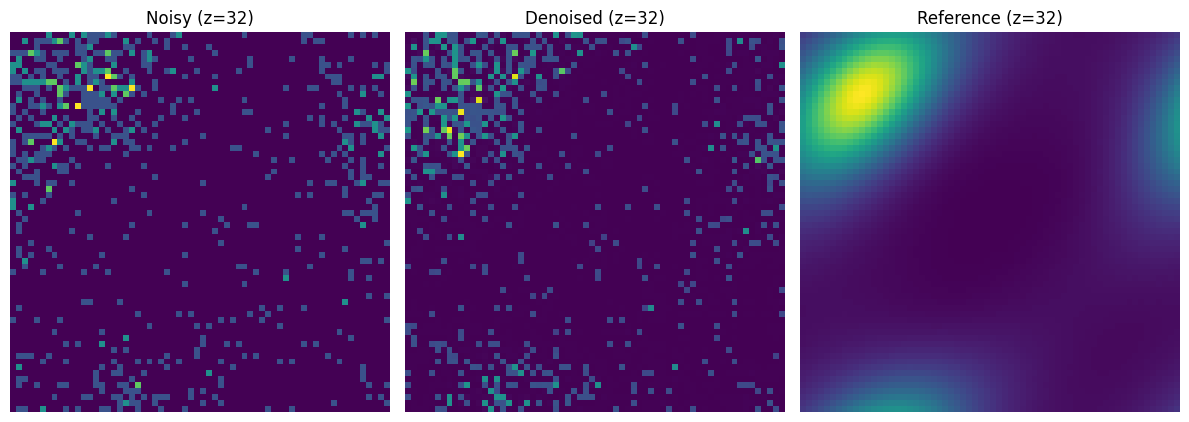


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000010240_scunet_pre_denoised.npy
Sample 10240 | scunet_pre JSD = 0.128566
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000

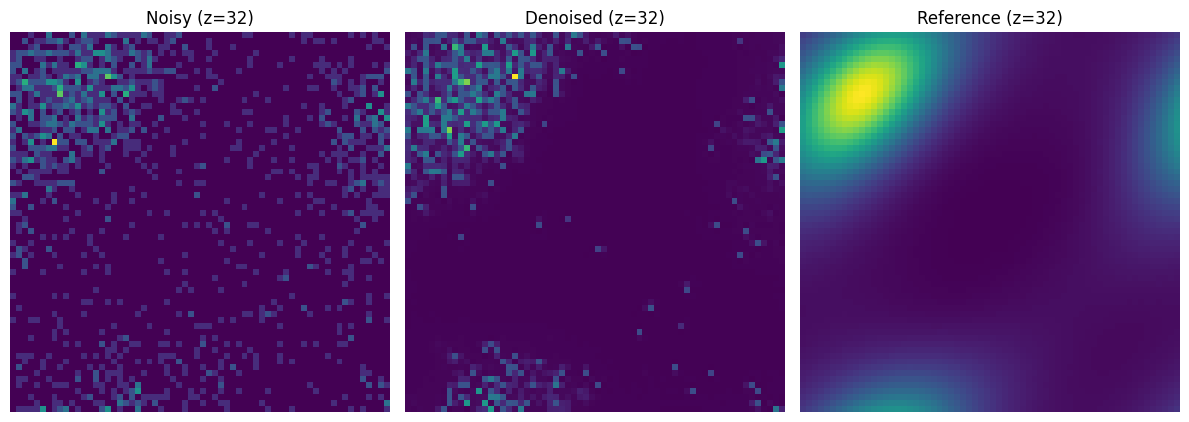


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000020480_scunet_pre_denoised.npy
Sample 20480 | scunet_pre JSD = 0.080876
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000

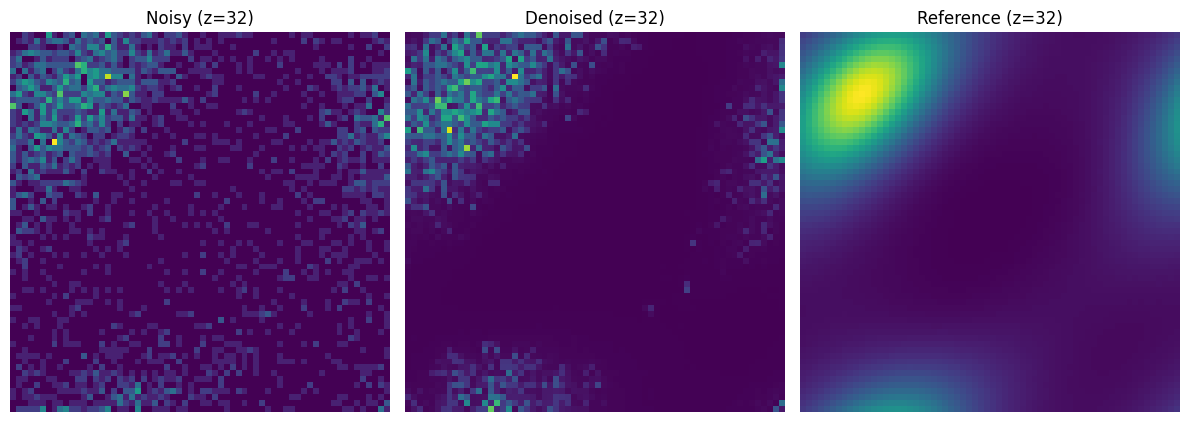


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000040960_scunet_pre_denoised.npy
Sample 40960 | scunet_pre JSD = 0.044298
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000

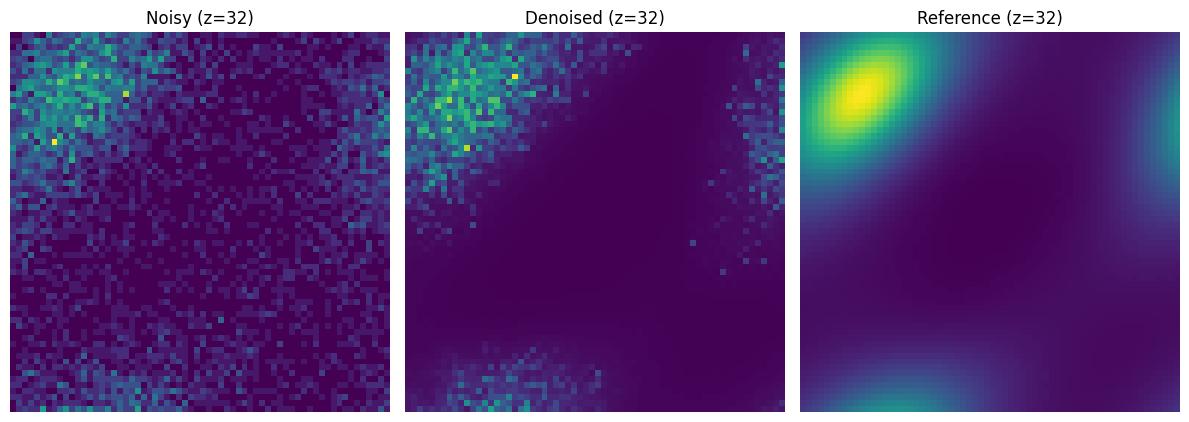


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000081920_scunet_pre_denoised.npy
Sample 81920 | scunet_pre JSD = 0.024921
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000

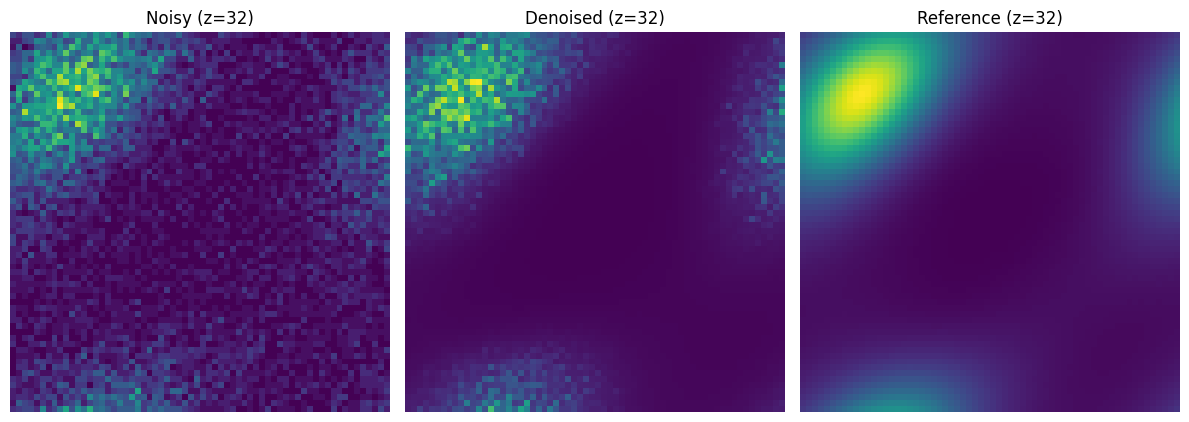


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000163840_scunet_pre_denoised.npy
Sample 163840 | scunet_pre JSD = 0.014106
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.00

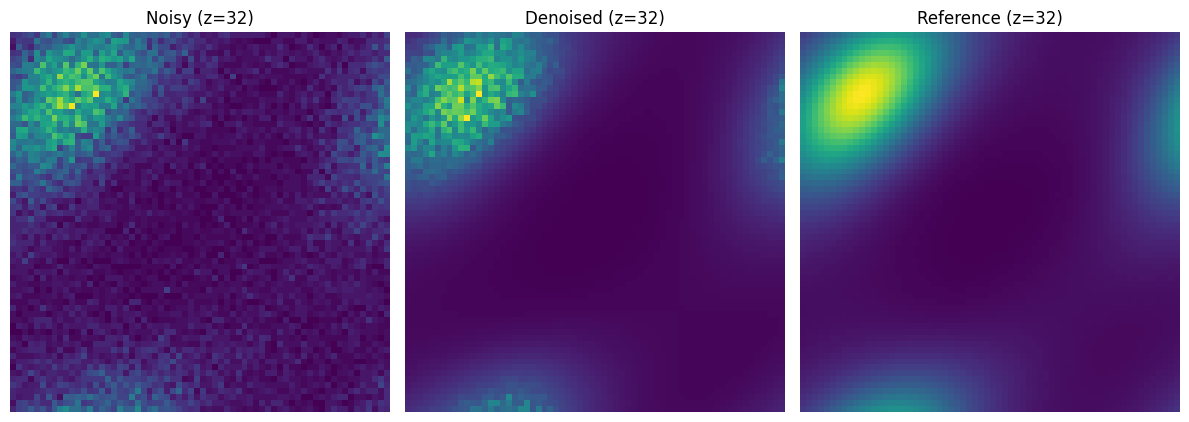


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000327680_scunet_pre_denoised.npy
Sample 327680 | scunet_pre JSD = 0.008476
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.00

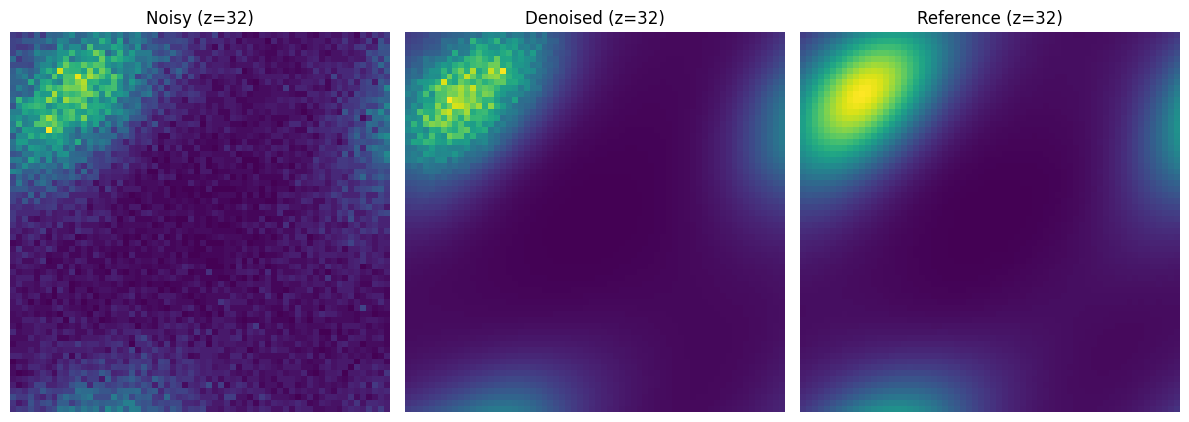


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000430080_scunet_pre_denoised.npy
Sample 430080 | scunet_pre JSD = 0.006903
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.00

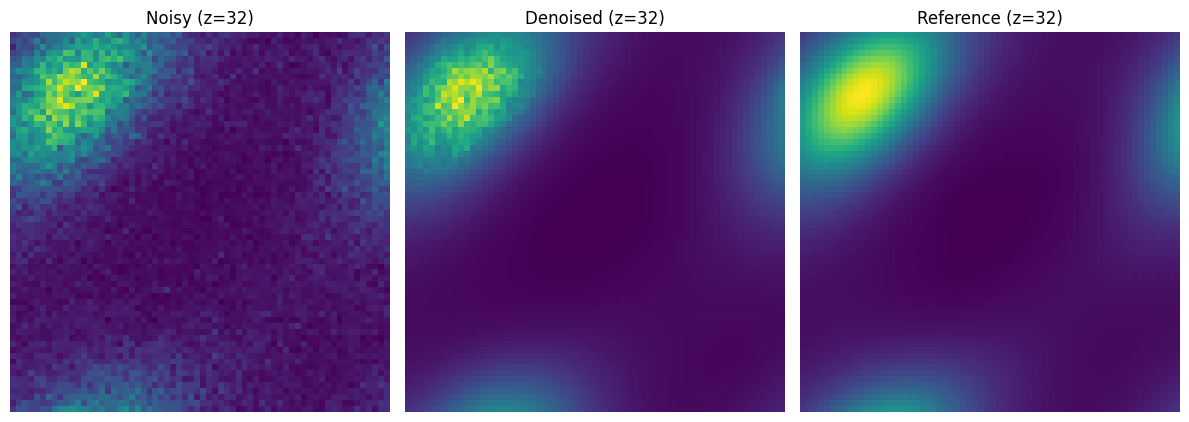


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360_scunet_pre_denoised.npy
Sample 655360 | scunet_pre JSD = 0.005225
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.00

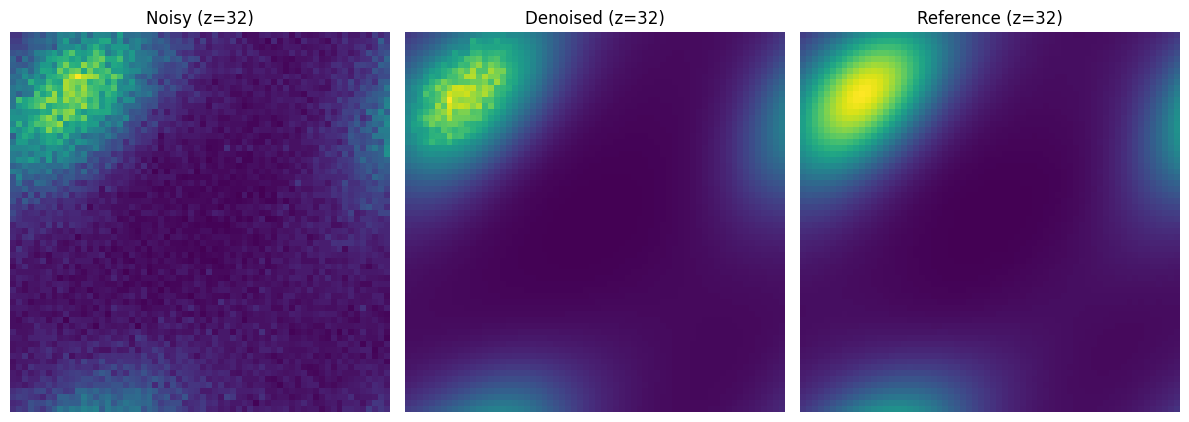


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000860160_scunet_pre_denoised.npy
Sample 860160 | scunet_pre JSD = 0.004717
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.00

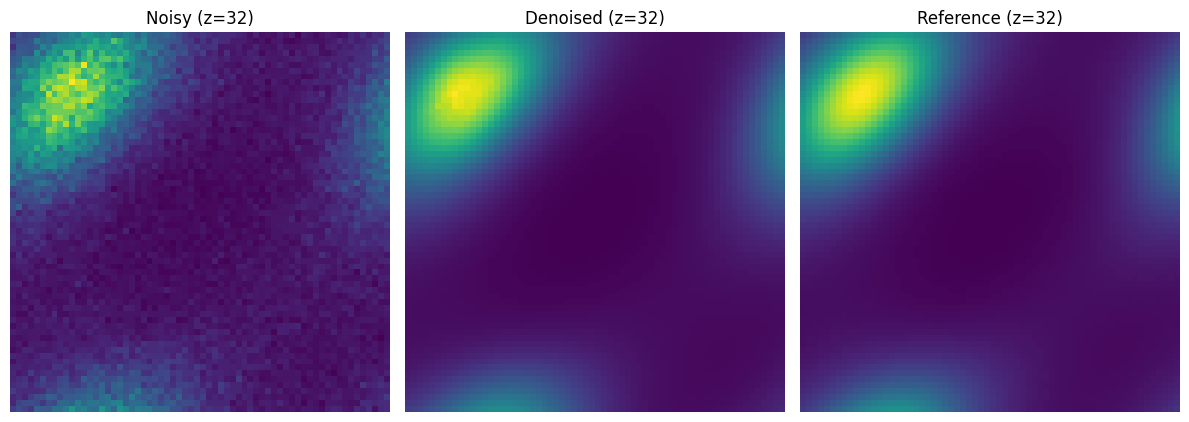


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001310720_scunet_pre_denoised.npy
Sample 1310720 | scunet_pre JSD = 0.003994
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.0

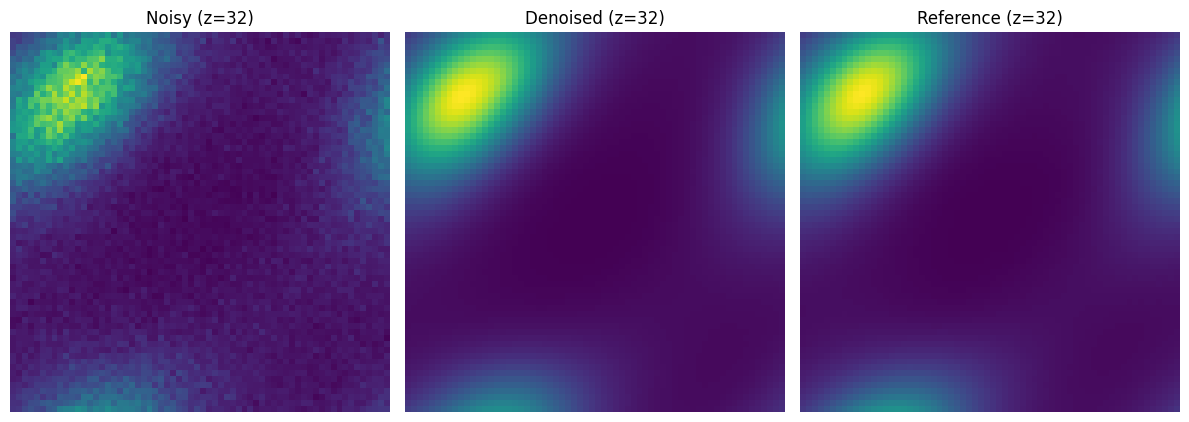


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001720320_scunet_pre_denoised.npy
Sample 1720320 | scunet_pre JSD = 0.003273
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.0

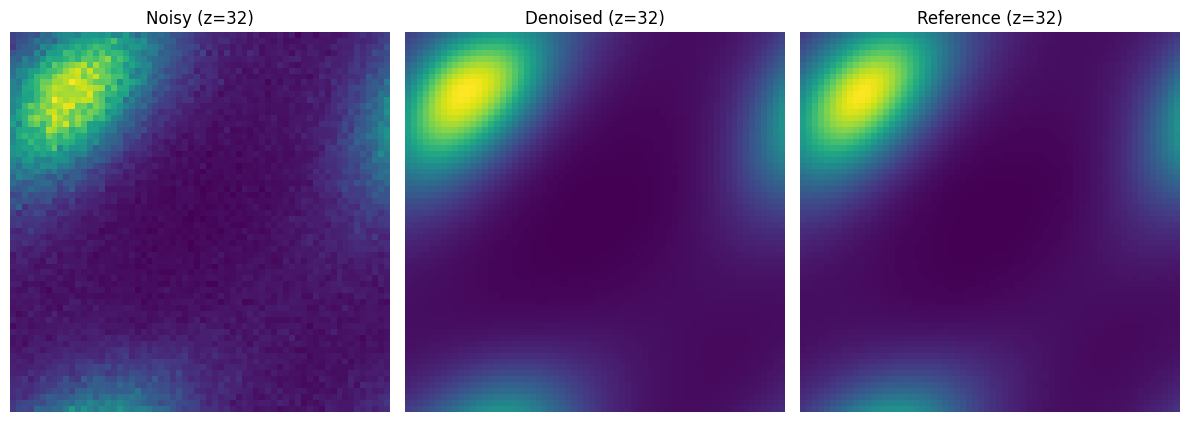


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0002621440_scunet_pre_denoised.npy
Sample 2621440 | scunet_pre JSD = 0.002396
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.0

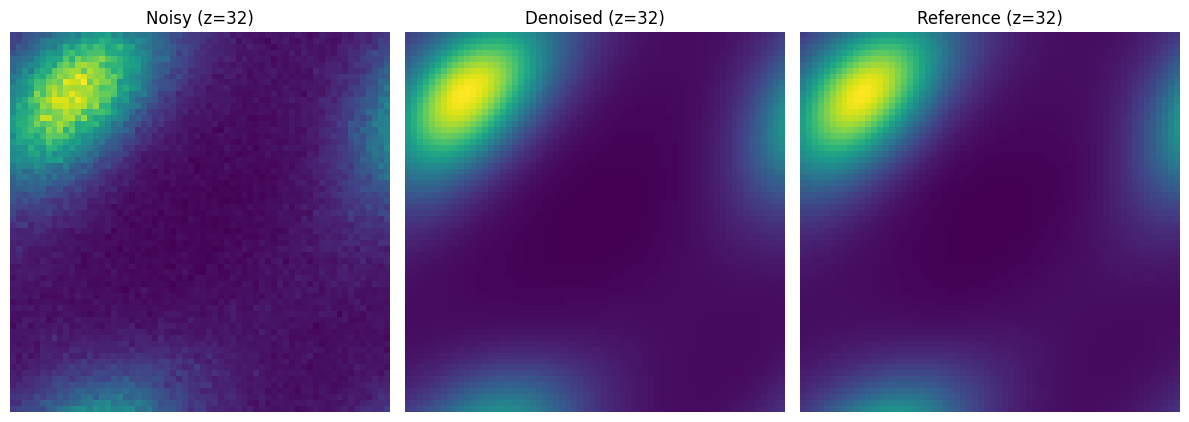


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0003440640_scunet_pre_denoised.npy
Sample 3440640 | scunet_pre JSD = 0.002001
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.0

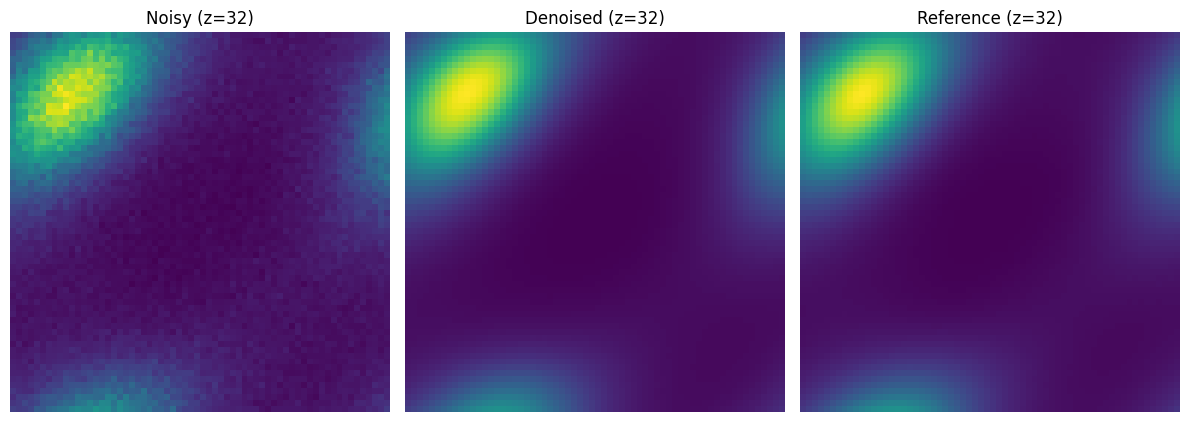


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005160960_scunet_pre_denoised.npy
Sample 5160960 | scunet_pre JSD = 0.001374
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.0

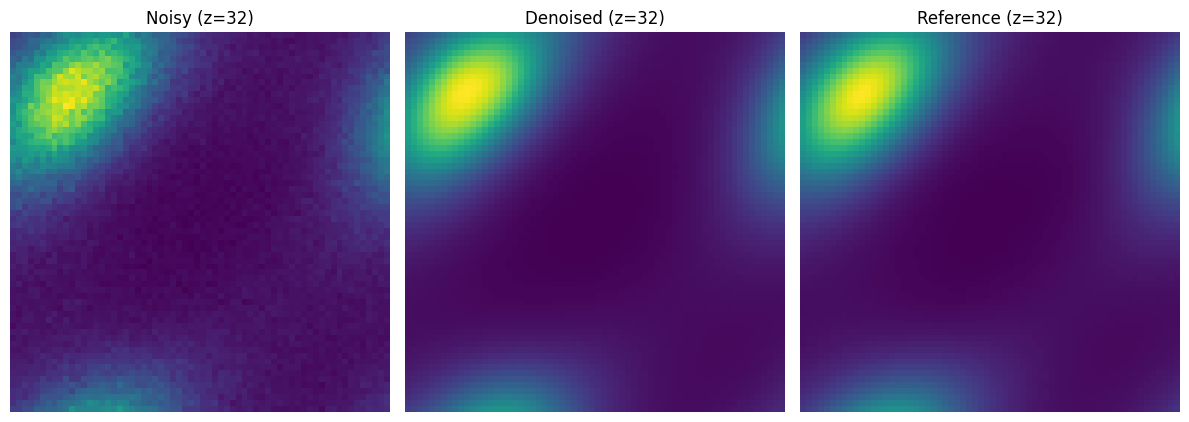


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005242880_scunet_pre_denoised.npy
Sample 5242880 | scunet_pre JSD = 0.001289
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.0

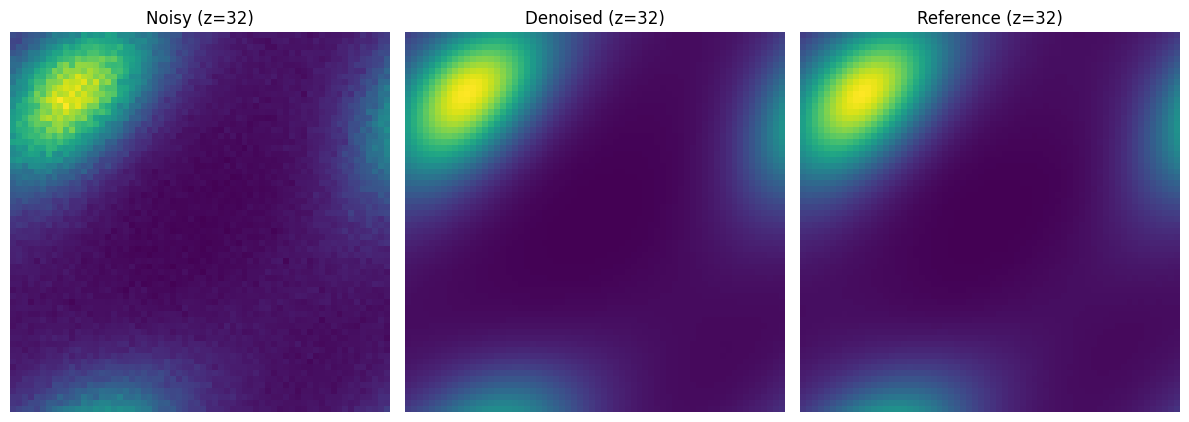


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0006881280_scunet_pre_denoised.npy
Sample 6881280 | scunet_pre JSD = 0.001096
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.0

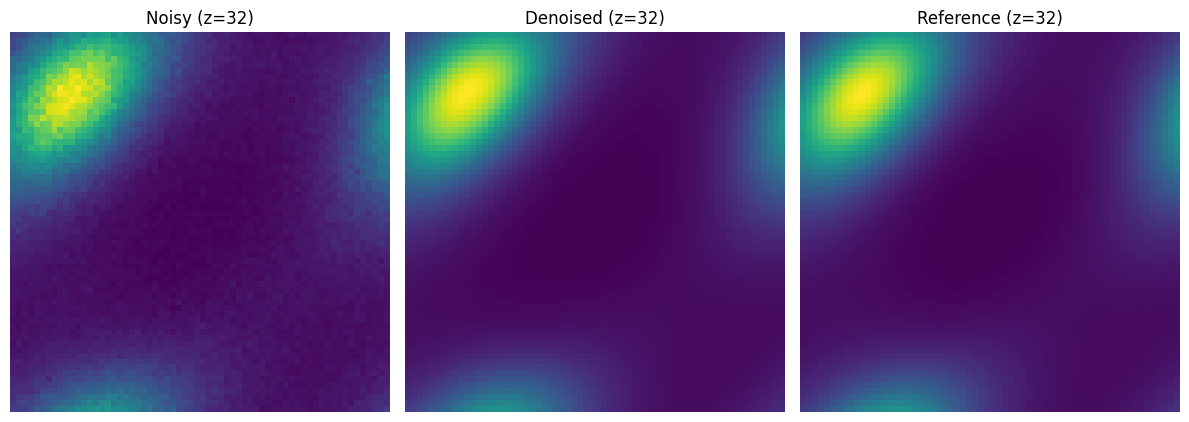


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010321920_scunet_pre_denoised.npy
Sample 10321920 | scunet_pre JSD = 0.000725
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

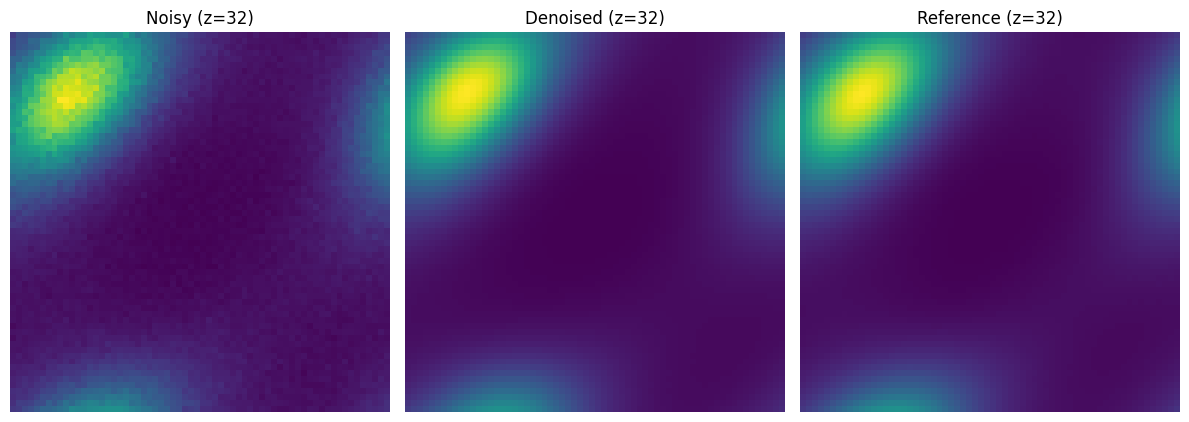


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010485760_scunet_pre_denoised.npy
Sample 10485760 | scunet_pre JSD = 0.000698
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

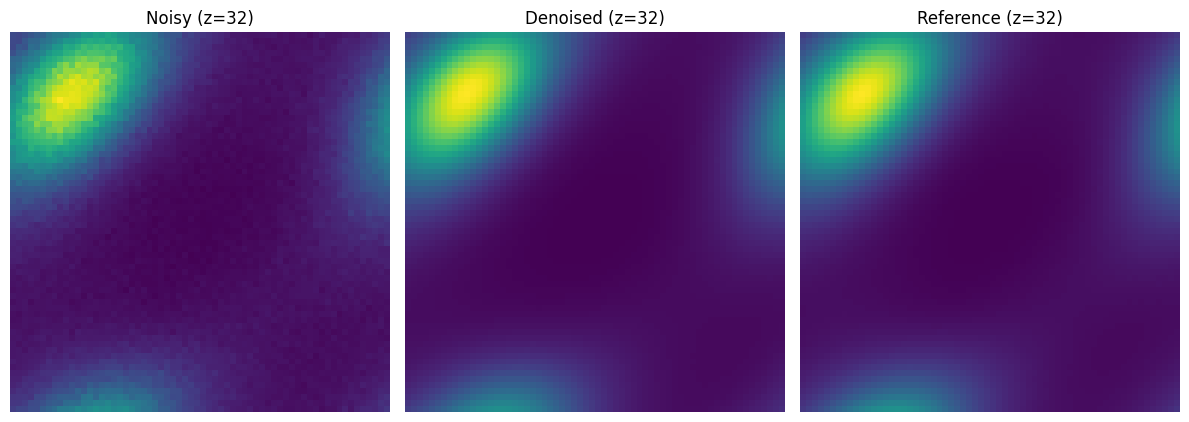


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0013762560_scunet_pre_denoised.npy
Sample 13762560 | scunet_pre JSD = 0.000586
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

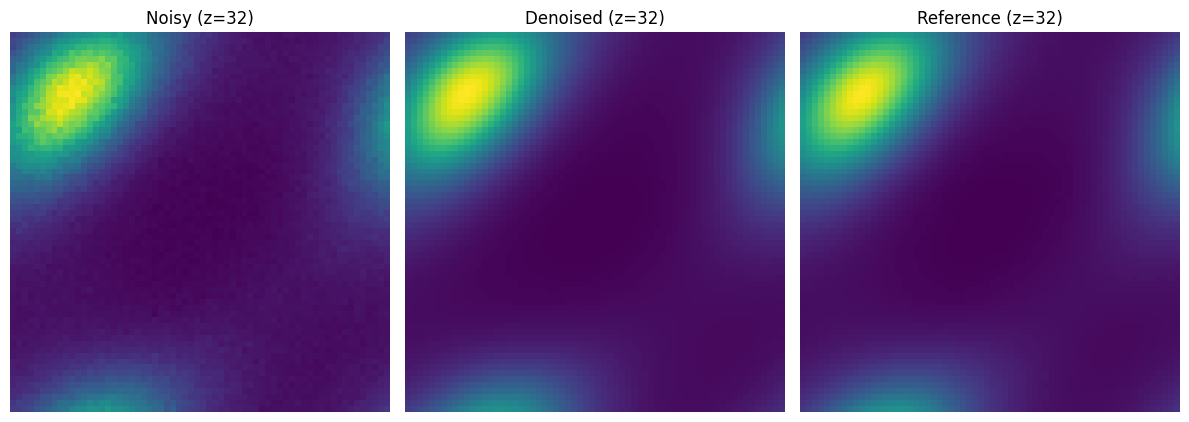


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0020643840_scunet_pre_denoised.npy
Sample 20643840 | scunet_pre JSD = 0.000381
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

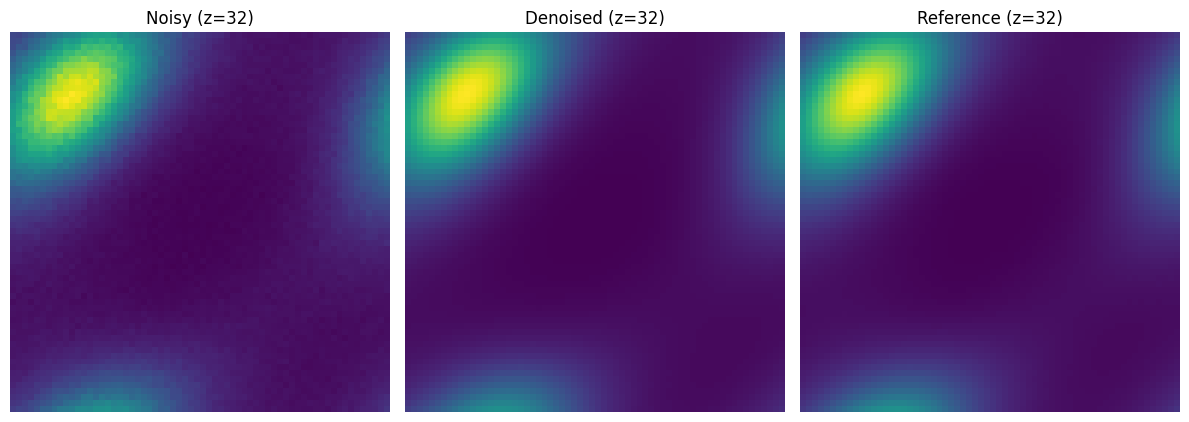


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0027525120_scunet_pre_denoised.npy
Sample 27525120 | scunet_pre JSD = 0.000277
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

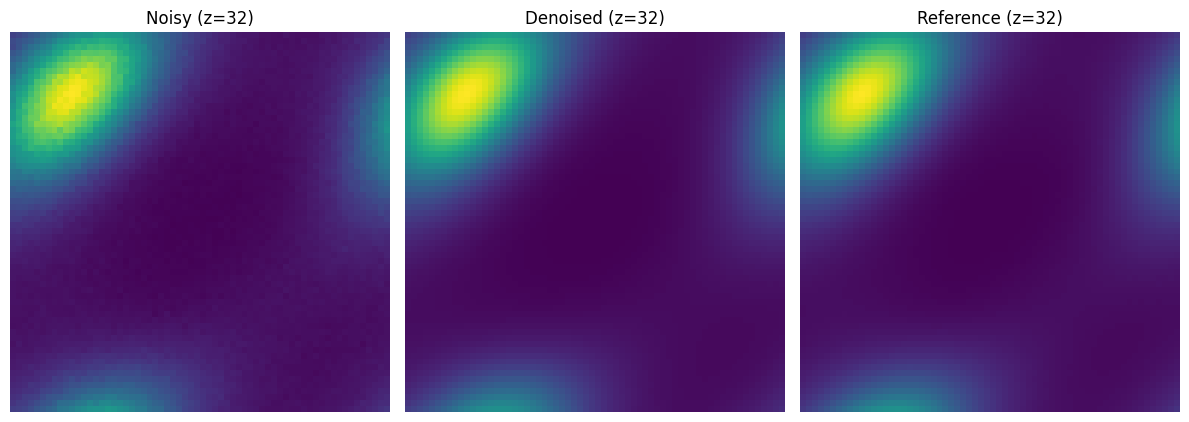


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0041287680_scunet_pre_denoised.npy
Sample 41287680 | scunet_pre JSD = 0.000208
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

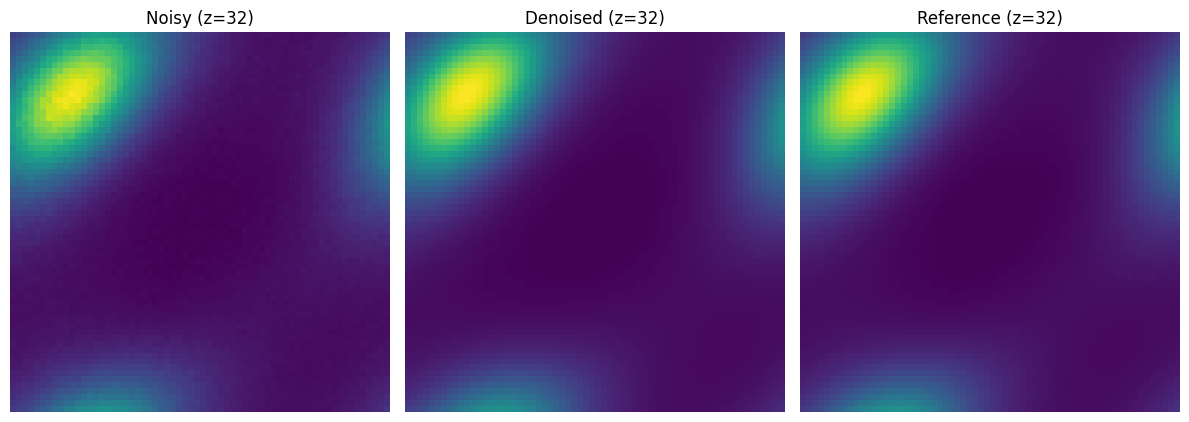


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0055050240_scunet_pre_denoised.npy
Sample 55050240 | scunet_pre JSD = 0.000158
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

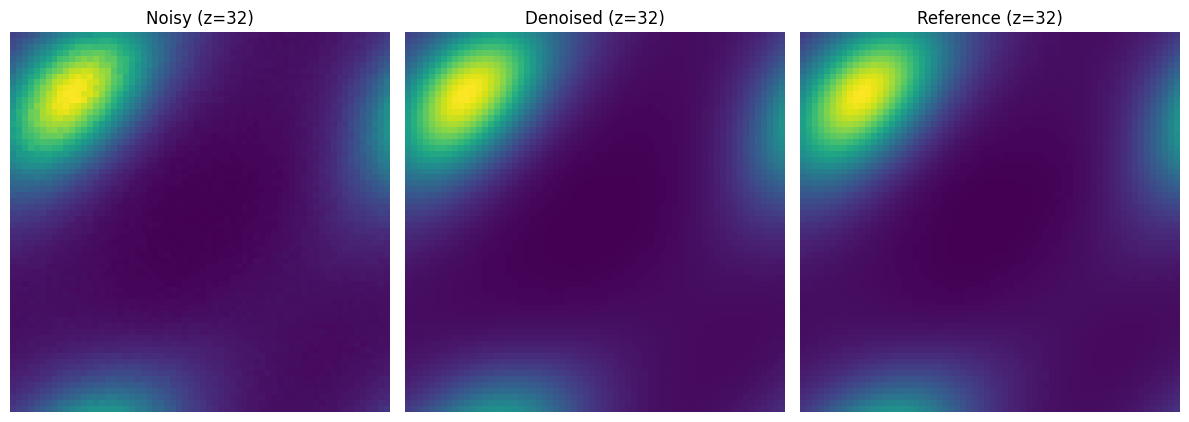


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0082575360_scunet_pre_denoised.npy
Sample 82575360 | scunet_pre JSD = 0.000121
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

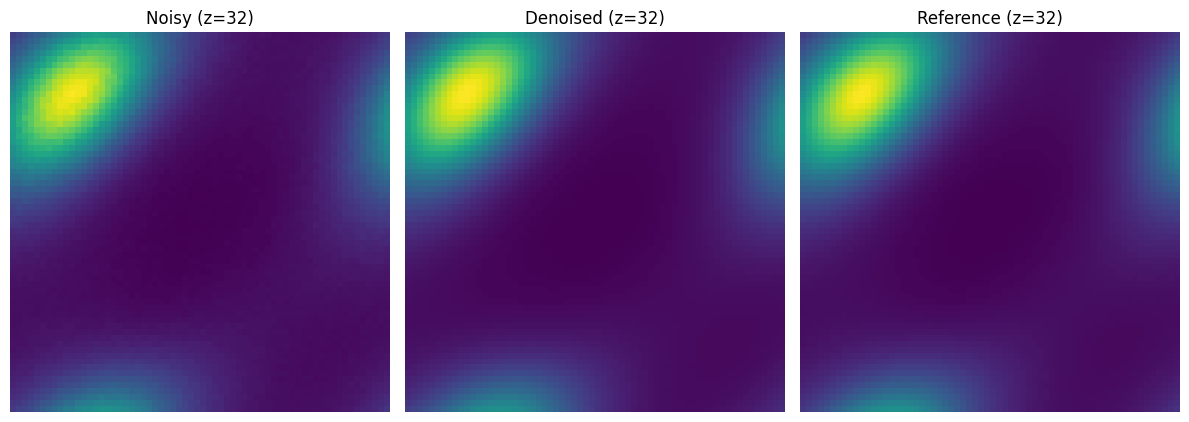


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0110100480_scunet_pre_denoised.npy
Sample 110100480 | scunet_pre JSD = 0.000094
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

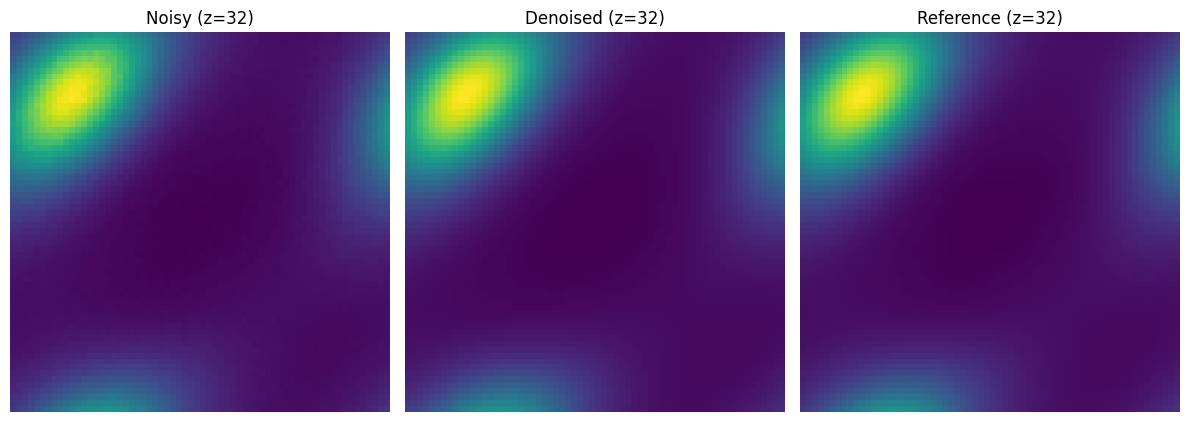


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0165150720_scunet_pre_denoised.npy
Sample 165150720 | scunet_pre JSD = 0.000073
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

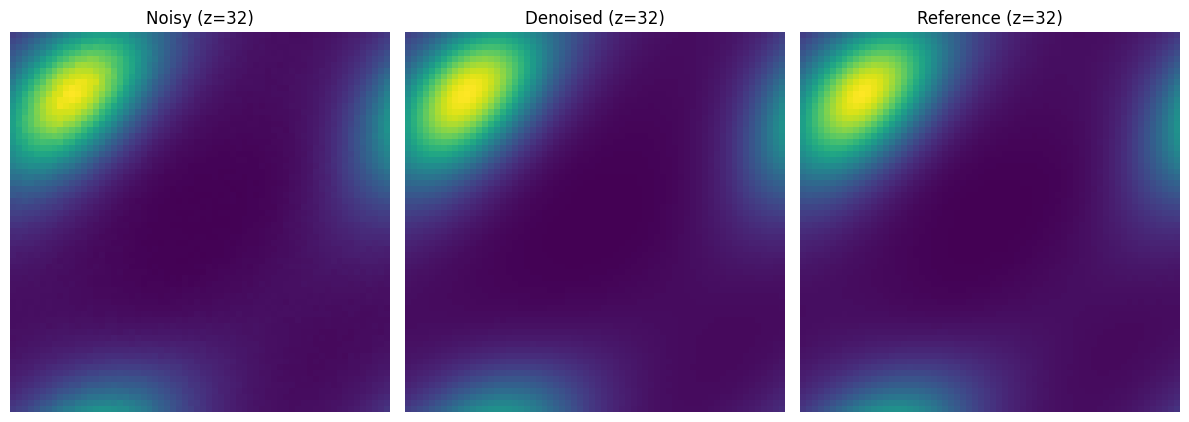


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0220200960_scunet_pre_denoised.npy
Sample 220200960 | scunet_pre JSD = 0.000065
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

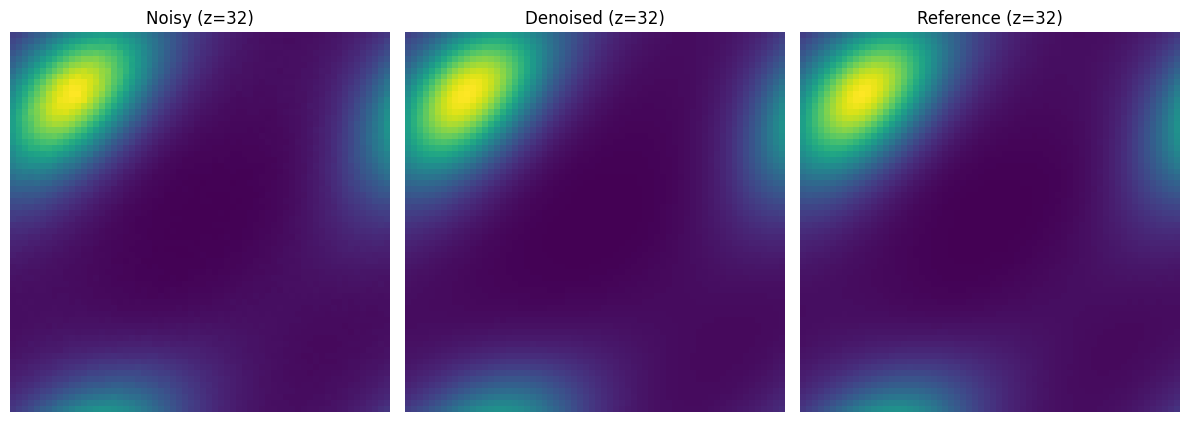


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0330301440_scunet_pre_denoised.npy
Sample 330301440 | scunet_pre JSD = 0.000053
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

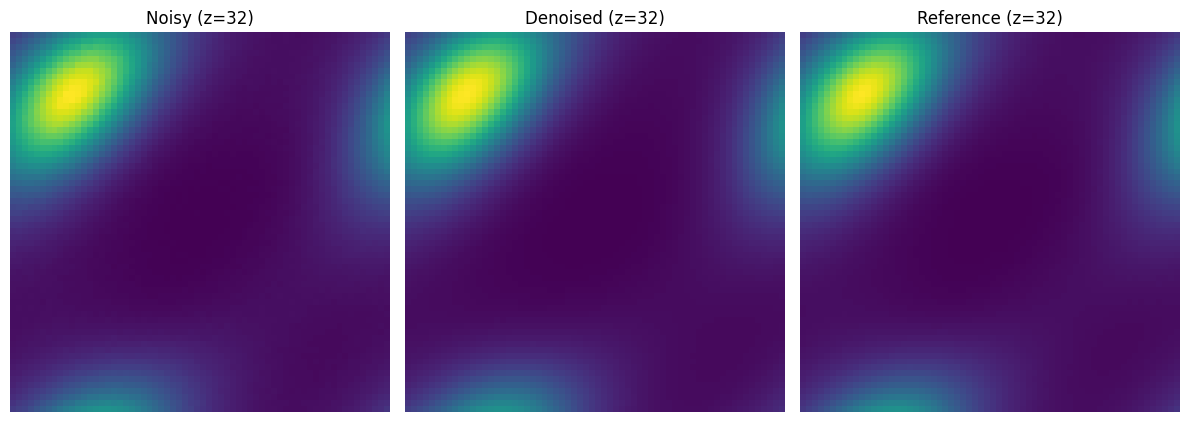


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0440401920_scunet_pre_denoised.npy
Sample 440401920 | scunet_pre JSD = 0.000048
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

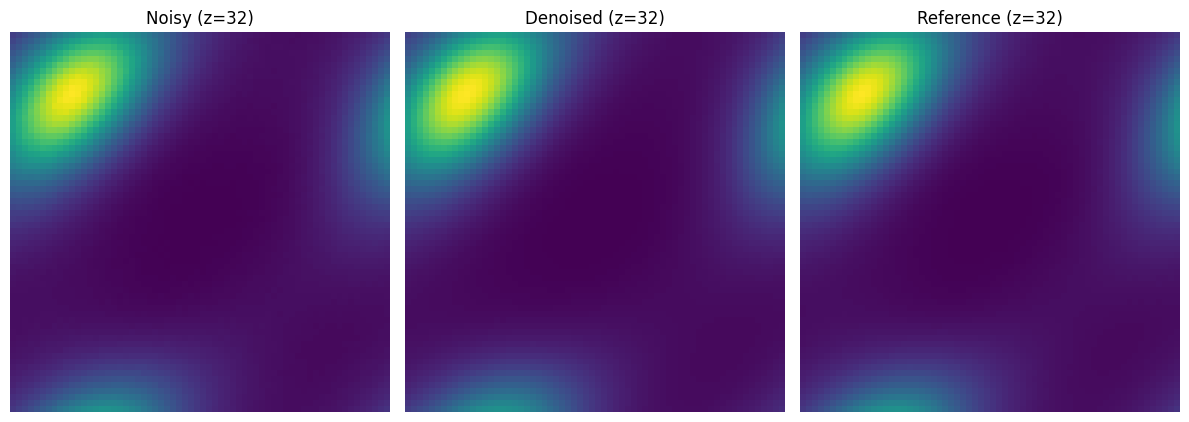


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0660602880_scunet_pre_denoised.npy
Sample 660602880 | scunet_pre JSD = 0.000043
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

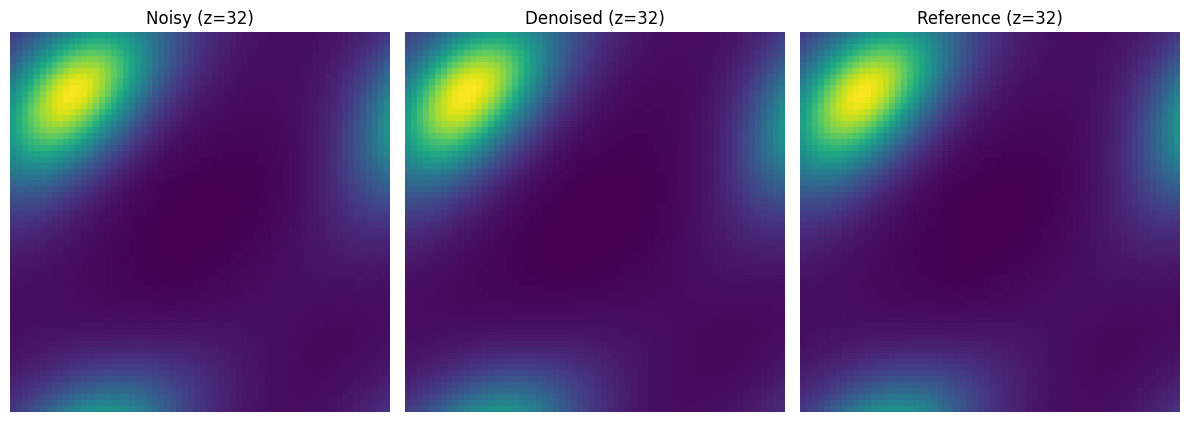


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_1321205760_scunet_pre_denoised.npy
Sample 1321205760 | scunet_pre JSD = 0.000039
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

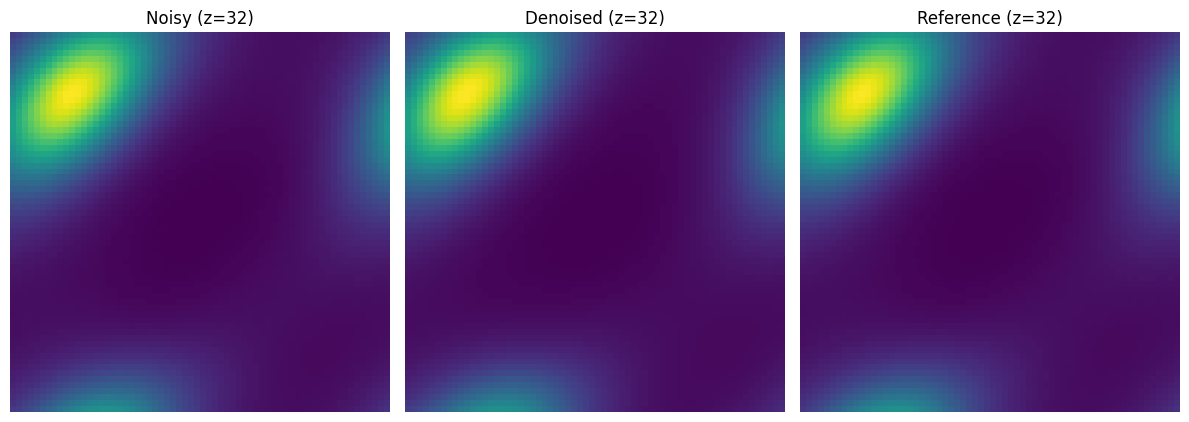


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_2642411520_scunet_pre_denoised.npy
Sample 2642411520 | scunet_pre JSD = 0.000038
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

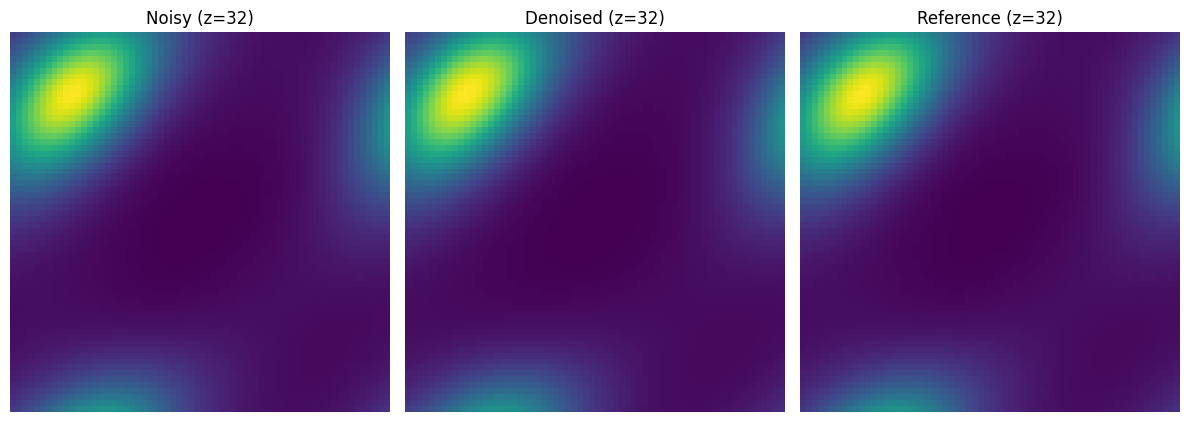


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_5284823040_scunet_pre_denoised.npy
Sample 5284823040 | scunet_pre JSD = 0.000037

=== Running model: scunet_ft ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0068
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.011002

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0068
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.011002


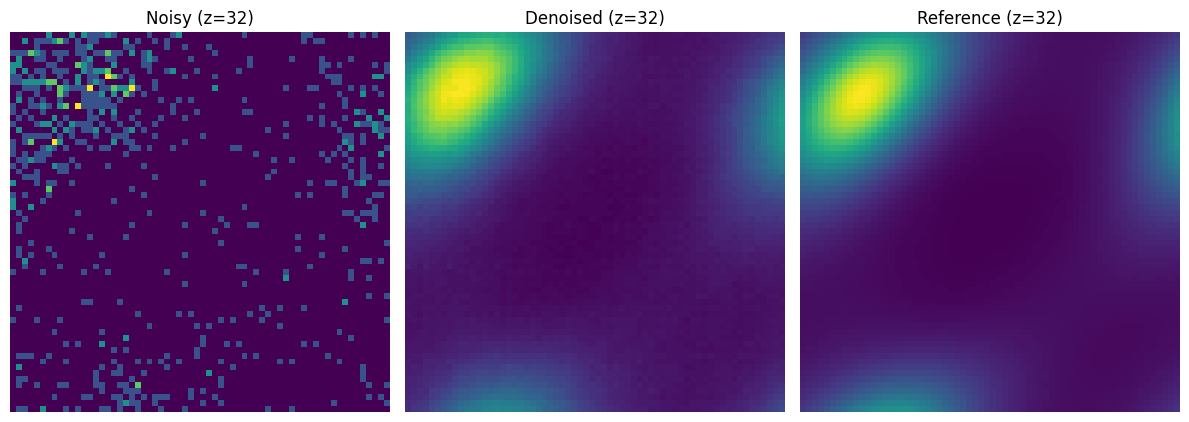


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000010240_scunet_ft_denoised.npy
Sample 10240 | scunet_ft JSD = 0.011002

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0033
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.003168

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0033
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.003168


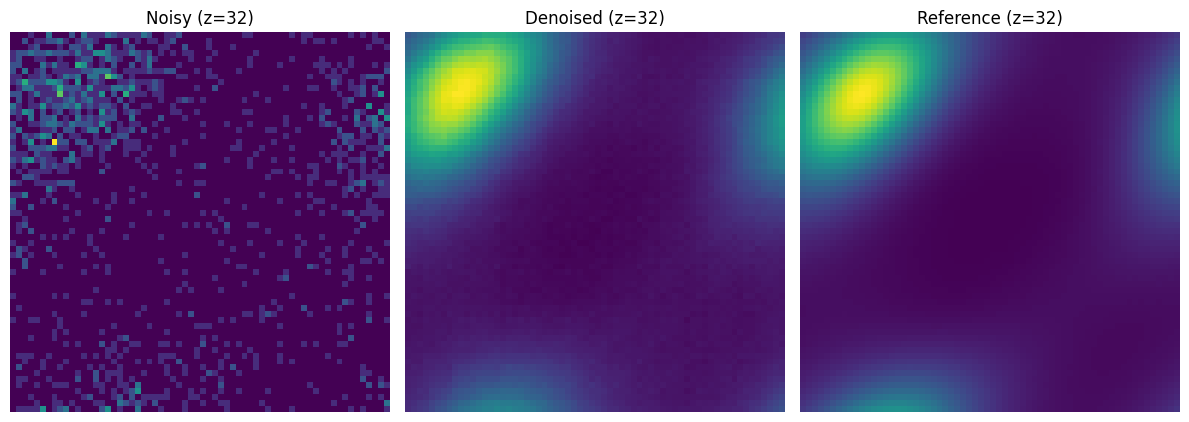


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000020480_scunet_ft_denoised.npy
Sample 20480 | scunet_ft JSD = 0.003168

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.001127

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.001127


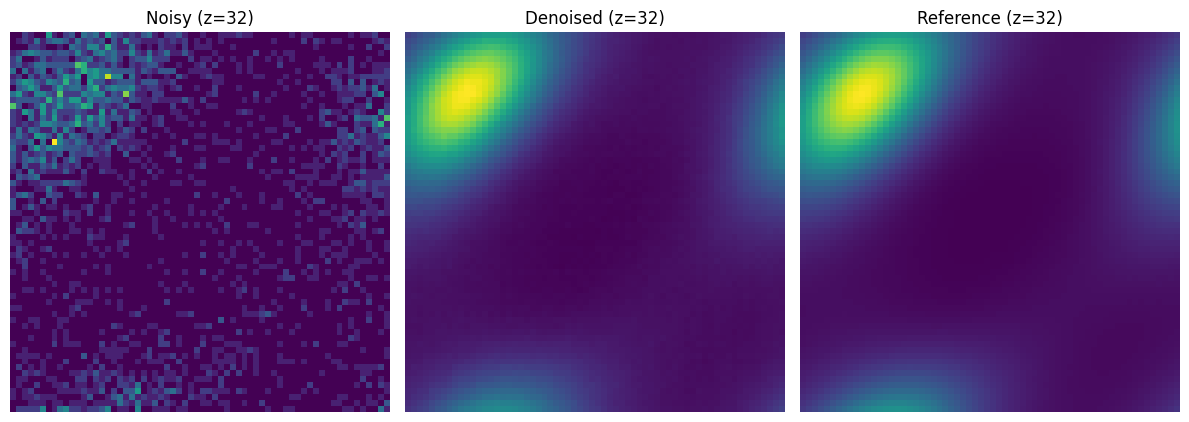


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000040960_scunet_ft_denoised.npy
Sample 40960 | scunet_ft JSD = 0.001127

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.000455

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.000455


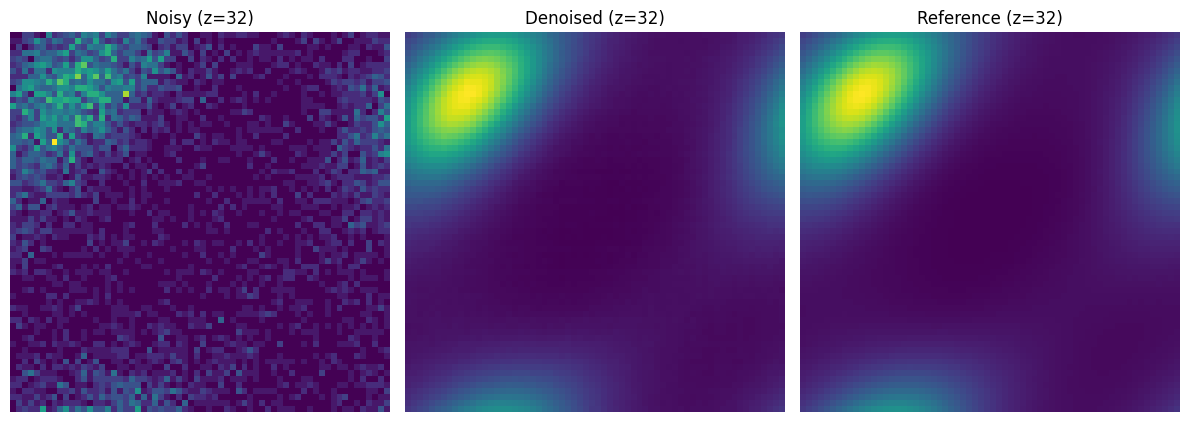


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000081920_scunet_ft_denoised.npy
Sample 81920 | scunet_ft JSD = 0.000455

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000342

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000342


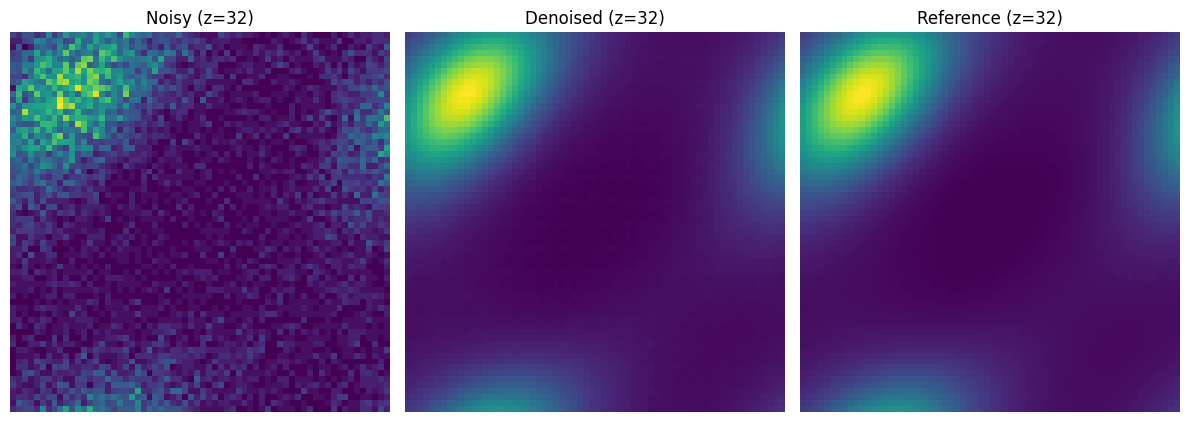


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000163840_scunet_ft_denoised.npy
Sample 163840 | scunet_ft JSD = 0.000342

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000322

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000322


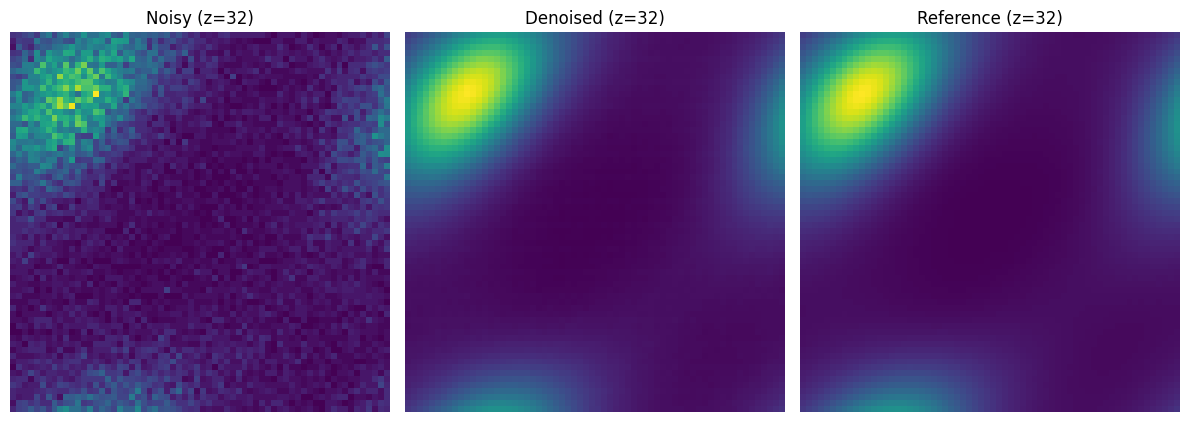


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000327680_scunet_ft_denoised.npy
Sample 327680 | scunet_ft JSD = 0.000322

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000323

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000323


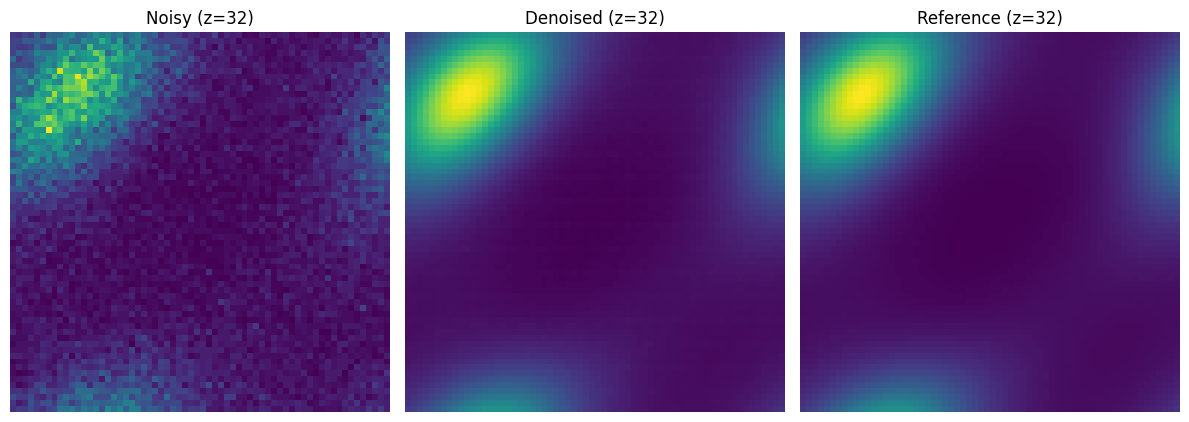


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000430080_scunet_ft_denoised.npy
Sample 430080 | scunet_ft JSD = 0.000323

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000344

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000344


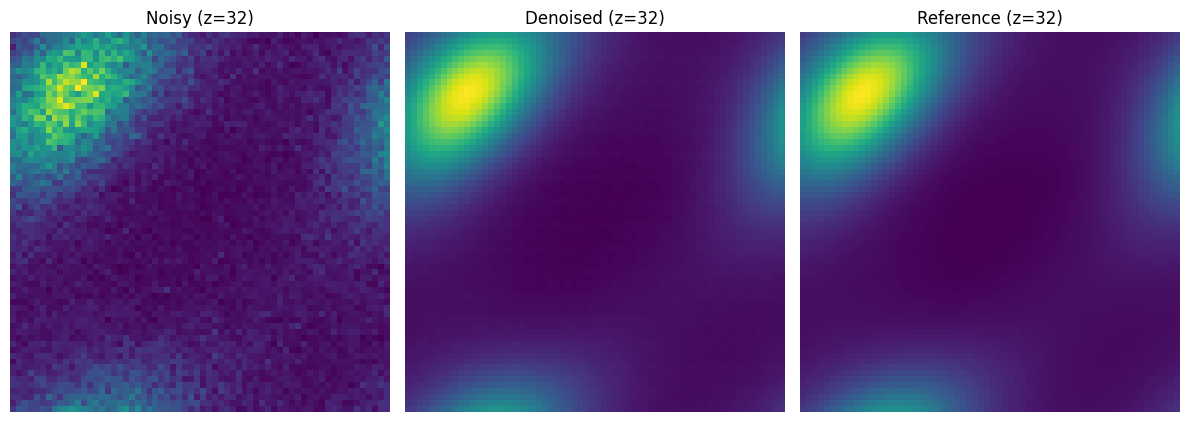


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360_scunet_ft_denoised.npy
Sample 655360 | scunet_ft JSD = 0.000344

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000342

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000342


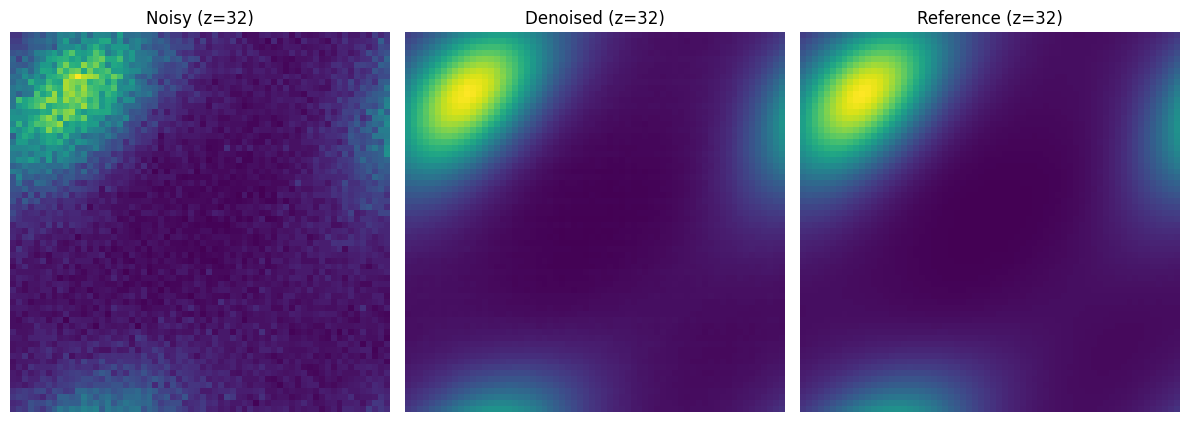


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000860160_scunet_ft_denoised.npy
Sample 860160 | scunet_ft JSD = 0.000342

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000357

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000357


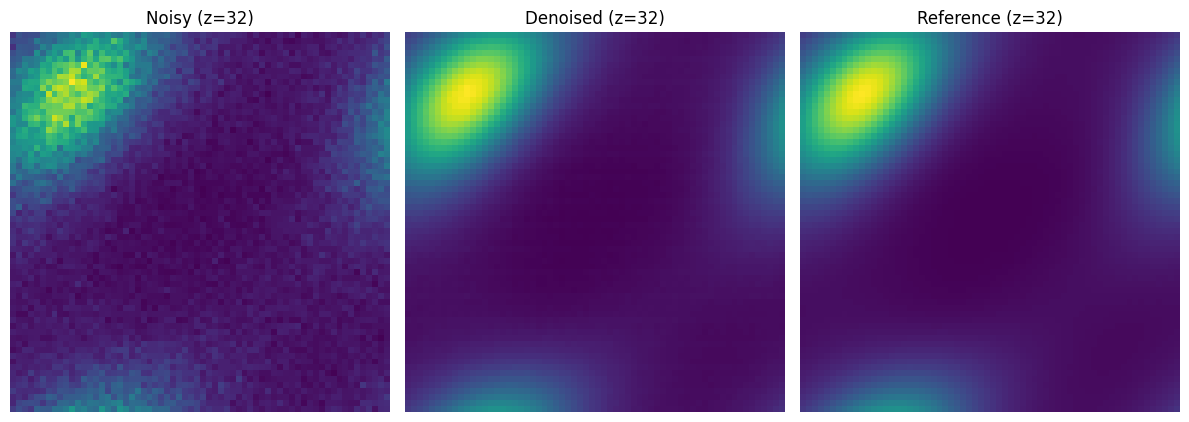


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001310720_scunet_ft_denoised.npy
Sample 1310720 | scunet_ft JSD = 0.000357

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000307

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000307


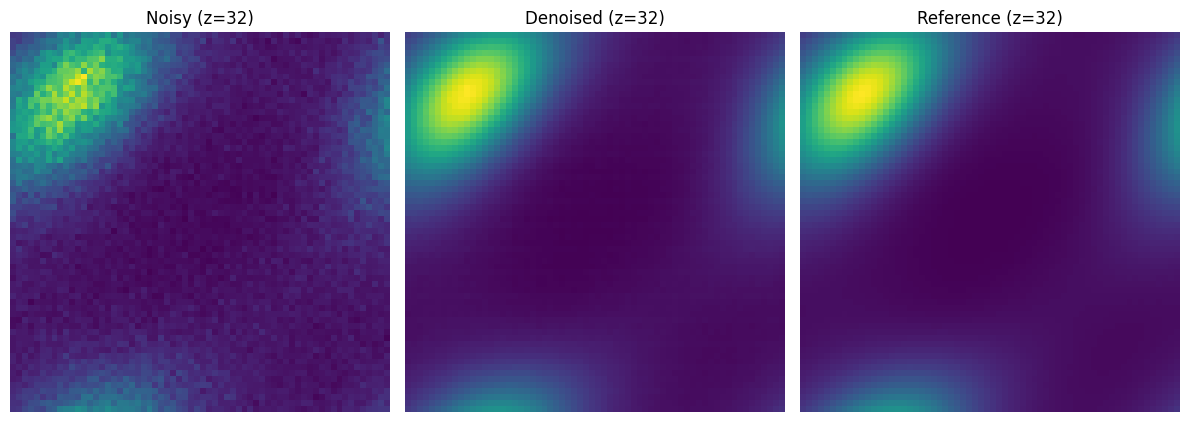


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001720320_scunet_ft_denoised.npy
Sample 1720320 | scunet_ft JSD = 0.000307

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000253

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000253


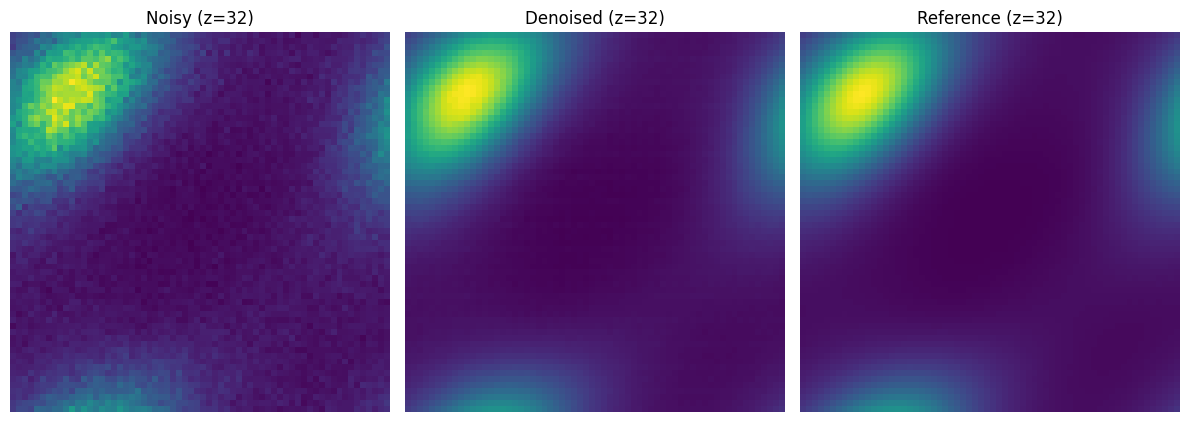


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0002621440_scunet_ft_denoised.npy
Sample 2621440 | scunet_ft JSD = 0.000253

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000241

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000241


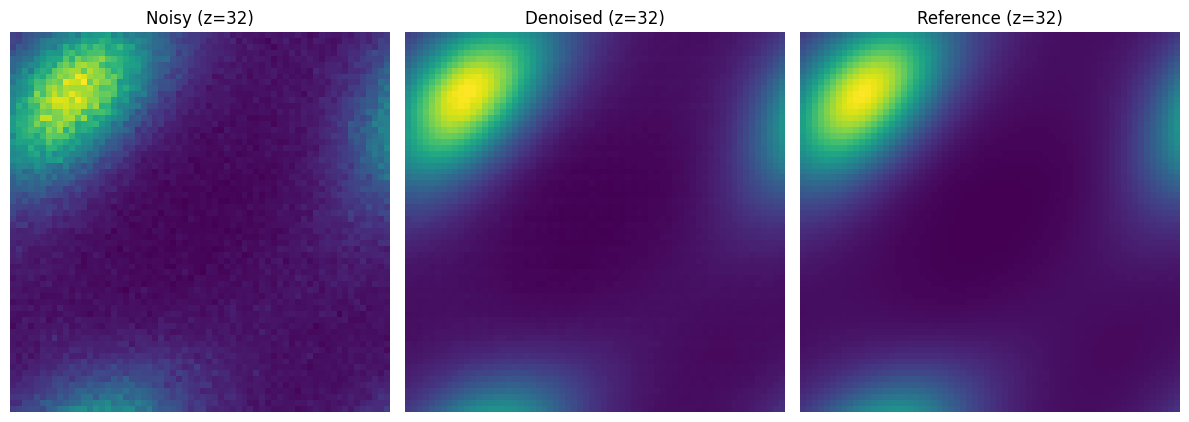


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0003440640_scunet_ft_denoised.npy
Sample 3440640 | scunet_ft JSD = 0.000241

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000207

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000207


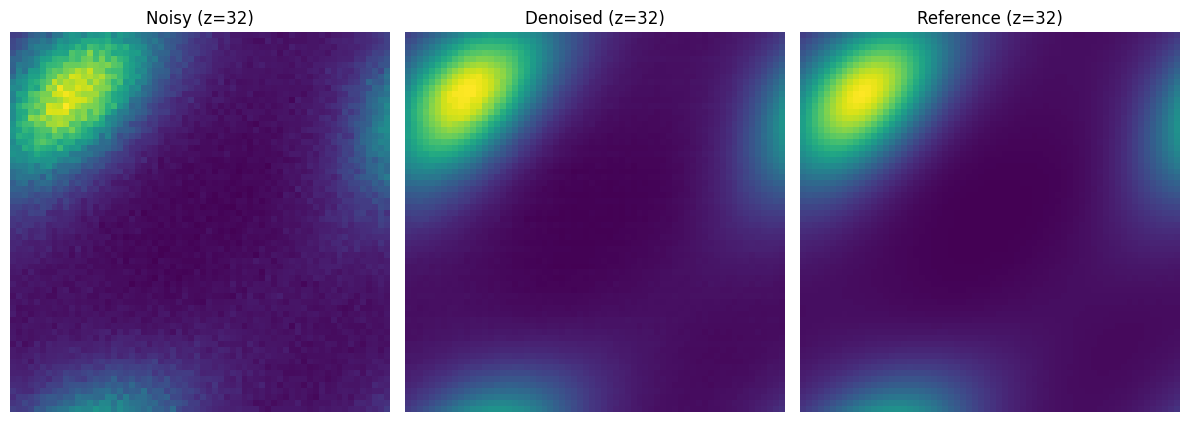


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005160960_scunet_ft_denoised.npy
Sample 5160960 | scunet_ft JSD = 0.000207

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000205

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000205


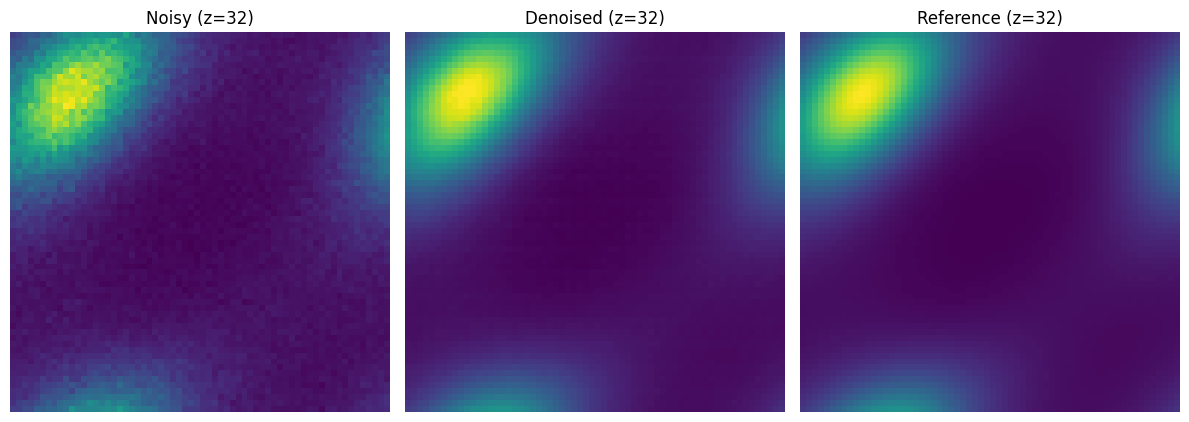


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005242880_scunet_ft_denoised.npy
Sample 5242880 | scunet_ft JSD = 0.000205

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000191

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000191


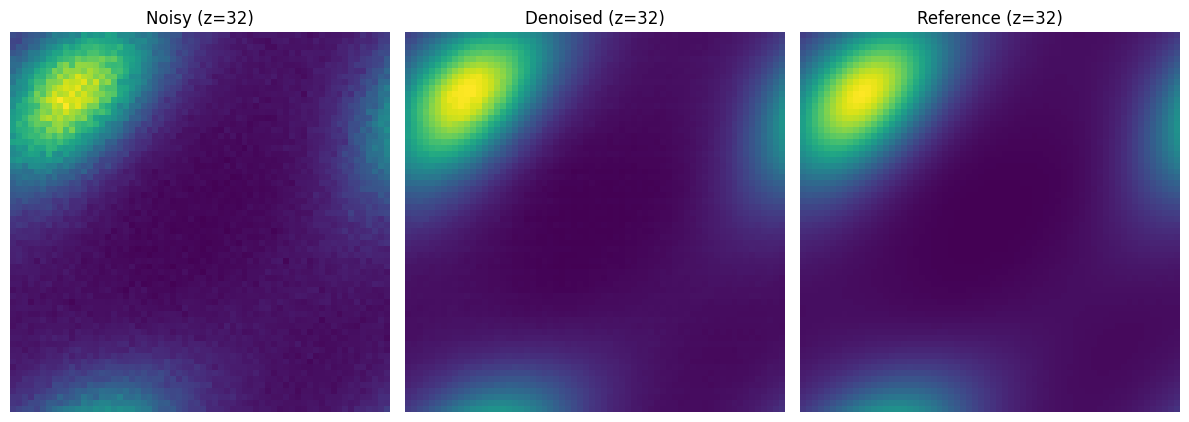


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0006881280_scunet_ft_denoised.npy
Sample 6881280 | scunet_ft JSD = 0.000191

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000212

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000212


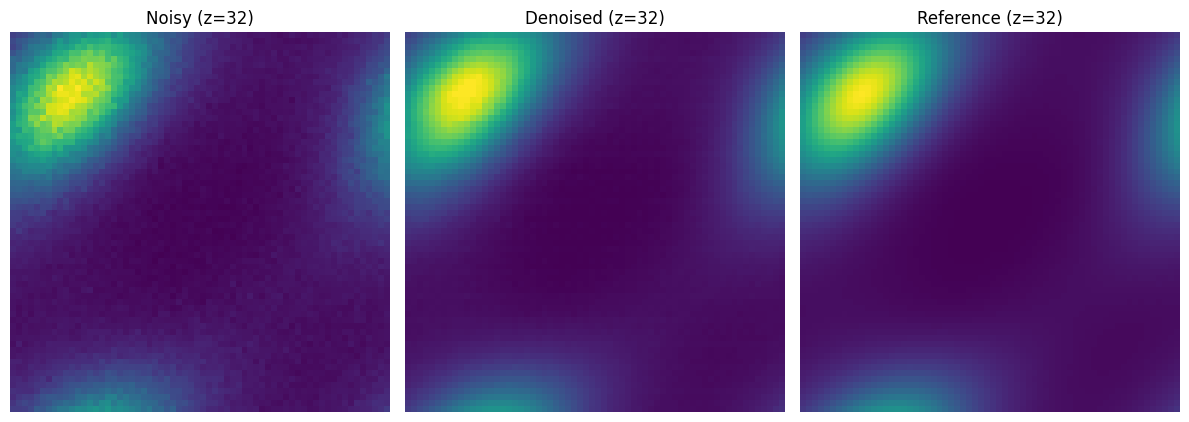


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010321920_scunet_ft_denoised.npy
Sample 10321920 | scunet_ft JSD = 0.000212

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000209

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000209


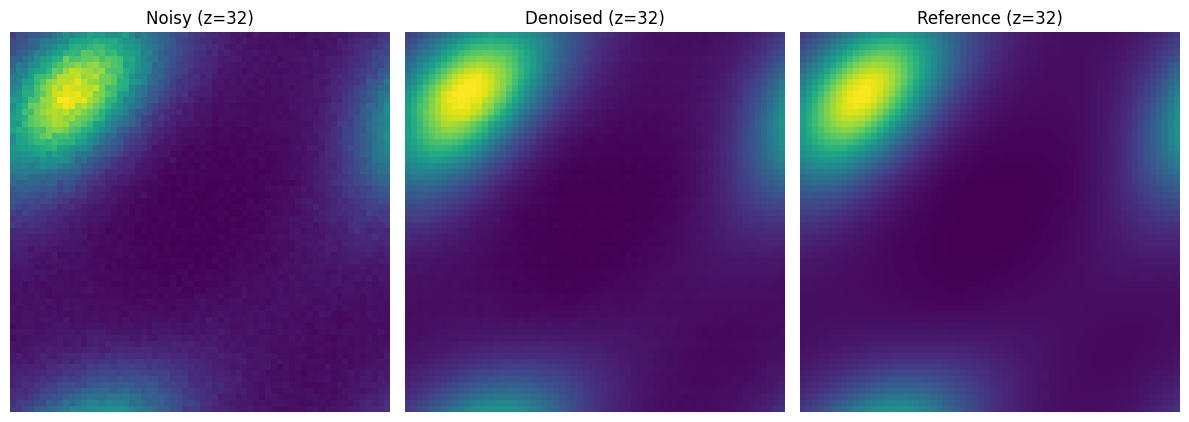


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010485760_scunet_ft_denoised.npy
Sample 10485760 | scunet_ft JSD = 0.000209

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000207

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000207


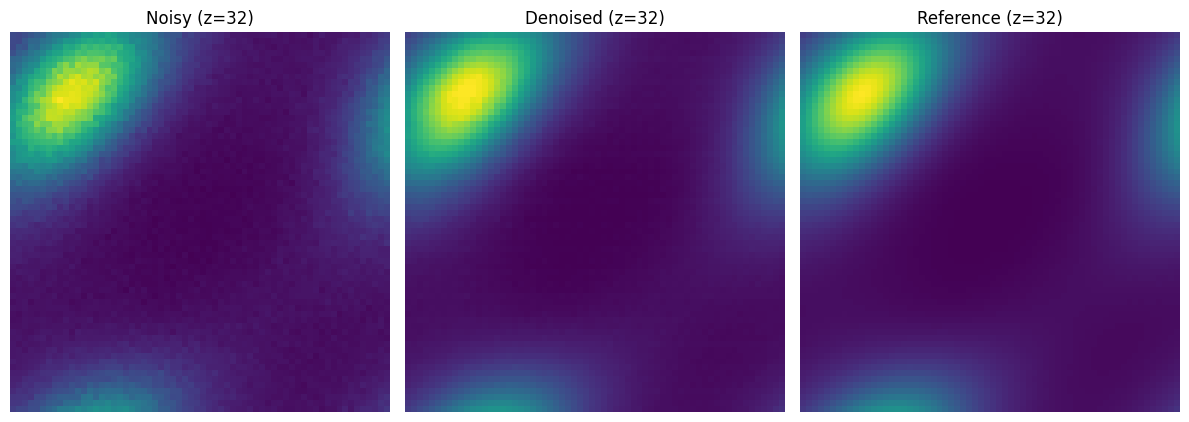


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0013762560_scunet_ft_denoised.npy
Sample 13762560 | scunet_ft JSD = 0.000207

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000235

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000235


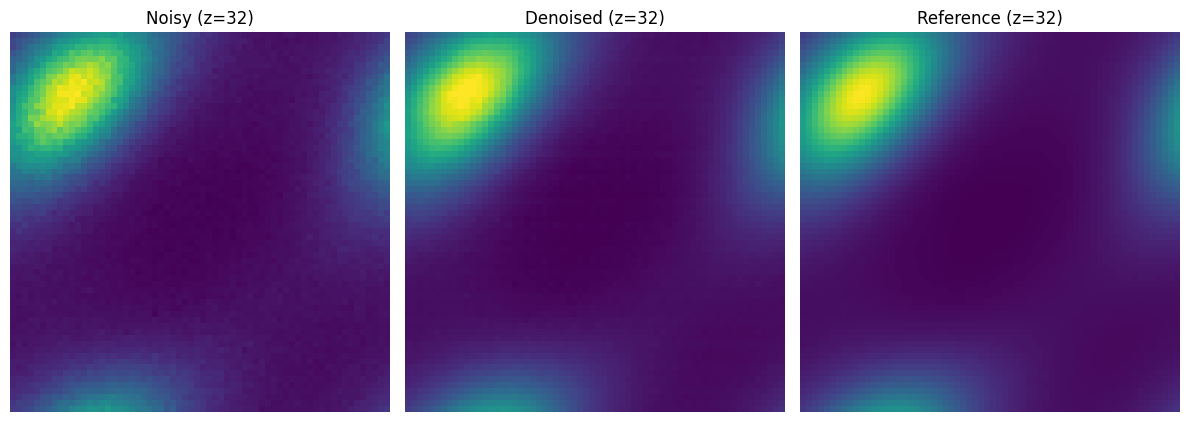


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0020643840_scunet_ft_denoised.npy
Sample 20643840 | scunet_ft JSD = 0.000235

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000240

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000240


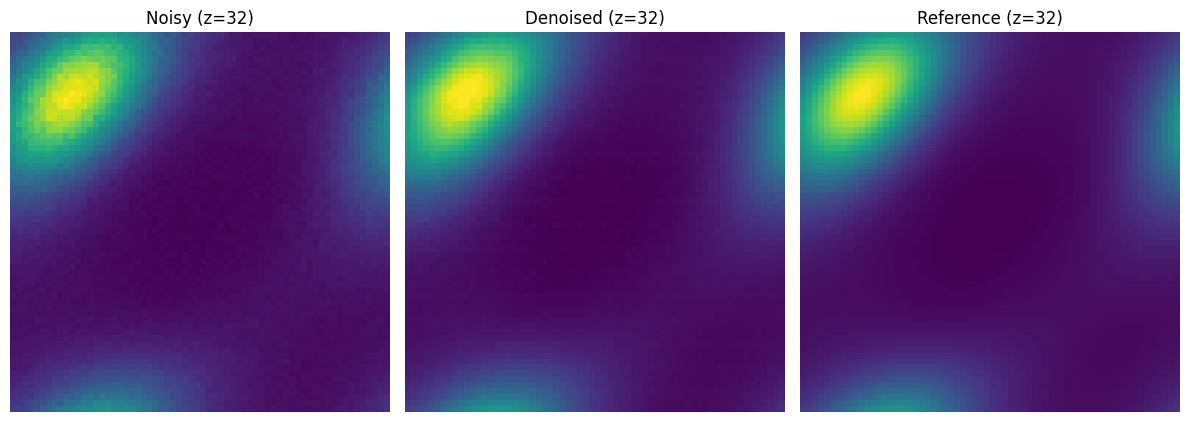


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0027525120_scunet_ft_denoised.npy
Sample 27525120 | scunet_ft JSD = 0.000240

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000261

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000261


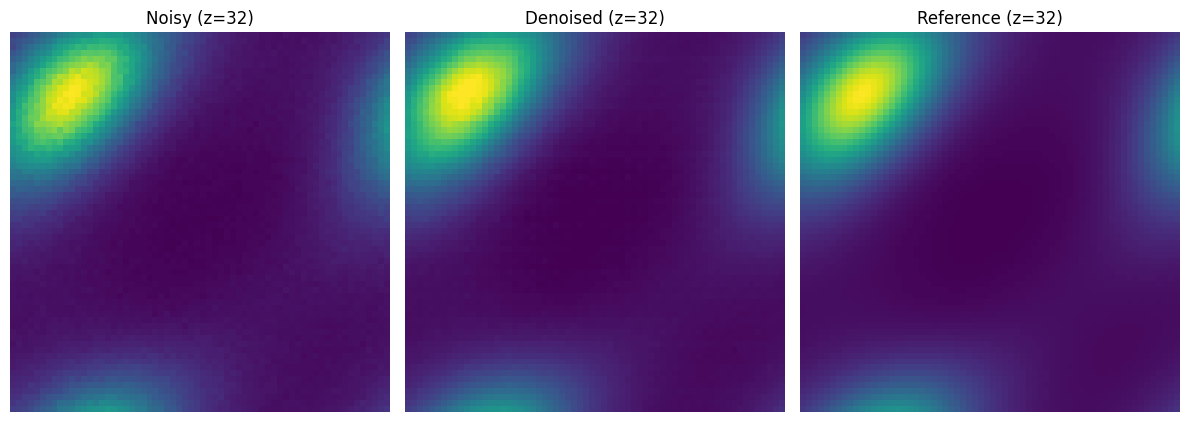


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0041287680_scunet_ft_denoised.npy
Sample 41287680 | scunet_ft JSD = 0.000261

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000273

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000273


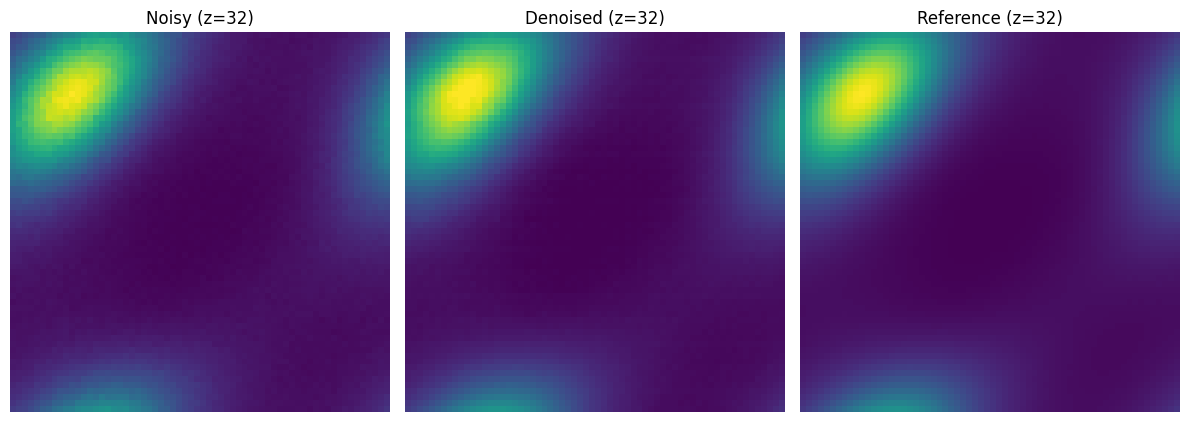


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0055050240_scunet_ft_denoised.npy
Sample 55050240 | scunet_ft JSD = 0.000273

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000287

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000287


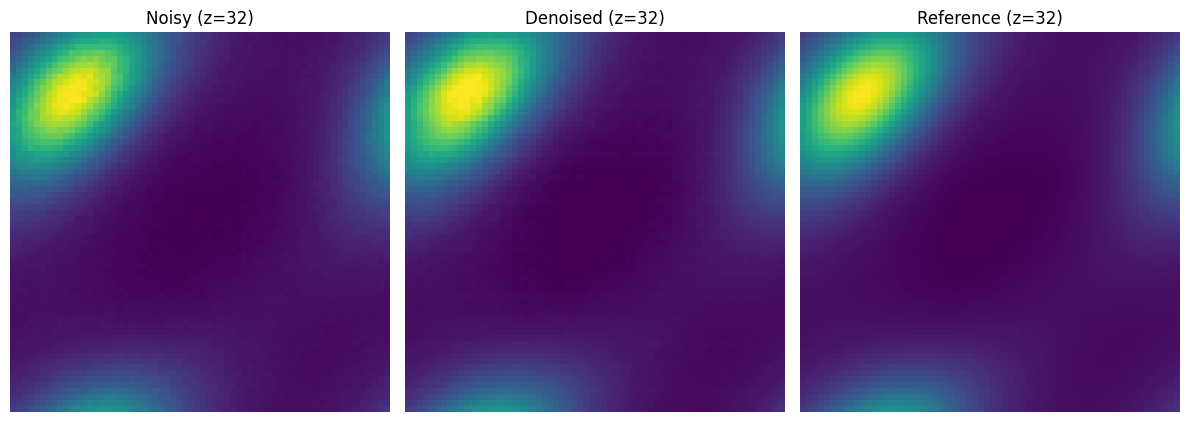


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0082575360_scunet_ft_denoised.npy
Sample 82575360 | scunet_ft JSD = 0.000287

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000298

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000298


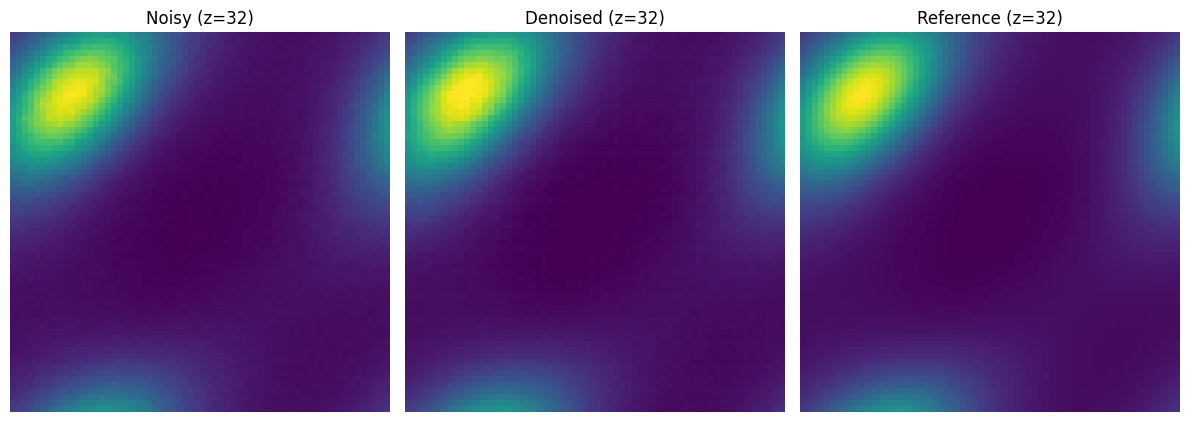


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0110100480_scunet_ft_denoised.npy
Sample 110100480 | scunet_ft JSD = 0.000298

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000308

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000308


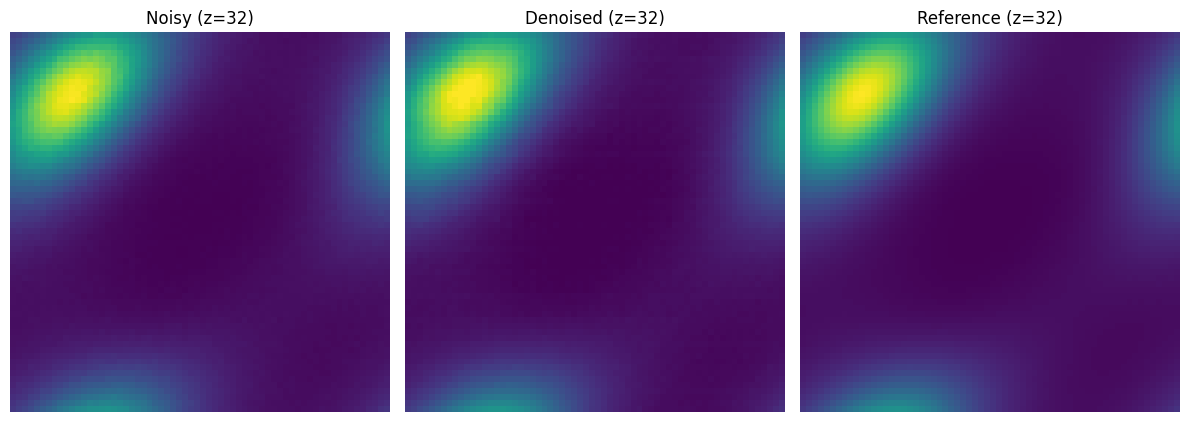


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0165150720_scunet_ft_denoised.npy
Sample 165150720 | scunet_ft JSD = 0.000308

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000314

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000314


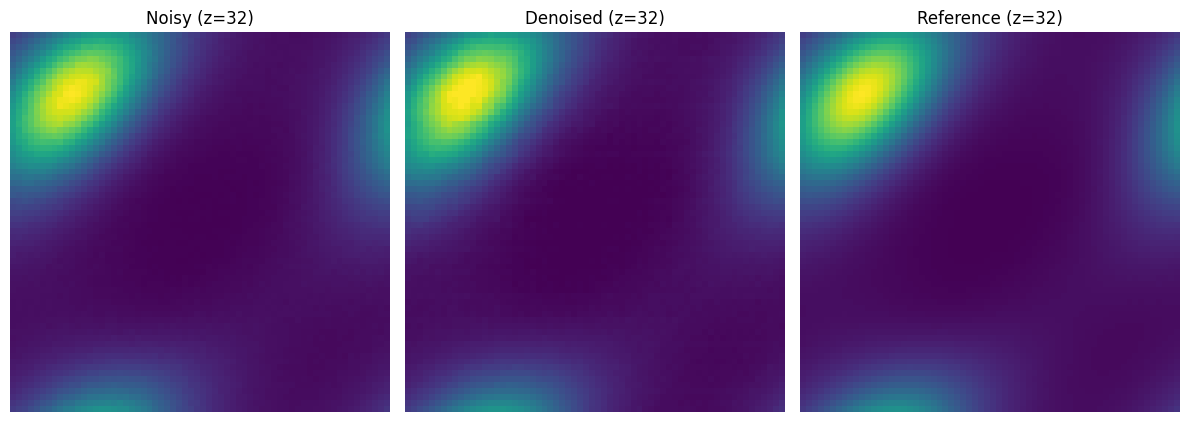


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0220200960_scunet_ft_denoised.npy
Sample 220200960 | scunet_ft JSD = 0.000314

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000323

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000323


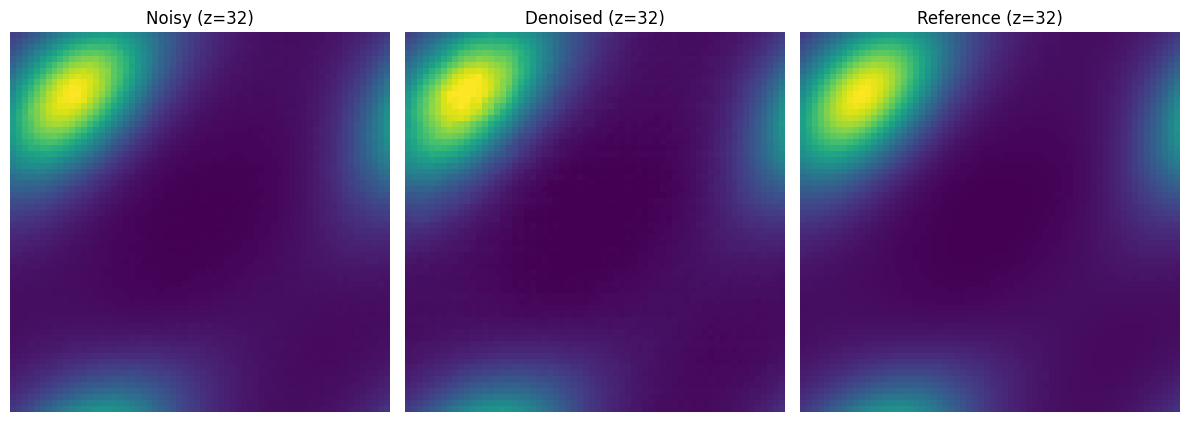


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0330301440_scunet_ft_denoised.npy
Sample 330301440 | scunet_ft JSD = 0.000323

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.000328

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.000328


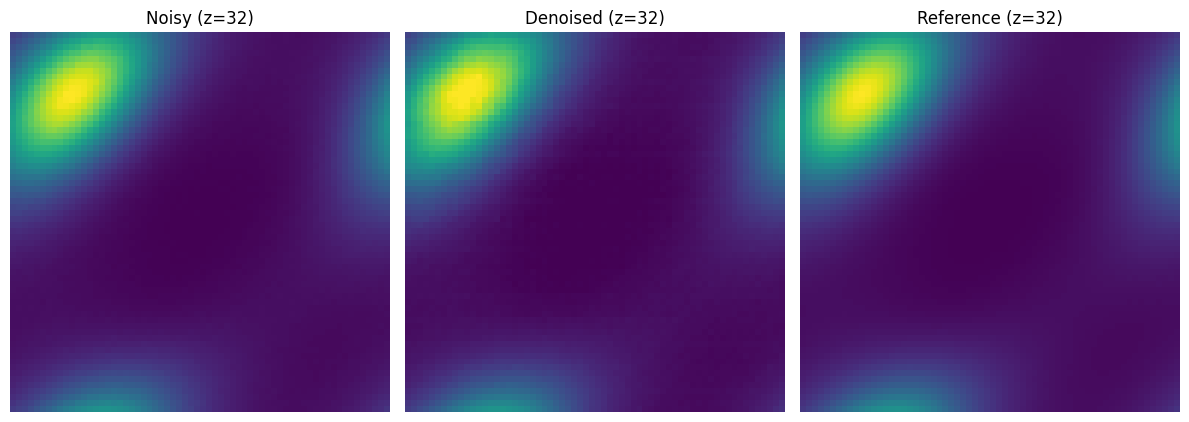


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0440401920_scunet_ft_denoised.npy
Sample 440401920 | scunet_ft JSD = 0.000328

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.000336

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.000336


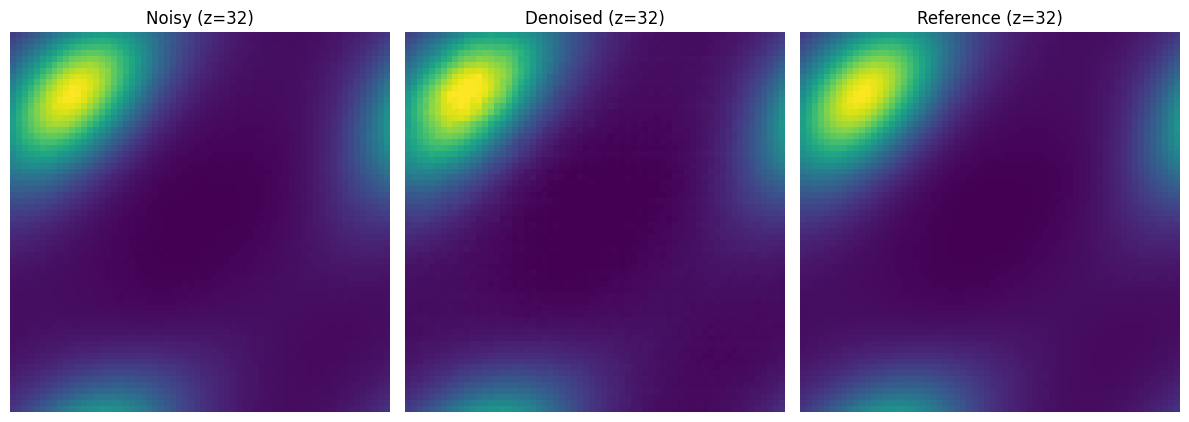


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0660602880_scunet_ft_denoised.npy
Sample 660602880 | scunet_ft JSD = 0.000336

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000343

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000343


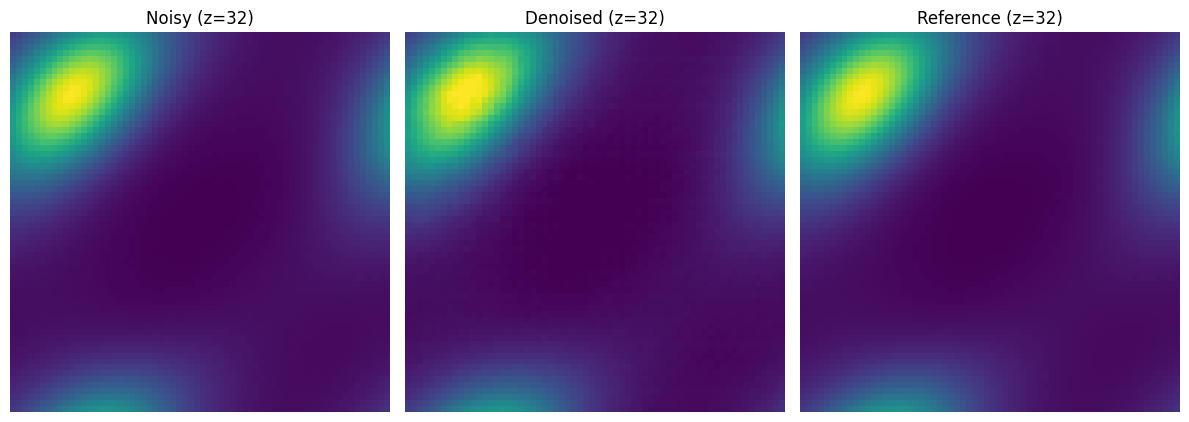


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_1321205760_scunet_ft_denoised.npy
Sample 1321205760 | scunet_ft JSD = 0.000343

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000350

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000350


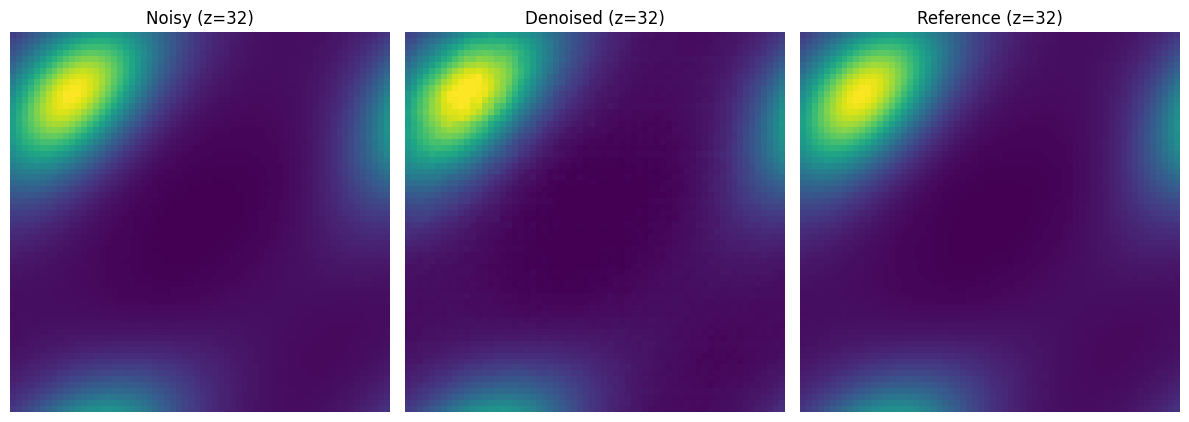


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_2642411520_scunet_ft_denoised.npy
Sample 2642411520 | scunet_ft JSD = 0.000350

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000354

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000354


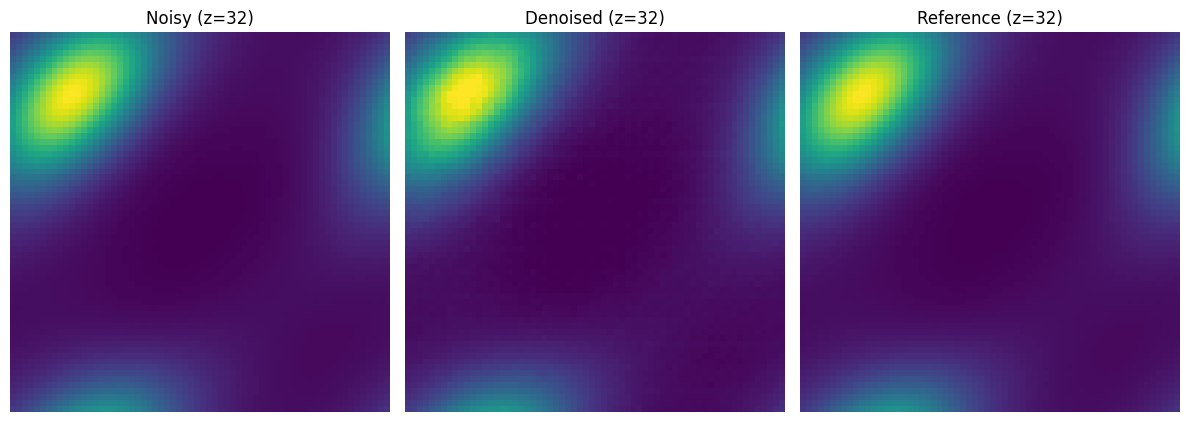


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_5284823040_scunet_ft_denoised.npy
Sample 5284823040 | scunet_ft JSD = 0.000354

=== Running model: nature ===


I0000 00:00:1770764109.097608  620404 service.cc:152] XLA service 0x7f0e58006fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770764109.097638  620404 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1770764109.097644  620404 service.cc:160]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1770764109.097647  620404 service.cc:160]   StreamExecutor device (2): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1770764109.097648  620404 service.cc:160]   StreamExecutor device (3): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-10 14:55:09.114395: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770764109.177322  620404 cuda_dnn.cc:529] Loaded cuDNN version 90300


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


I0000 00:00:1770764110.008719  620404 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0113
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.022480

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0113
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.022480


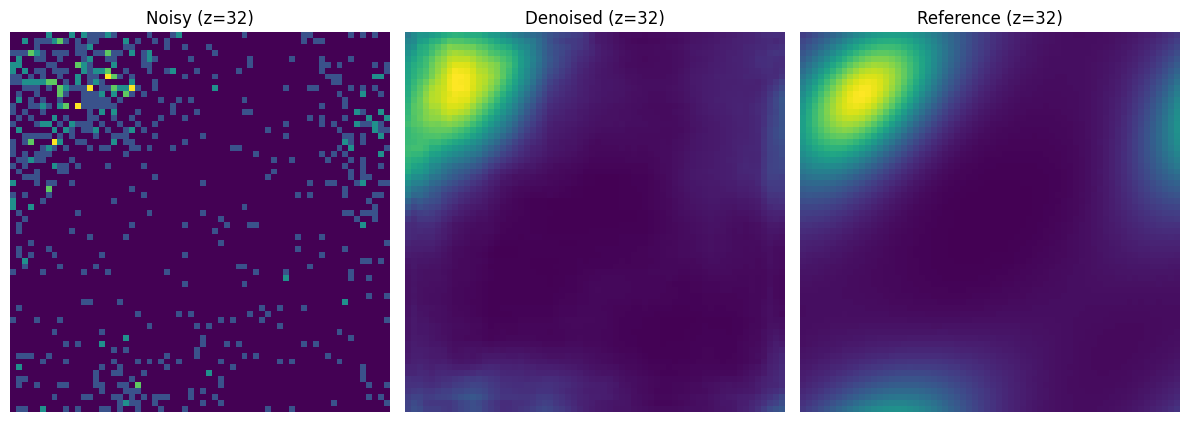


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000010240_nature_denoised.npy
Sample 10240 | nature JSD = 0.022480
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0061
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.008951

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0061
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.008951


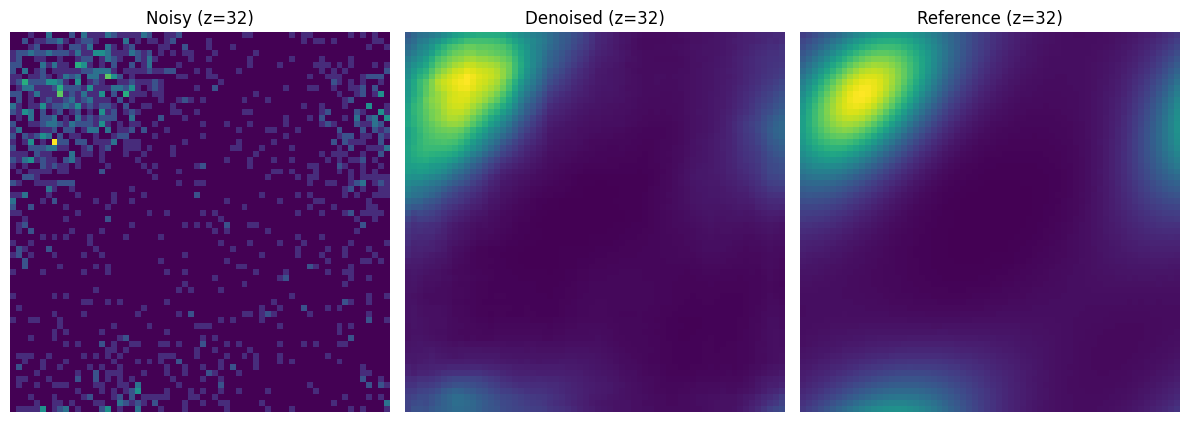


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000020480_nature_denoised.npy
Sample 20480 | nature JSD = 0.008951
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0031
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.003313

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0031
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.003313


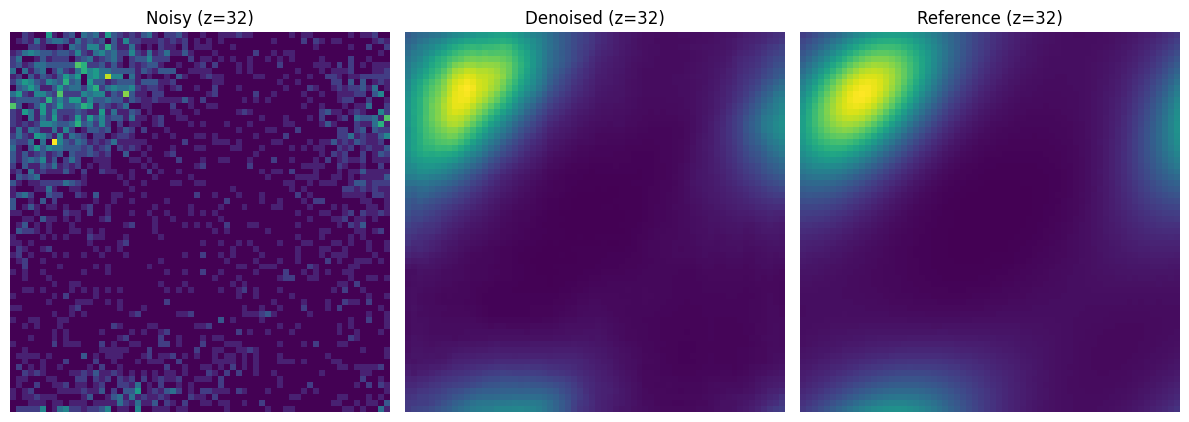


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000040960_nature_denoised.npy
Sample 40960 | nature JSD = 0.003313
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.001221

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.001221


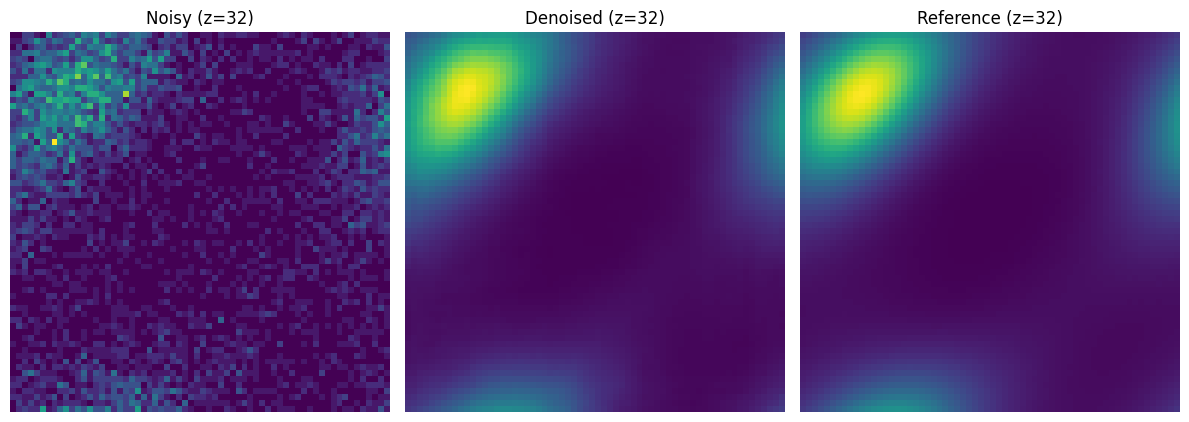


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000081920_nature_denoised.npy
Sample 81920 | nature JSD = 0.001221
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000812

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000812


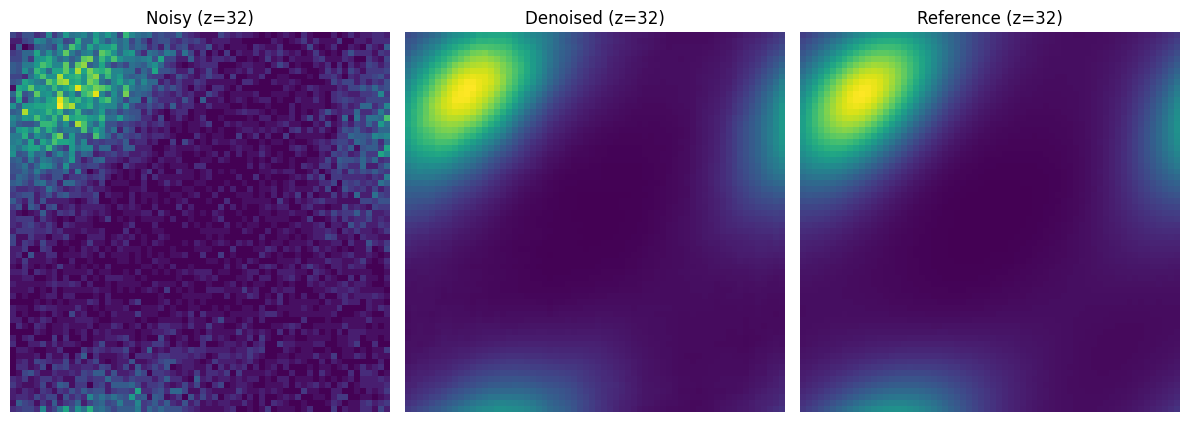


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000163840_nature_denoised.npy
Sample 163840 | nature JSD = 0.000812
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000604

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000604


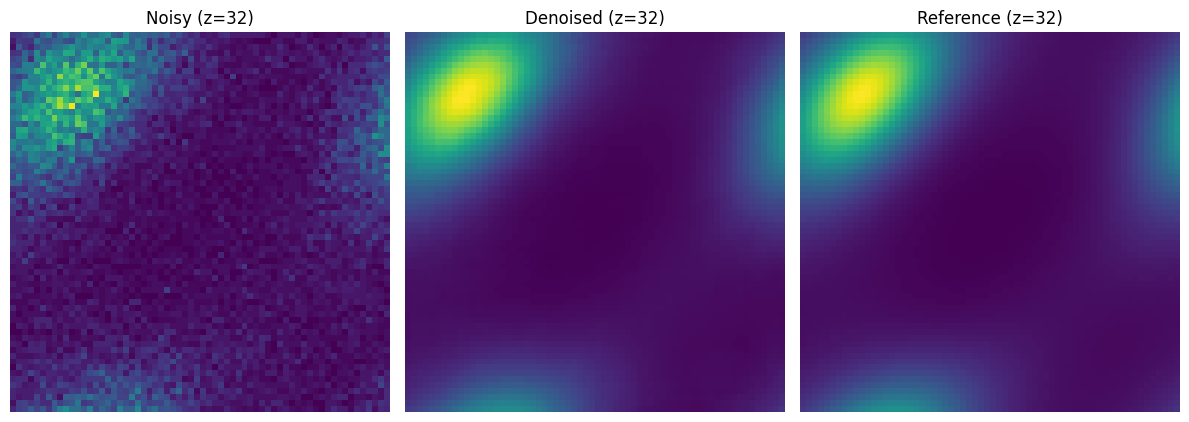


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000327680_nature_denoised.npy
Sample 327680 | nature JSD = 0.000604
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000585

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000585


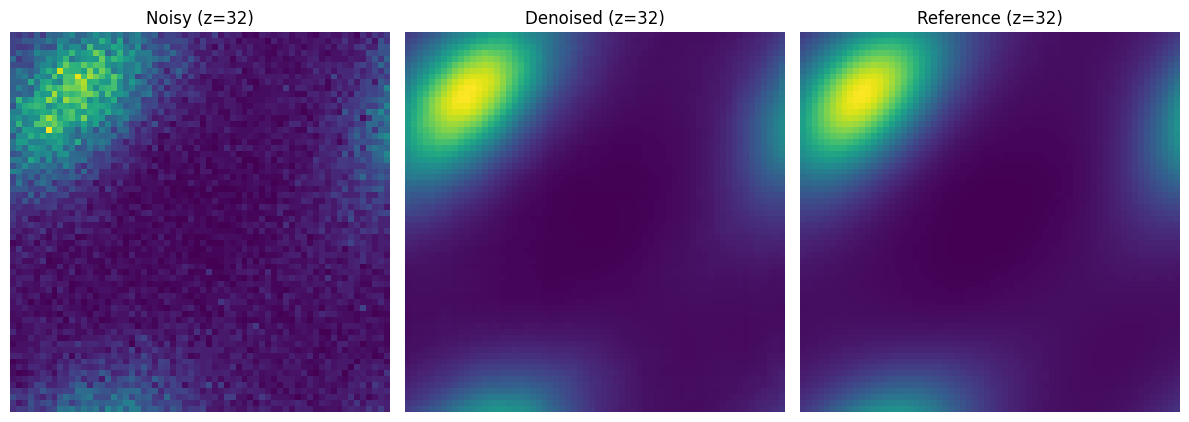


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000430080_nature_denoised.npy
Sample 430080 | nature JSD = 0.000585
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000568

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000568


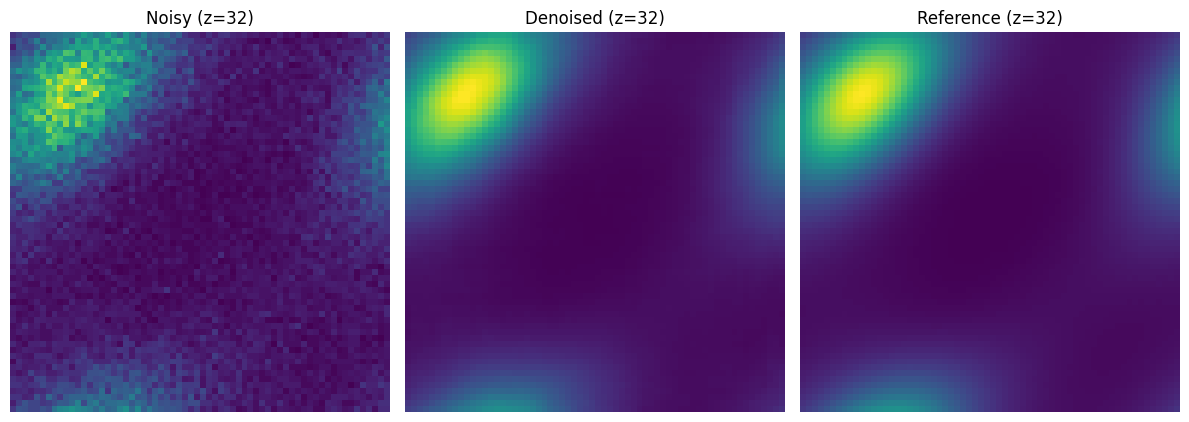


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360_nature_denoised.npy
Sample 655360 | nature JSD = 0.000568
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000567

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000567


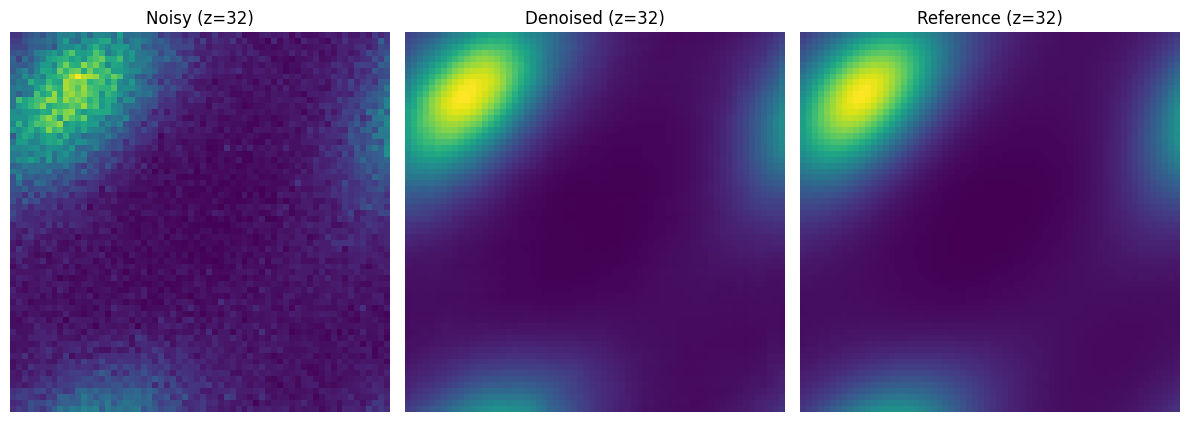


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000860160_nature_denoised.npy
Sample 860160 | nature JSD = 0.000567
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000596

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000596


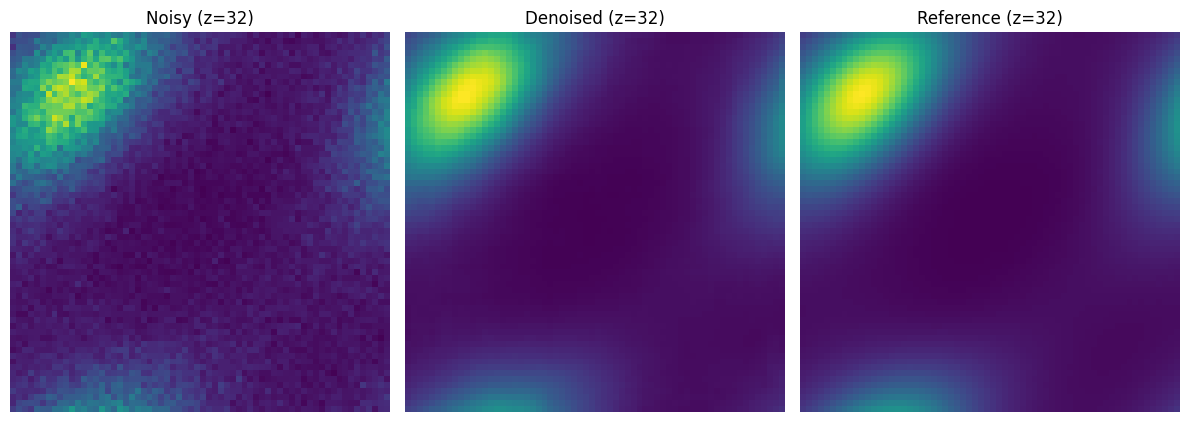


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001310720_nature_denoised.npy
Sample 1310720 | nature JSD = 0.000596
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000544

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000544


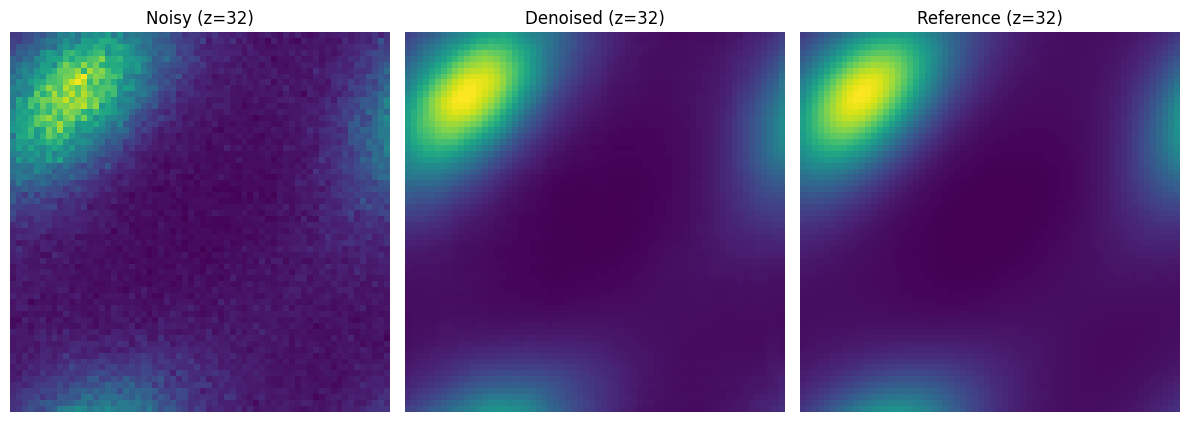


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001720320_nature_denoised.npy
Sample 1720320 | nature JSD = 0.000544
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000537

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000537


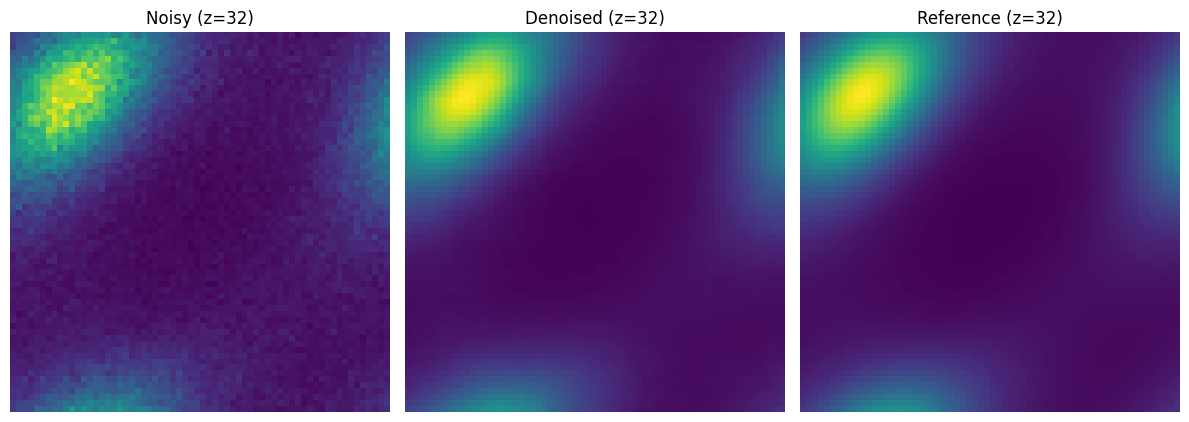


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0002621440_nature_denoised.npy
Sample 2621440 | nature JSD = 0.000537
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000539

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000539


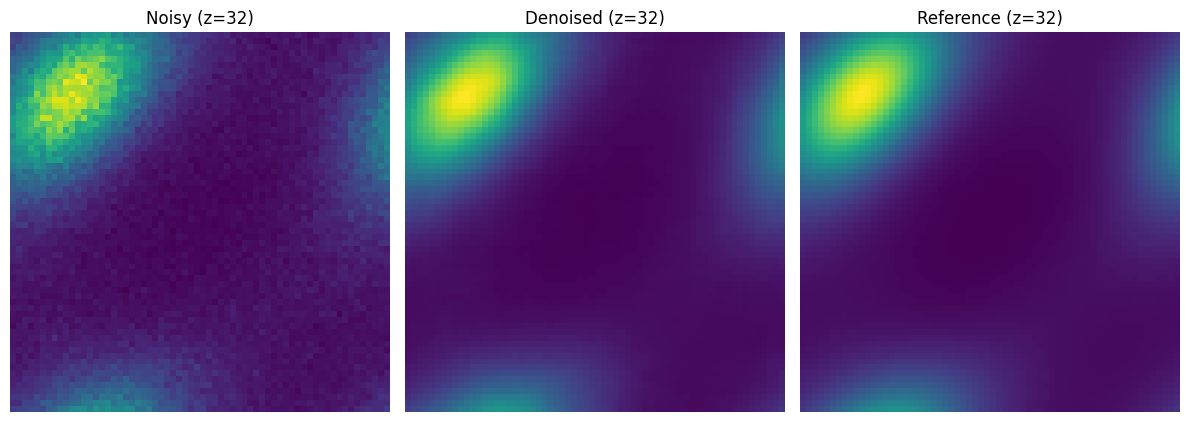


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0003440640_nature_denoised.npy
Sample 3440640 | nature JSD = 0.000539
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000553

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000553


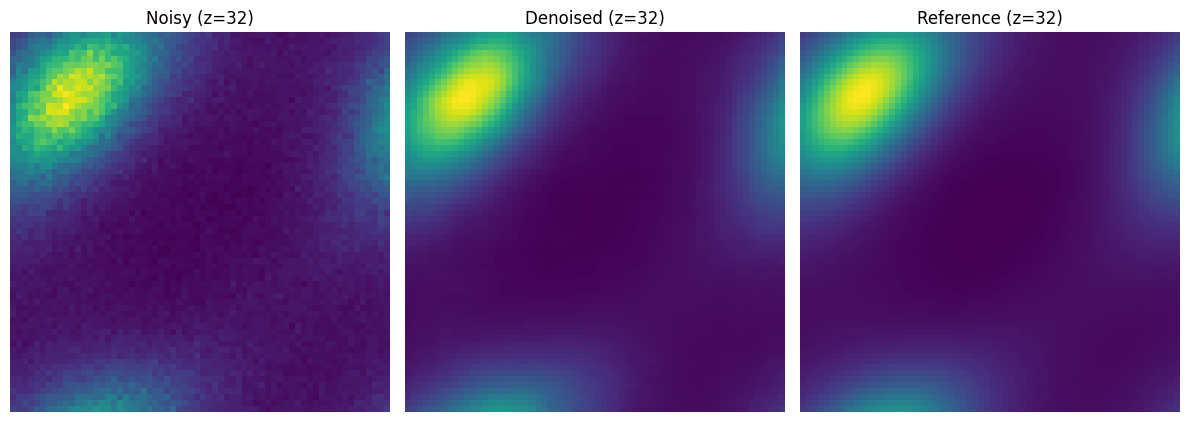


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005160960_nature_denoised.npy
Sample 5160960 | nature JSD = 0.000553
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000561

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000561


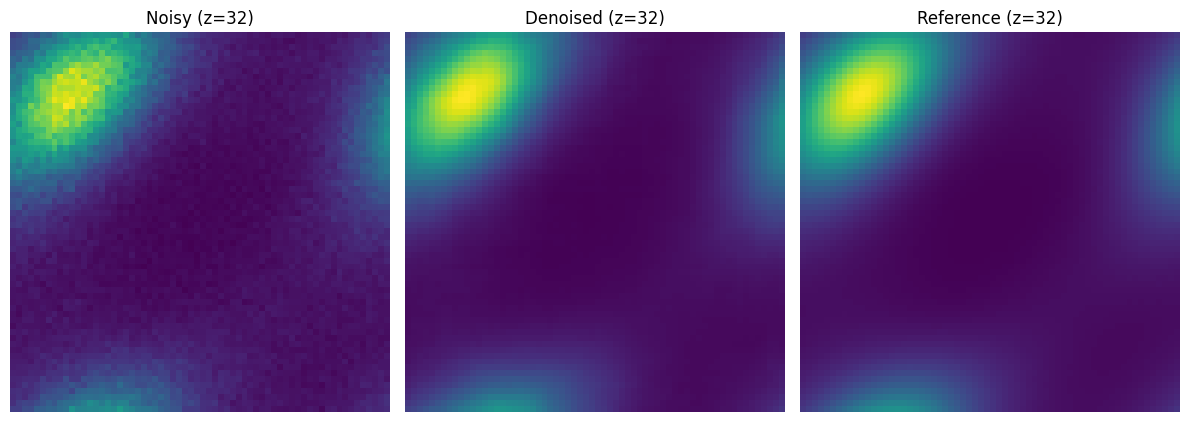


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005242880_nature_denoised.npy
Sample 5242880 | nature JSD = 0.000561
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000582

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000582


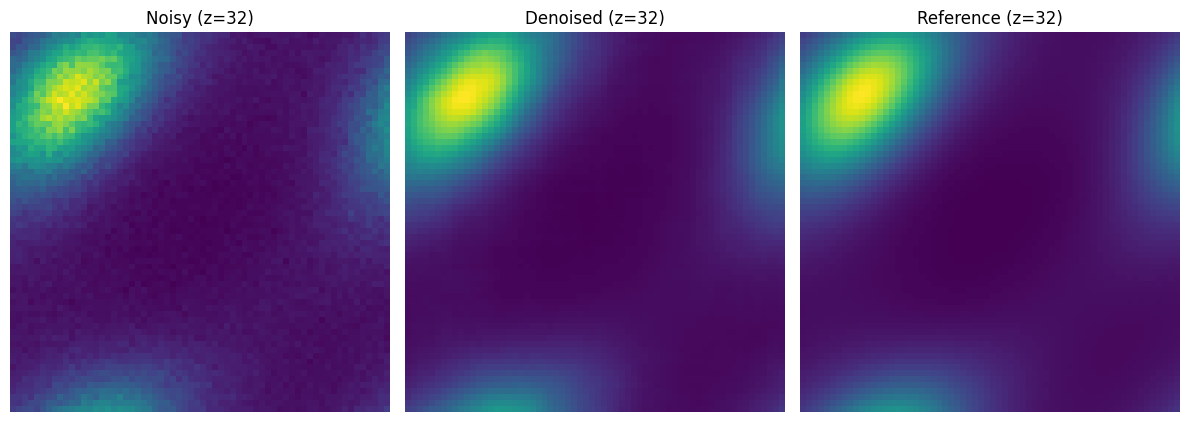


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0006881280_nature_denoised.npy
Sample 6881280 | nature JSD = 0.000582
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000640

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000640


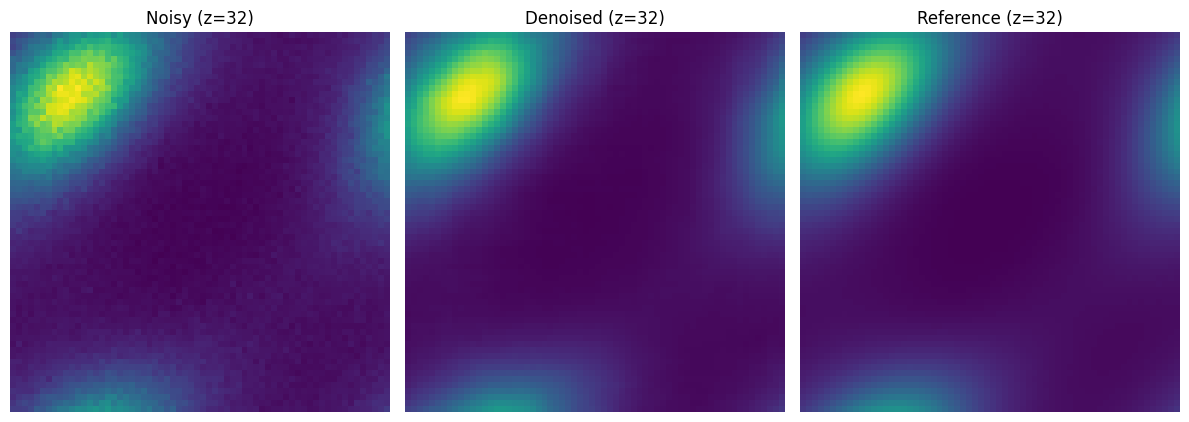


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010321920_nature_denoised.npy
Sample 10321920 | nature JSD = 0.000640
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000642

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000642


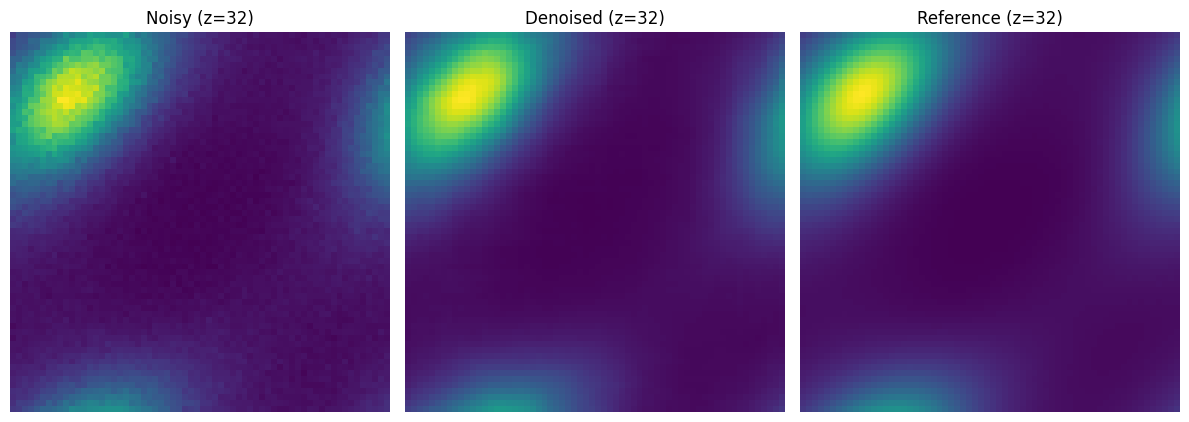


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010485760_nature_denoised.npy
Sample 10485760 | nature JSD = 0.000642
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000673

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000673


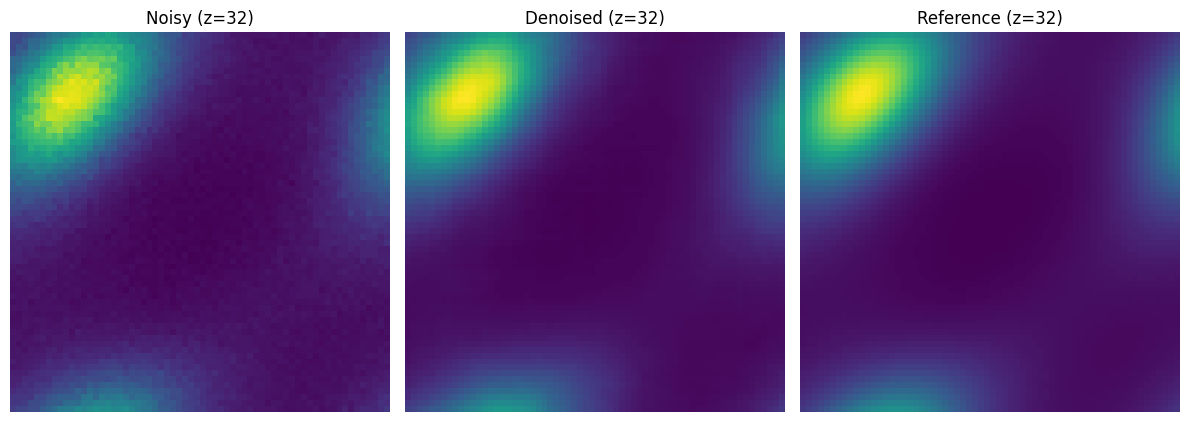


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0013762560_nature_denoised.npy
Sample 13762560 | nature JSD = 0.000673
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000735

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000735


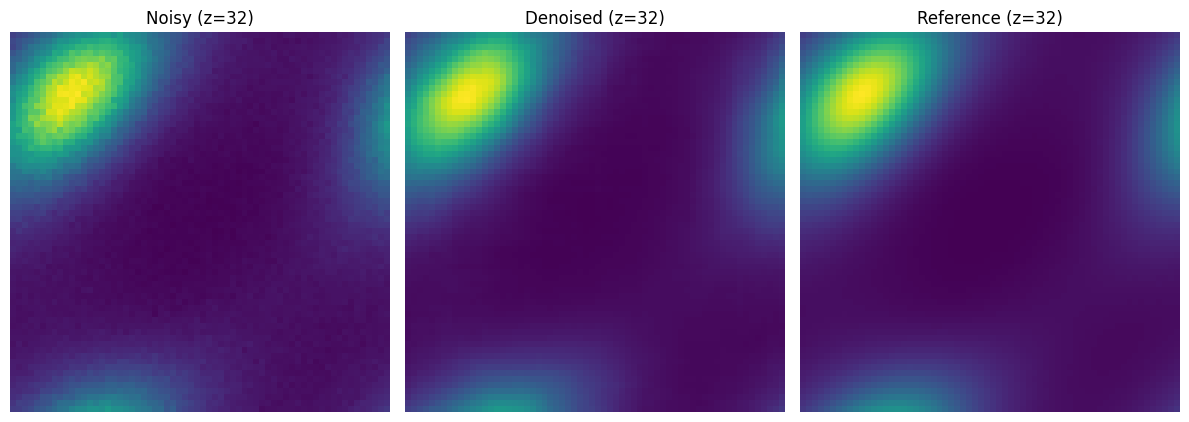


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0020643840_nature_denoised.npy
Sample 20643840 | nature JSD = 0.000735
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000779

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000779


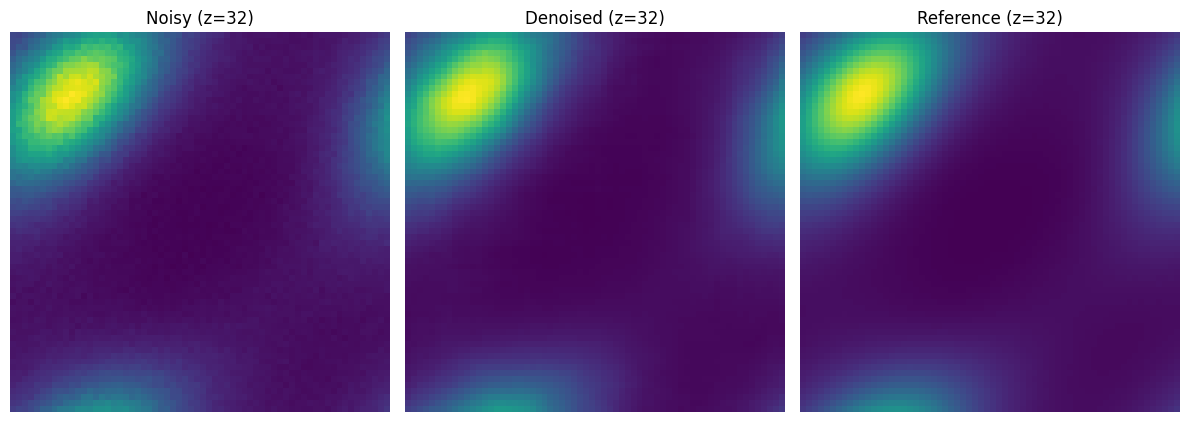


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0027525120_nature_denoised.npy
Sample 27525120 | nature JSD = 0.000779
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000818

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000818


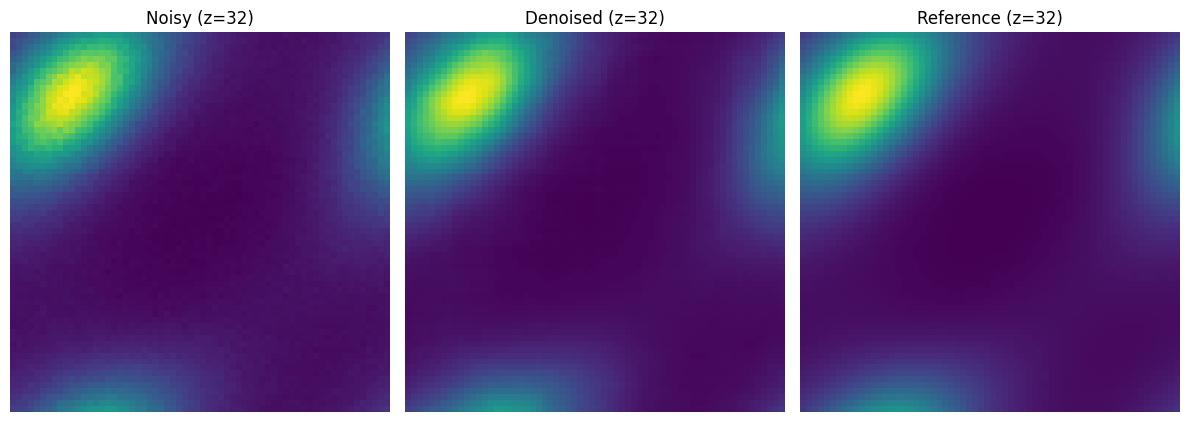


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0041287680_nature_denoised.npy
Sample 41287680 | nature JSD = 0.000818
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000858

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000858


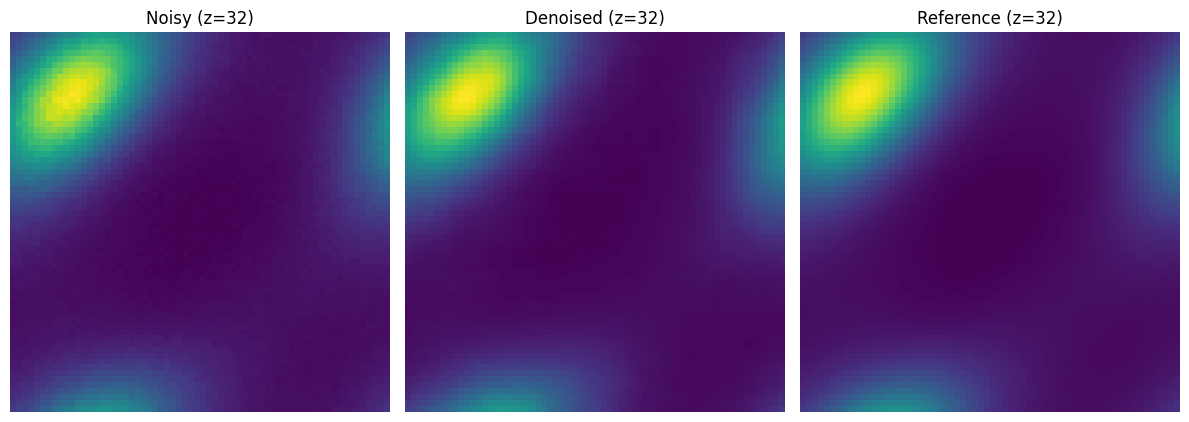


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0055050240_nature_denoised.npy
Sample 55050240 | nature JSD = 0.000858
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000890

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000890


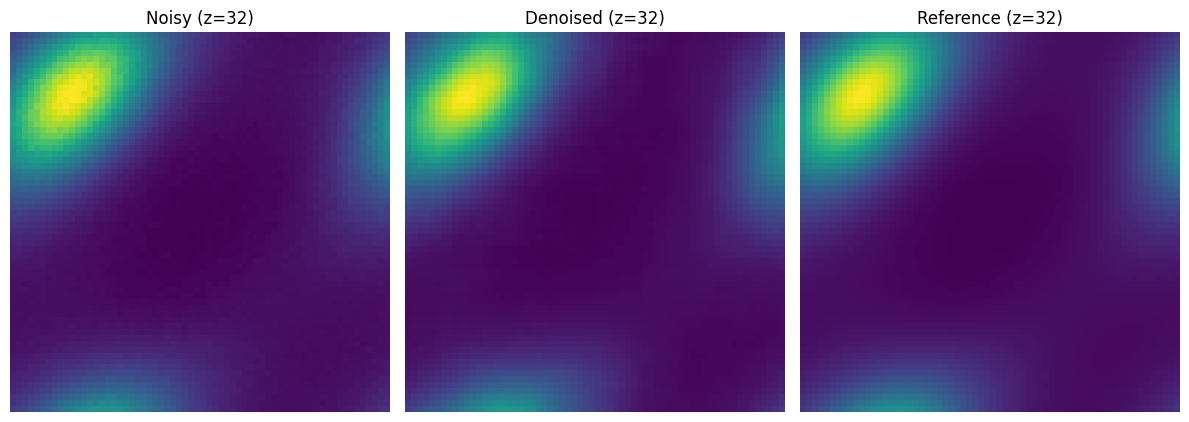


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0082575360_nature_denoised.npy
Sample 82575360 | nature JSD = 0.000890
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000923

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000923


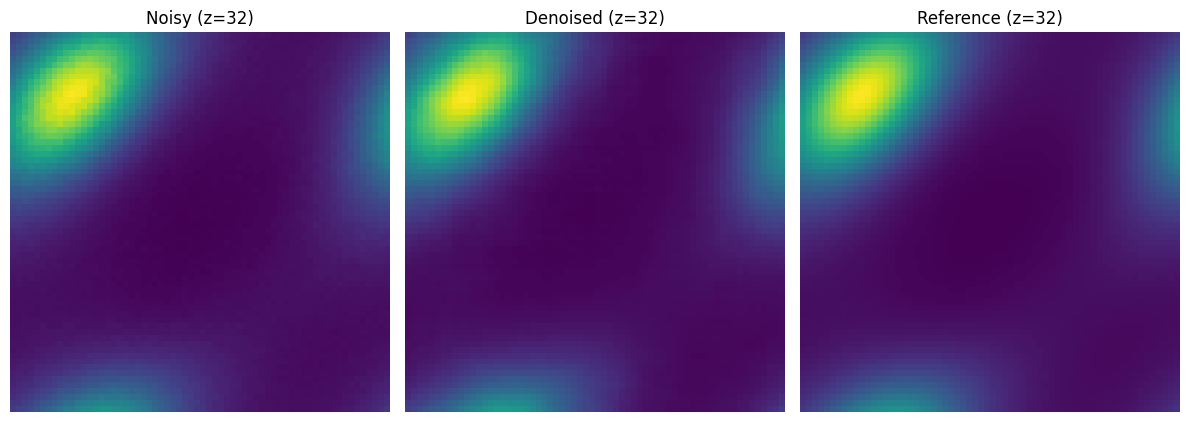


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0110100480_nature_denoised.npy
Sample 110100480 | nature JSD = 0.000923
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000951

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000951


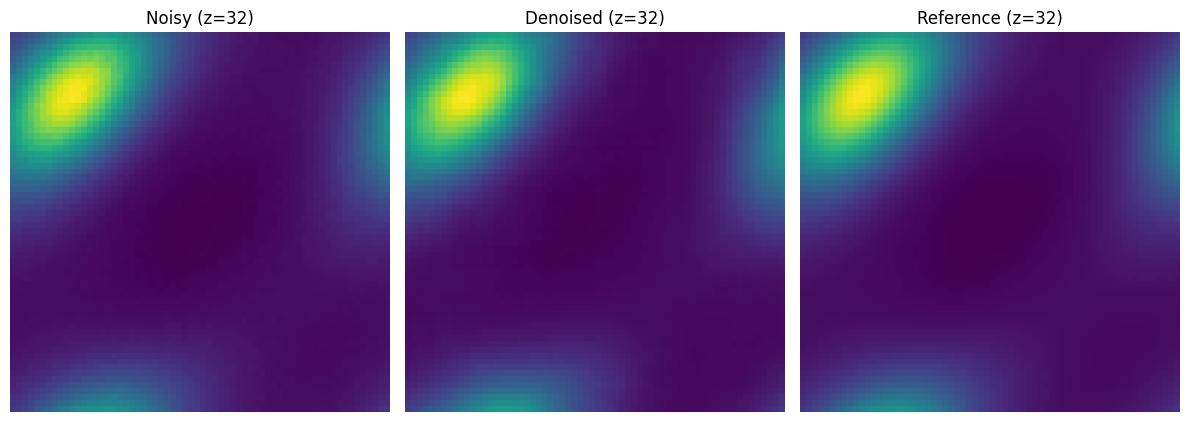


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0165150720_nature_denoised.npy
Sample 165150720 | nature JSD = 0.000951
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000965

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000965


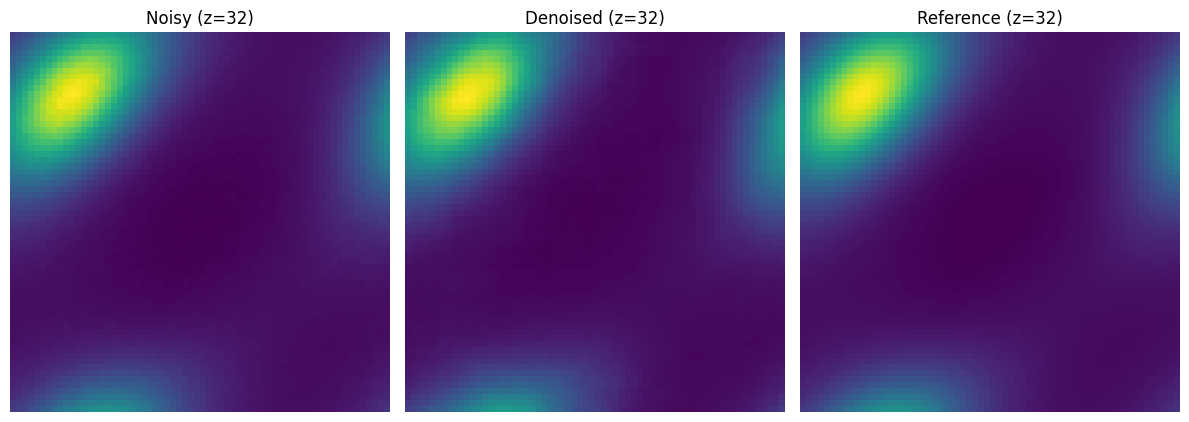


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0220200960_nature_denoised.npy
Sample 220200960 | nature JSD = 0.000965
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000991

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000991


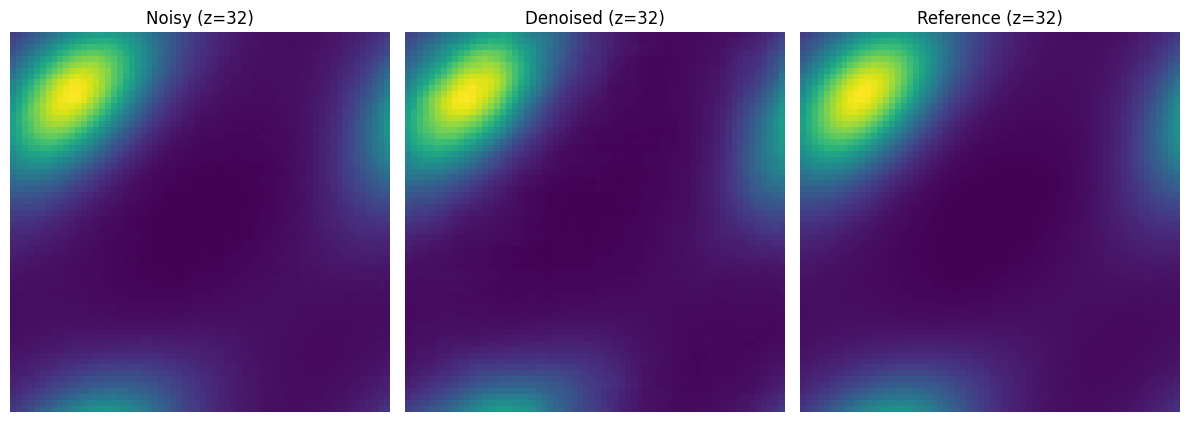


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0330301440_nature_denoised.npy
Sample 330301440 | nature JSD = 0.000991
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.001003

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.001003


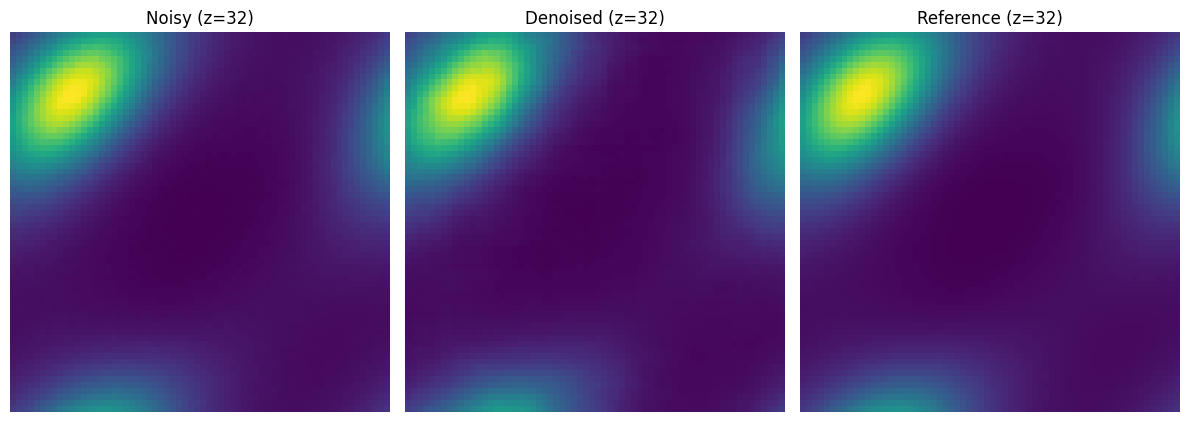


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0440401920_nature_denoised.npy
Sample 440401920 | nature JSD = 0.001003
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.001020

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.001020


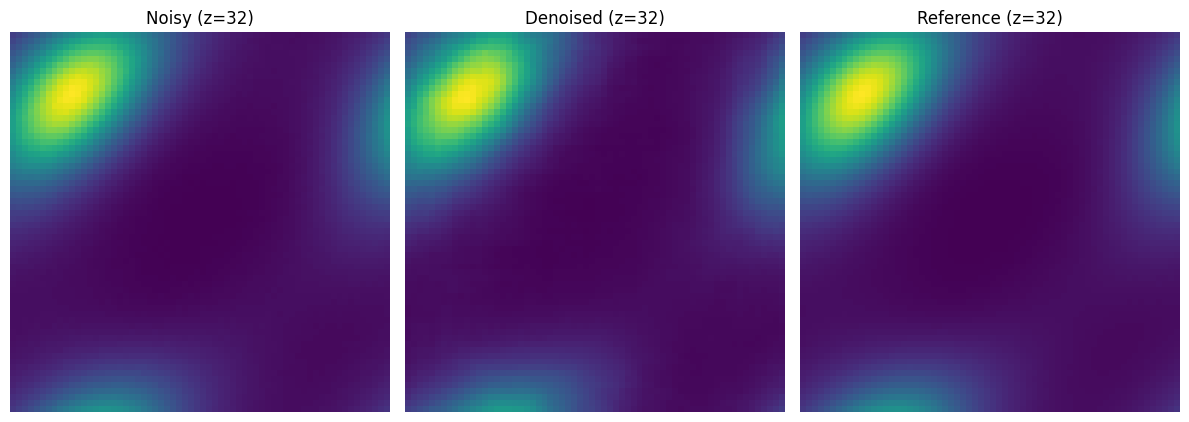


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0660602880_nature_denoised.npy
Sample 660602880 | nature JSD = 0.001020
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001036

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001036


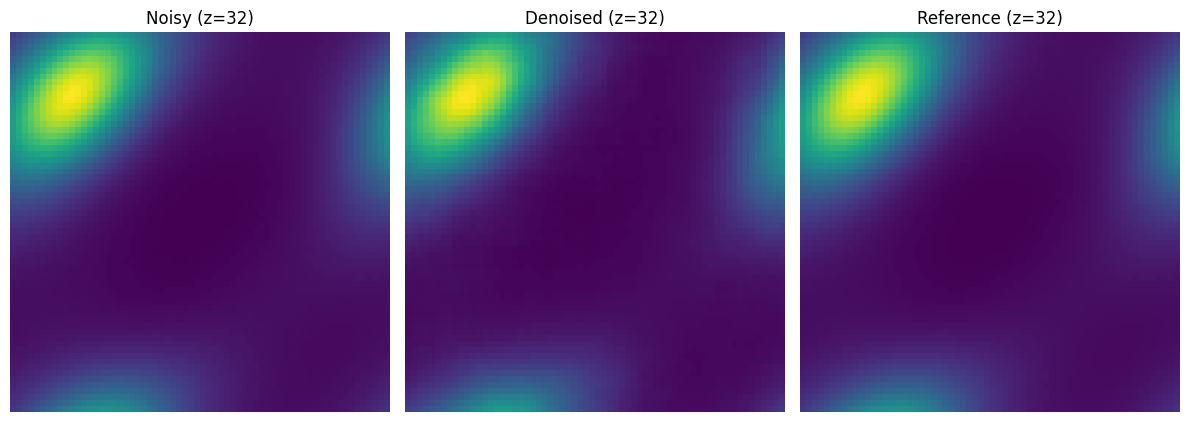


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_1321205760_nature_denoised.npy
Sample 1321205760 | nature JSD = 0.001036
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.001050

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.001050


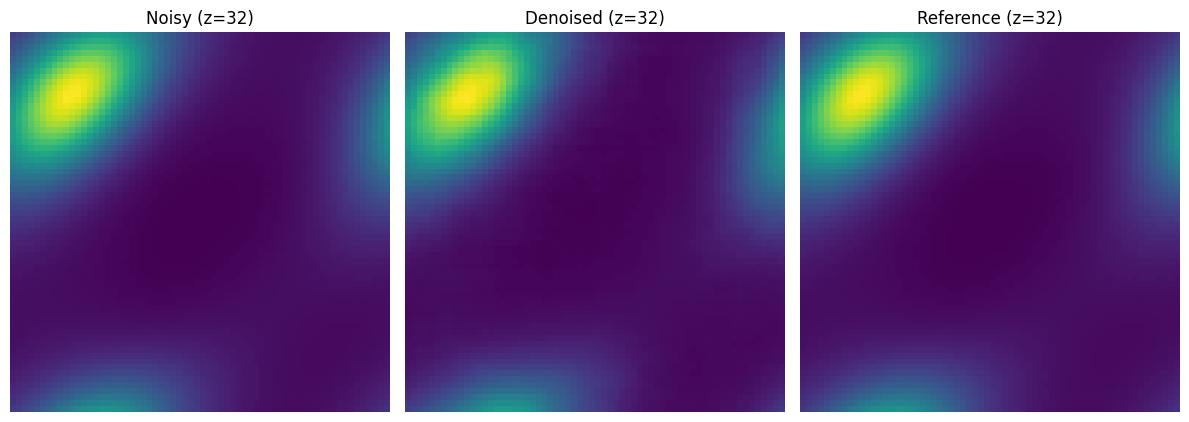


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_2642411520_nature_denoised.npy
Sample 2642411520 | nature JSD = 0.001050
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001057

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001057


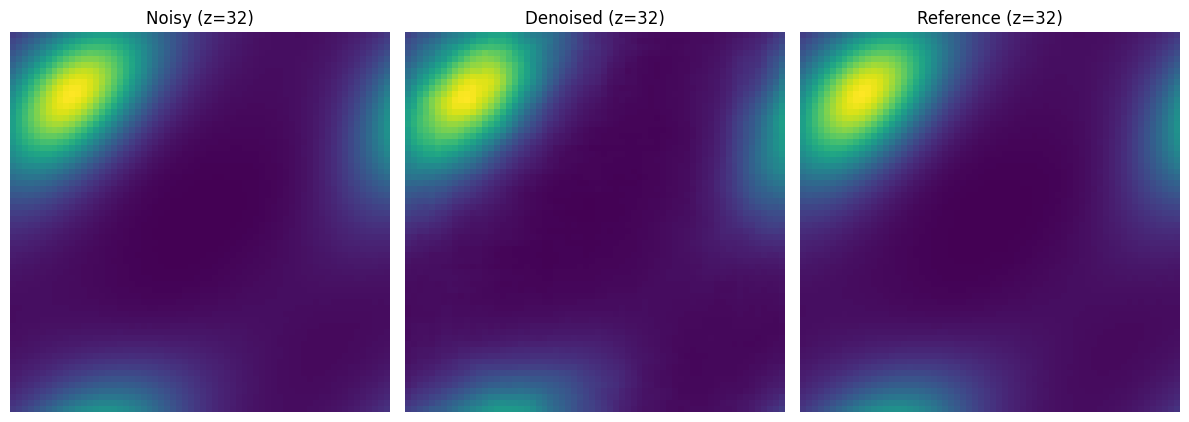


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_5284823040_nature_denoised.npy
Sample 5284823040 | nature JSD = 0.001057

=== Running model: CAE ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0113
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.022480

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0113
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.022480


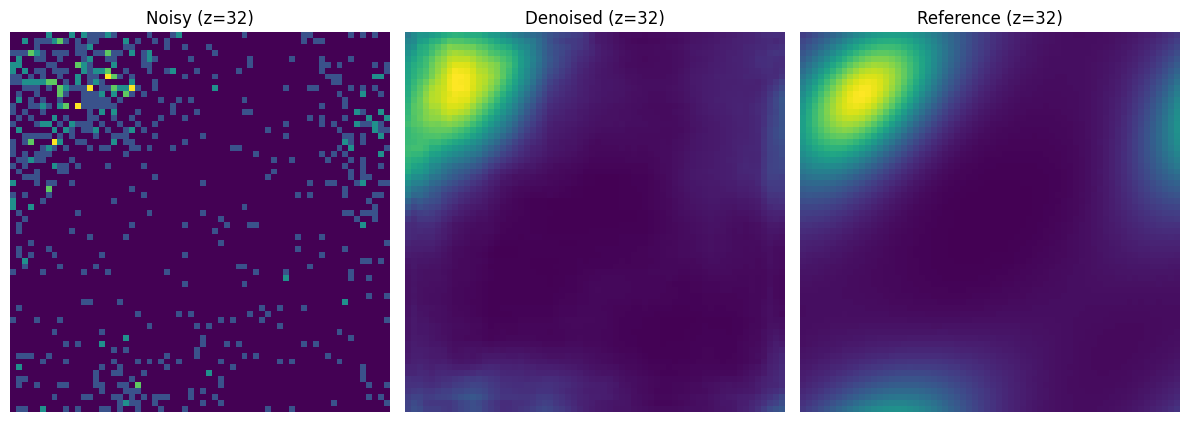


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000010240_CAE_denoised.npy
Sample 10240 | CAE JSD = 0.022480
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0061
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.008951

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0061
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.008951


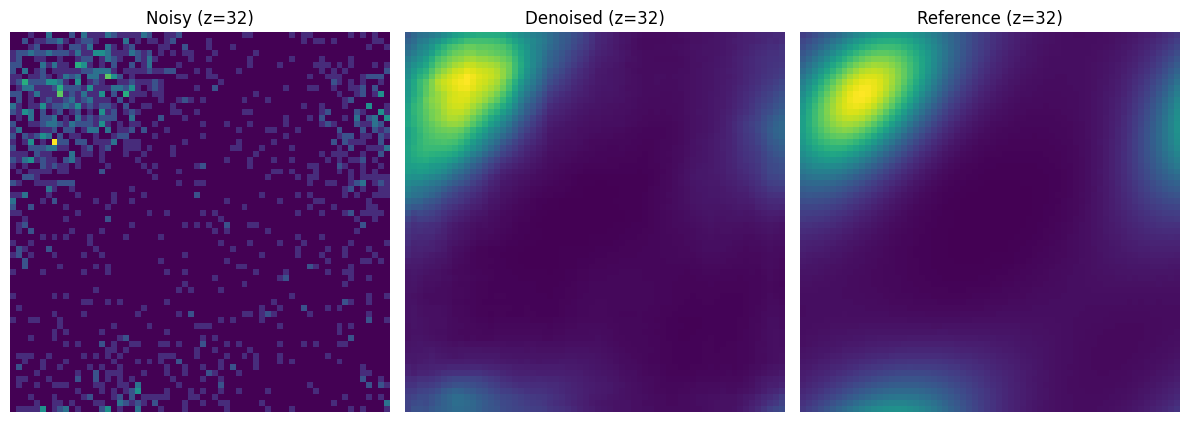


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000020480_CAE_denoised.npy
Sample 20480 | CAE JSD = 0.008951
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0031
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.003313

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0031
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.003313


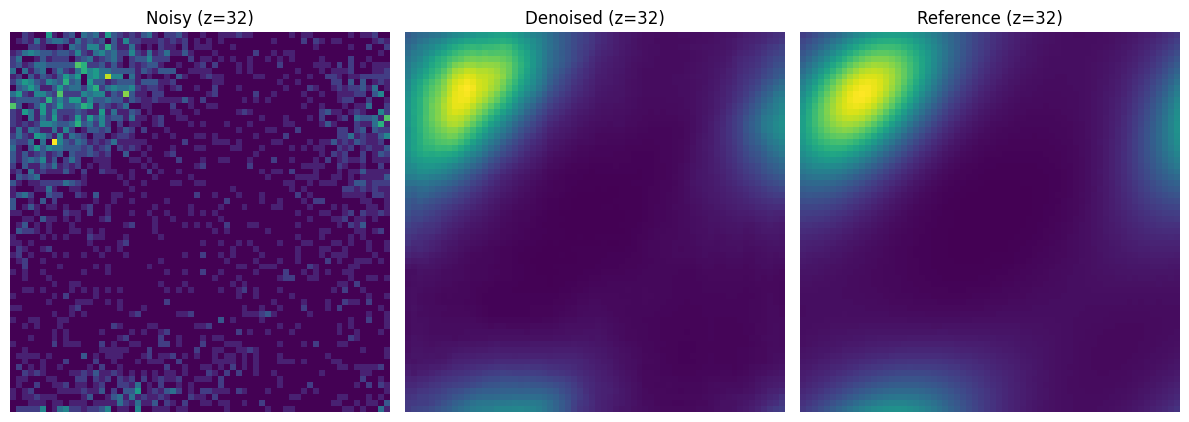


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000040960_CAE_denoised.npy
Sample 40960 | CAE JSD = 0.003313
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.001221

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.001221


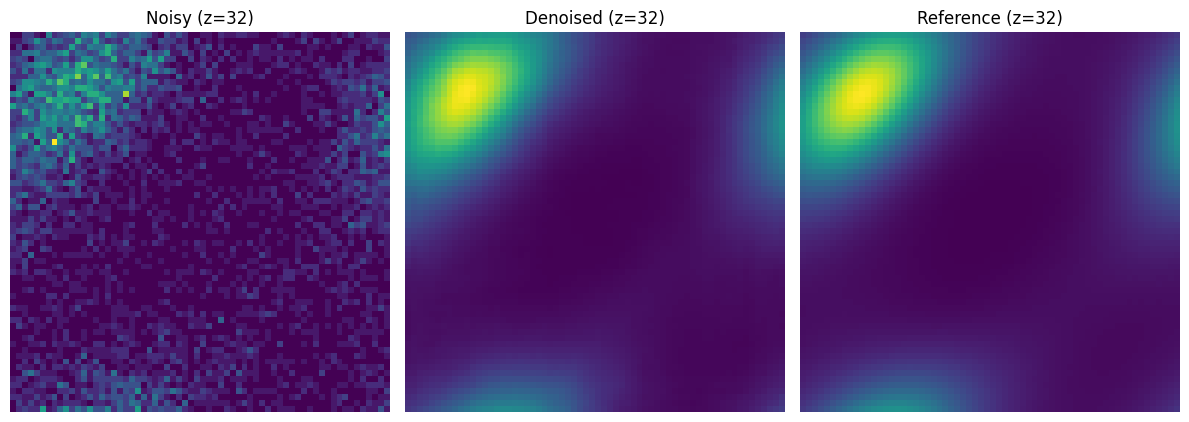


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000081920_CAE_denoised.npy
Sample 81920 | CAE JSD = 0.001221
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000812

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.000812


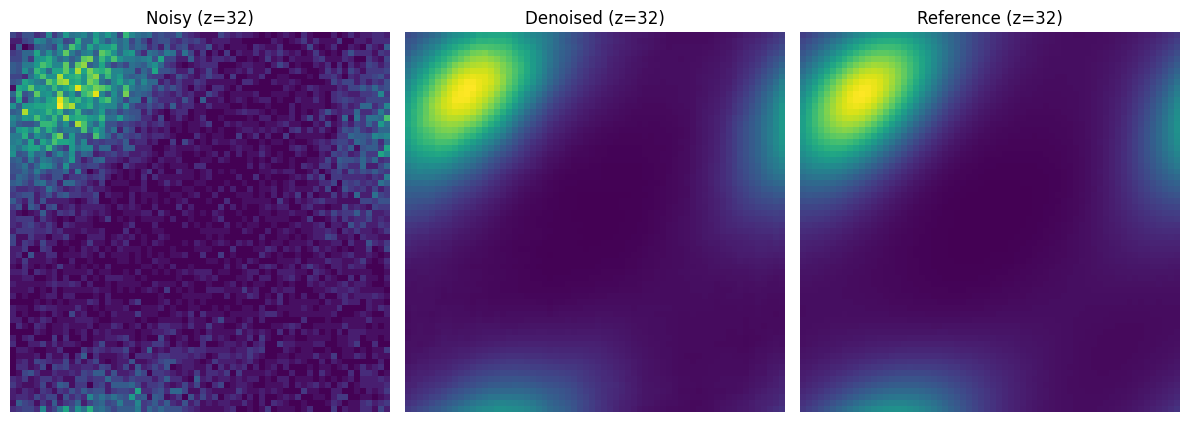


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000163840_CAE_denoised.npy
Sample 163840 | CAE JSD = 0.000812
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000604

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.000604


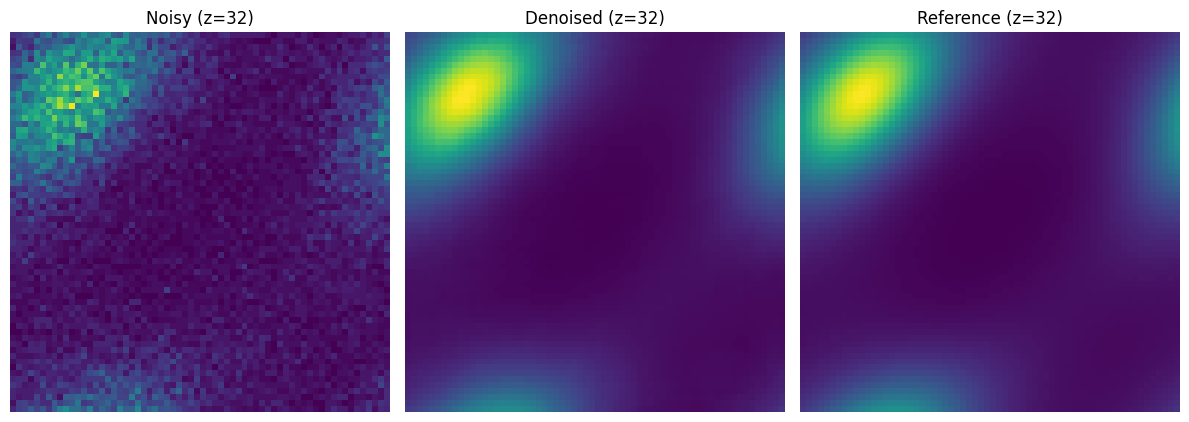


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000327680_CAE_denoised.npy
Sample 327680 | CAE JSD = 0.000604
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000585

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.000585


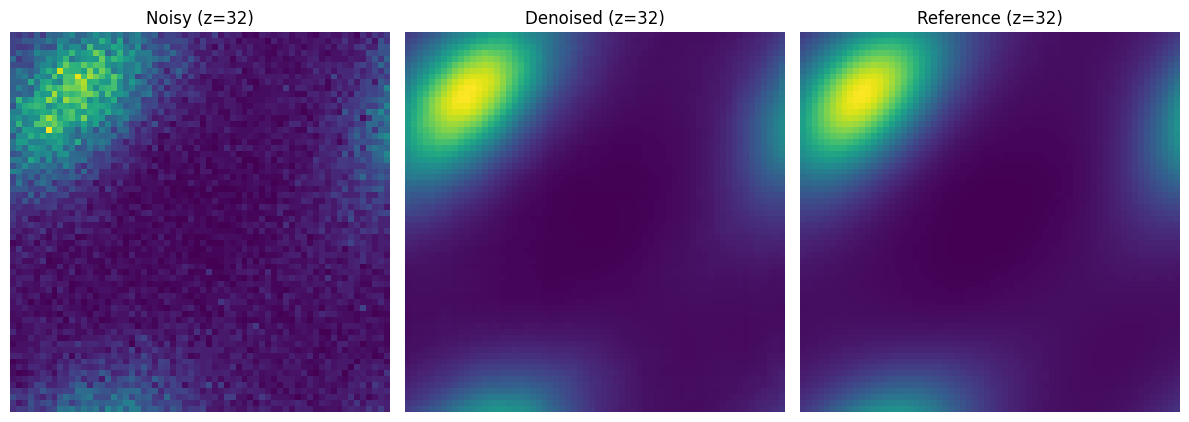


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000430080_CAE_denoised.npy
Sample 430080 | CAE JSD = 0.000585
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000568

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.000568


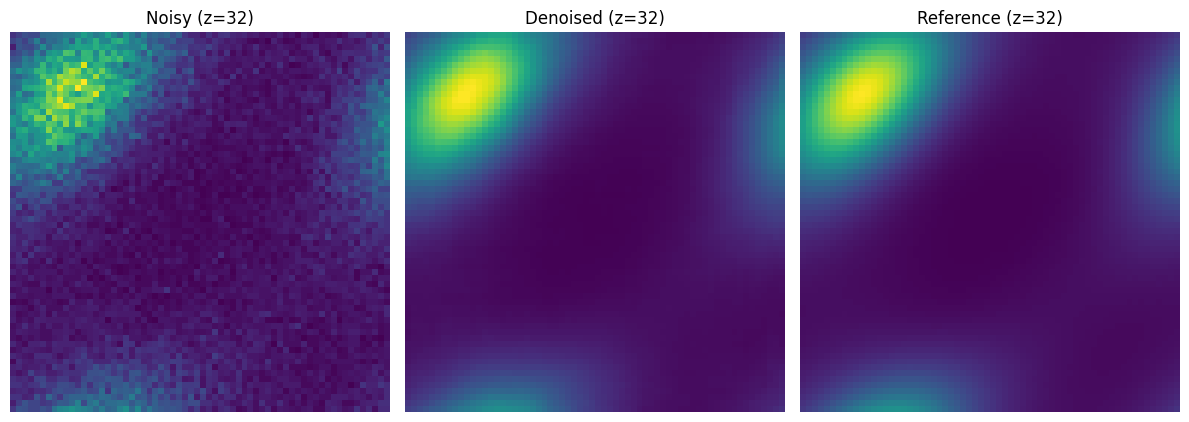


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360_CAE_denoised.npy
Sample 655360 | CAE JSD = 0.000568
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000567

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.000567


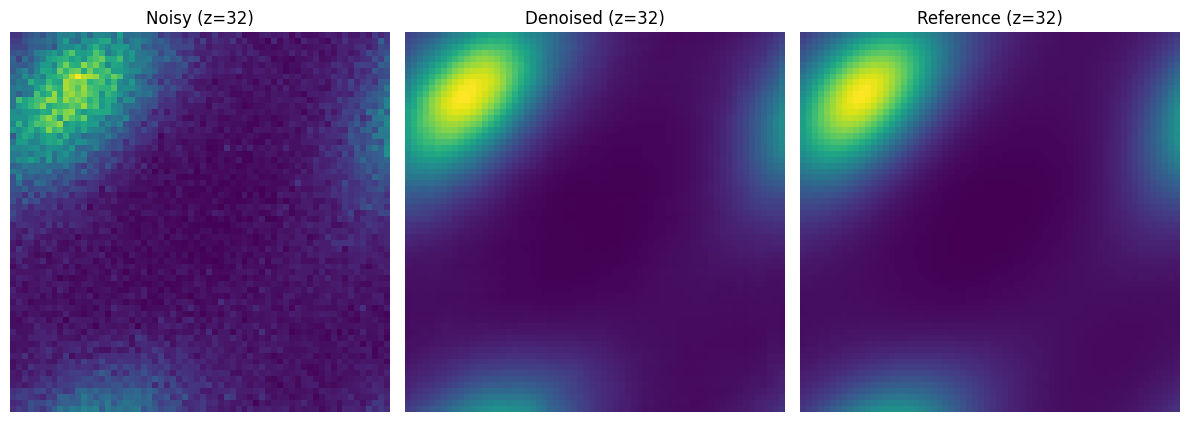


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000860160_CAE_denoised.npy
Sample 860160 | CAE JSD = 0.000567
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000596

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.000596


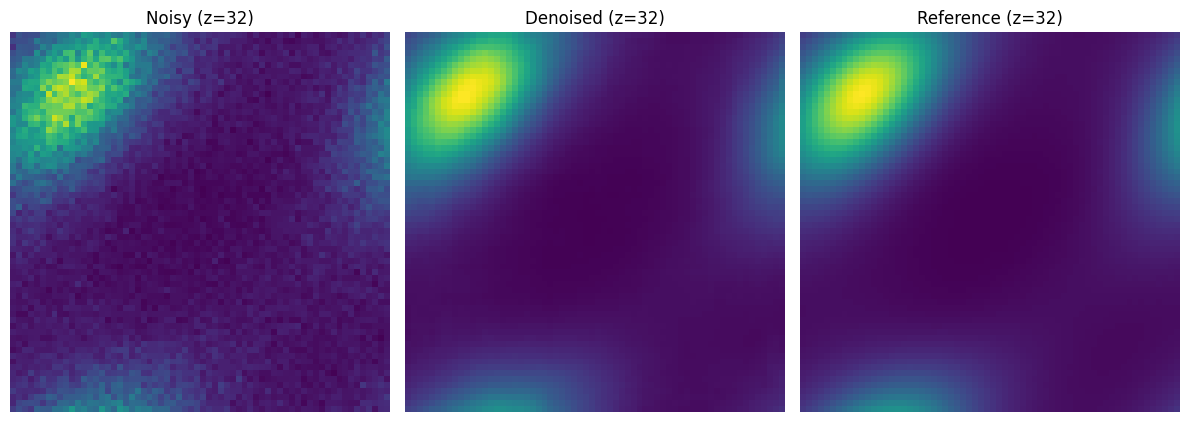


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001310720_CAE_denoised.npy
Sample 1310720 | CAE JSD = 0.000596
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000544

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.000544


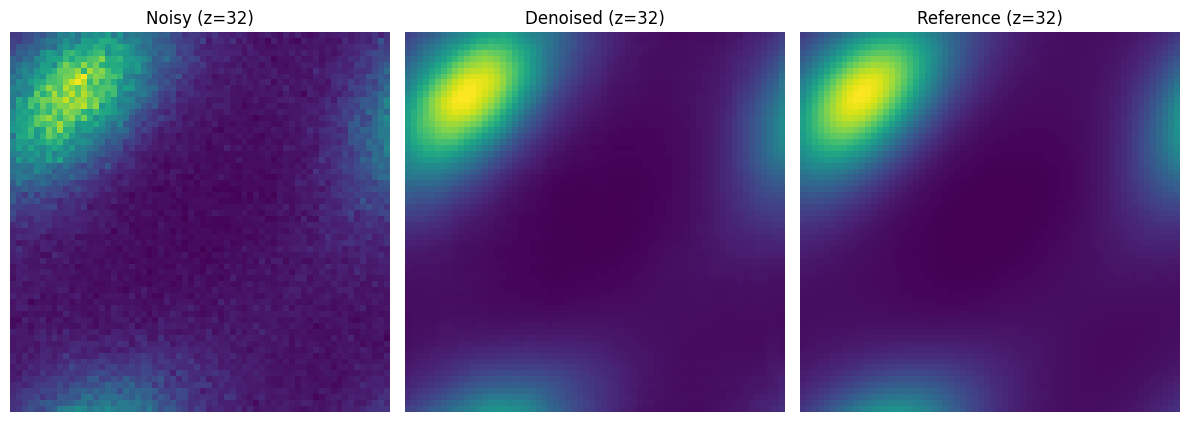


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001720320_CAE_denoised.npy
Sample 1720320 | CAE JSD = 0.000544
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000537

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.000537


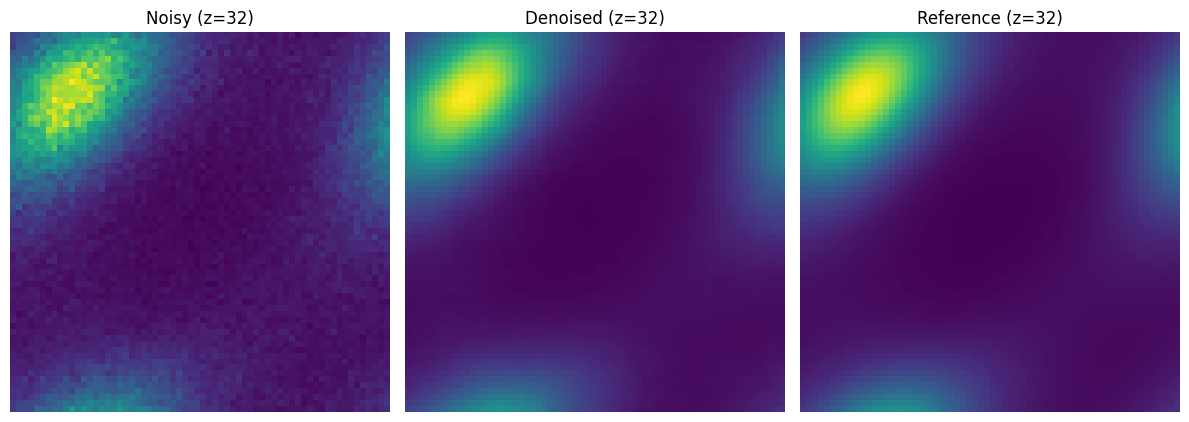


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0002621440_CAE_denoised.npy
Sample 2621440 | CAE JSD = 0.000537
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000539

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.000539


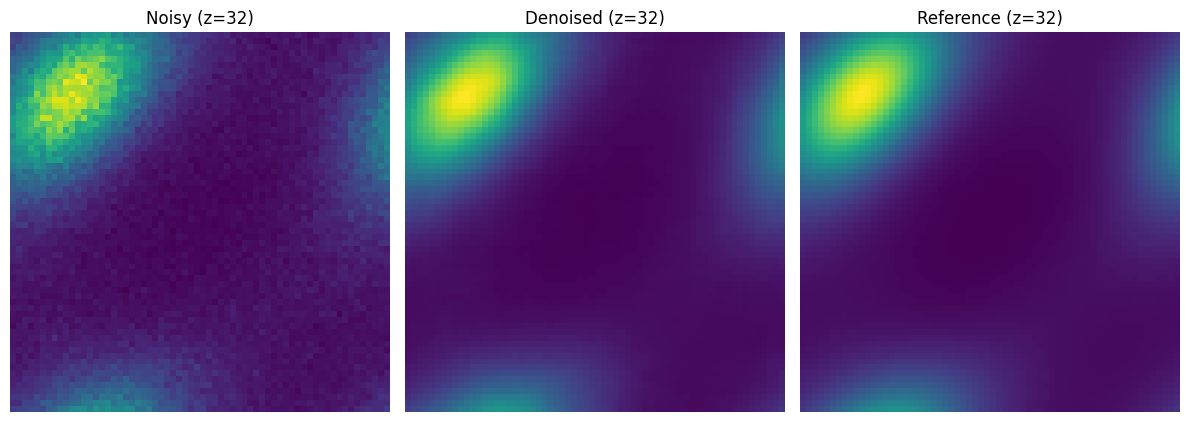


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0003440640_CAE_denoised.npy
Sample 3440640 | CAE JSD = 0.000539
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000553

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.000553


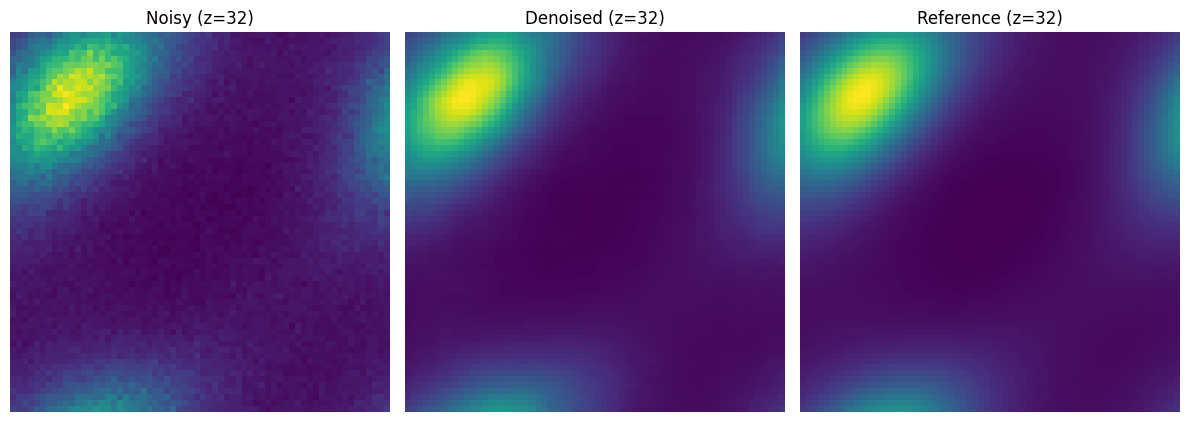


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005160960_CAE_denoised.npy
Sample 5160960 | CAE JSD = 0.000553
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000561

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.000561


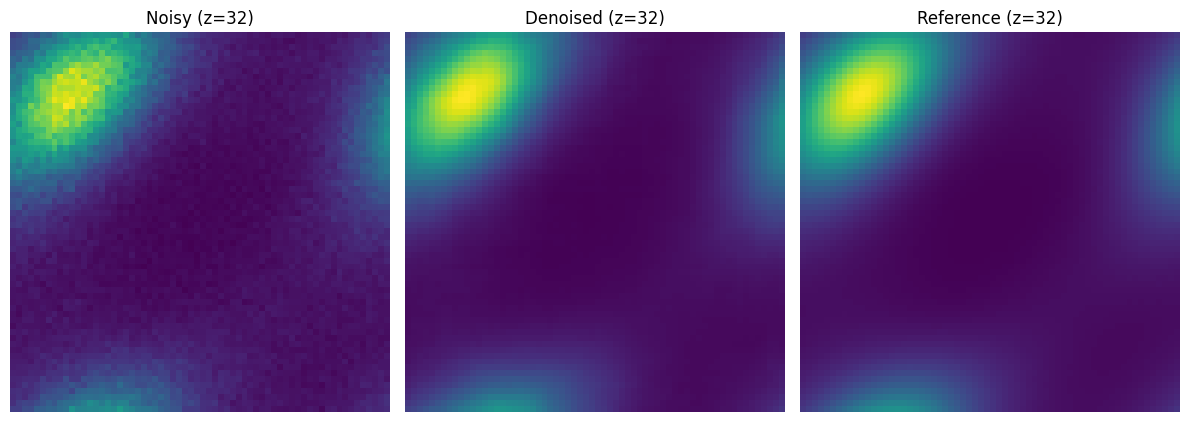


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005242880_CAE_denoised.npy
Sample 5242880 | CAE JSD = 0.000561
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000582

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.000582


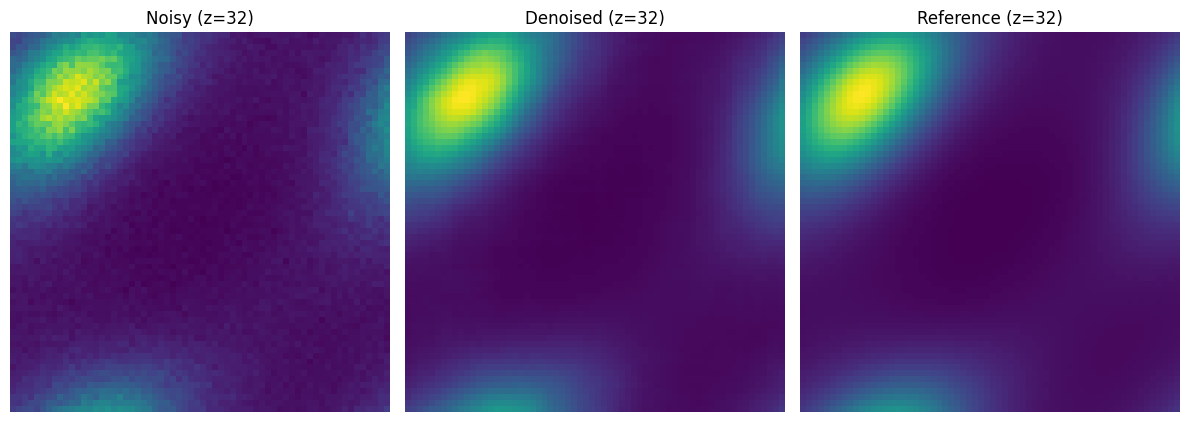


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0006881280_CAE_denoised.npy
Sample 6881280 | CAE JSD = 0.000582
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000640

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000640


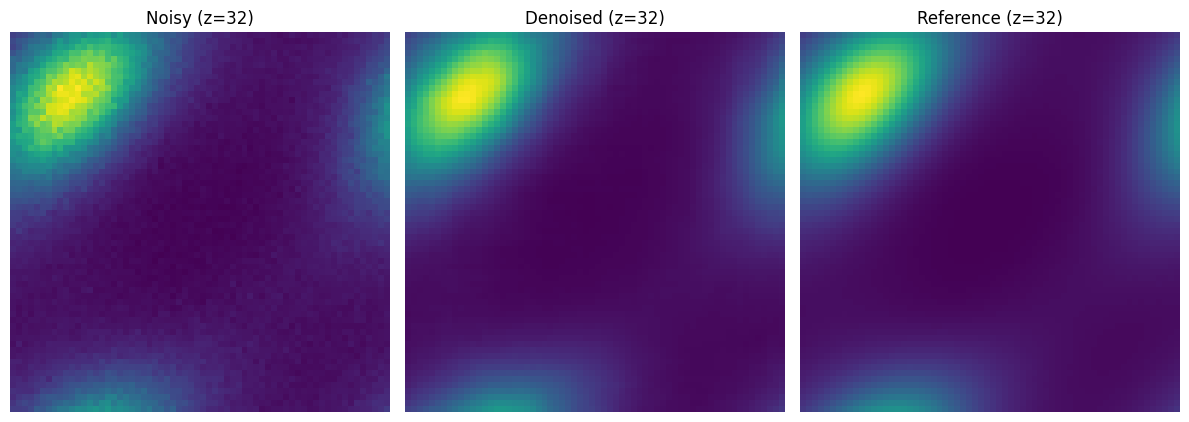


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010321920_CAE_denoised.npy
Sample 10321920 | CAE JSD = 0.000640
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000642

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000642


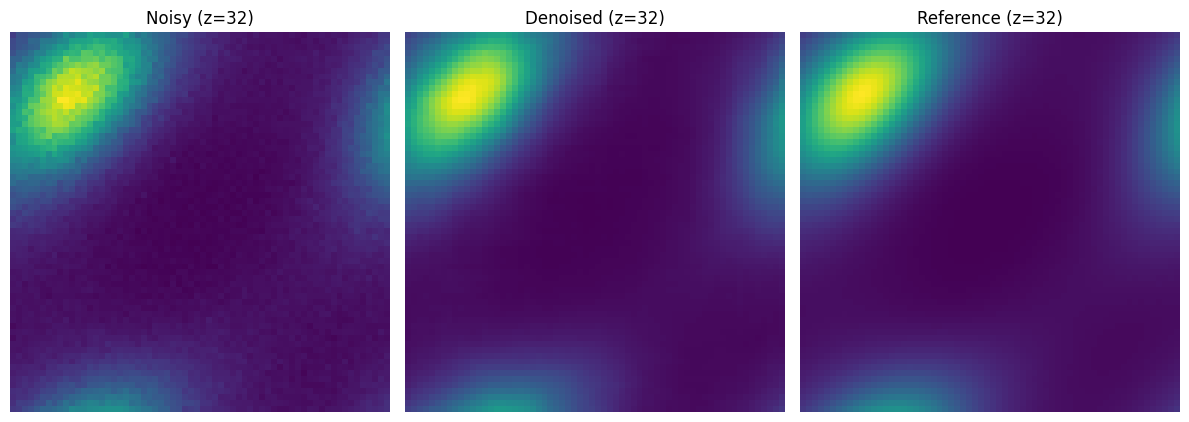


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010485760_CAE_denoised.npy
Sample 10485760 | CAE JSD = 0.000642
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000673

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000673


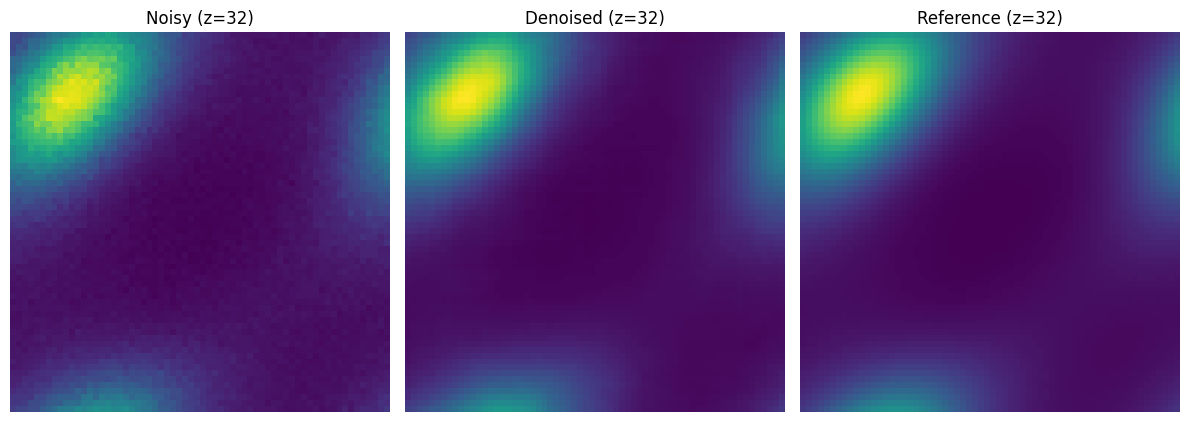


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0013762560_CAE_denoised.npy
Sample 13762560 | CAE JSD = 0.000673
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000735

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000735


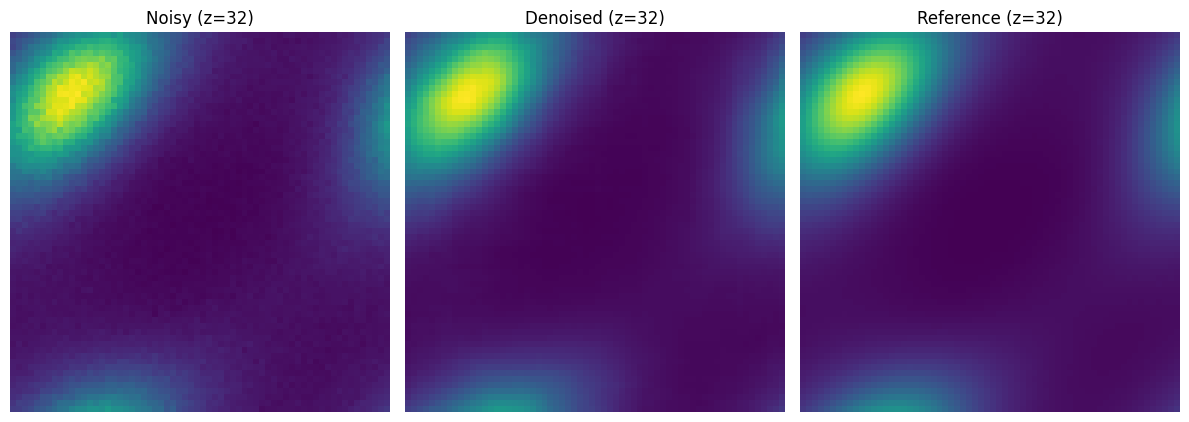


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0020643840_CAE_denoised.npy
Sample 20643840 | CAE JSD = 0.000735
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000779

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000779


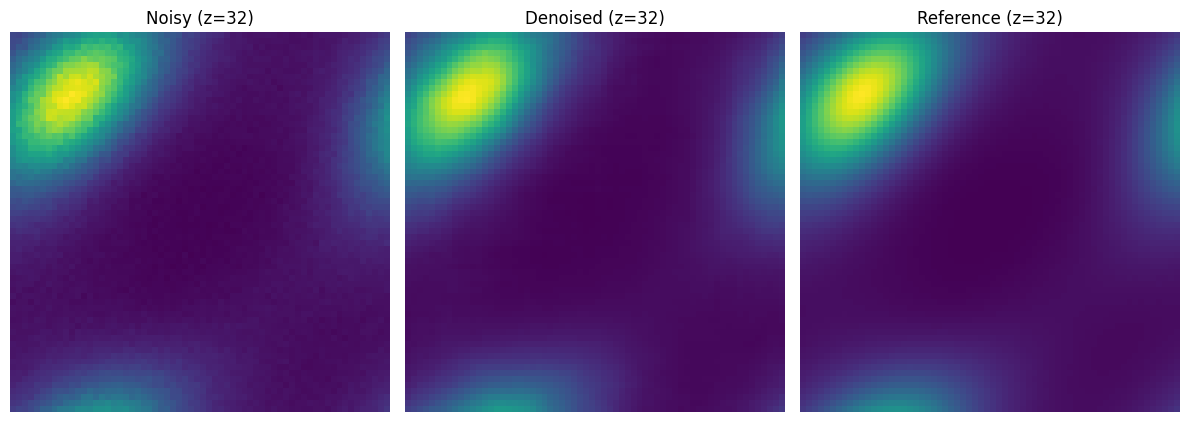


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0027525120_CAE_denoised.npy
Sample 27525120 | CAE JSD = 0.000779
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000818

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000818


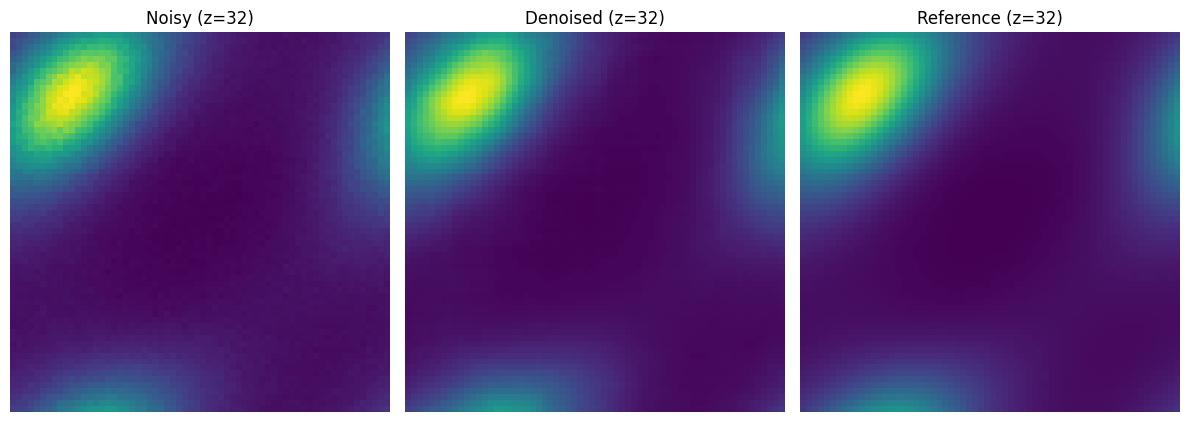


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0041287680_CAE_denoised.npy
Sample 41287680 | CAE JSD = 0.000818
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000858

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000858


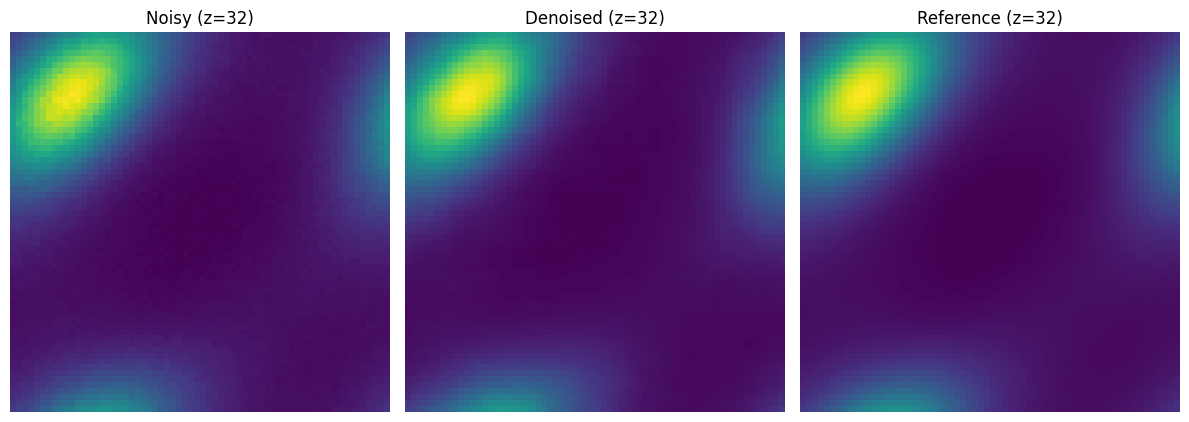


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0055050240_CAE_denoised.npy
Sample 55050240 | CAE JSD = 0.000858
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000890

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000890


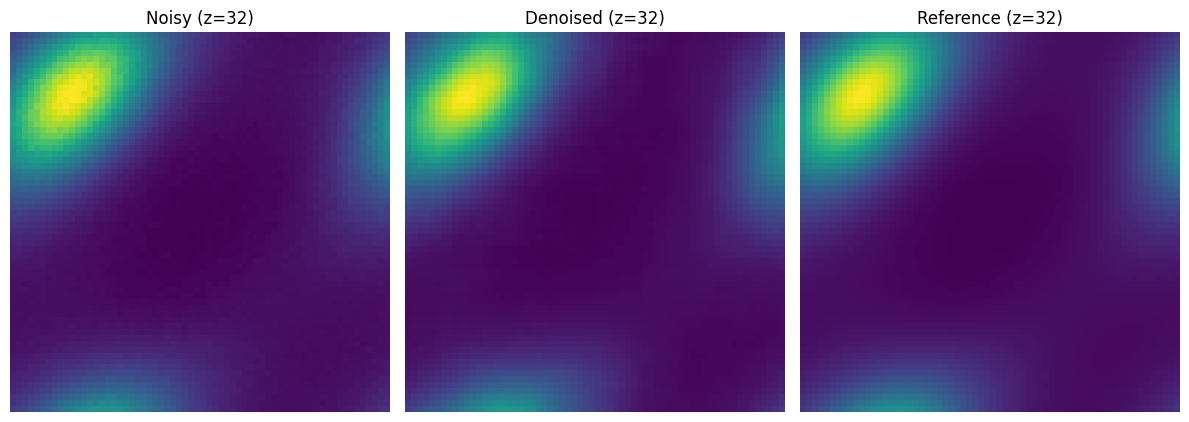


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0082575360_CAE_denoised.npy
Sample 82575360 | CAE JSD = 0.000890
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000923

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000923


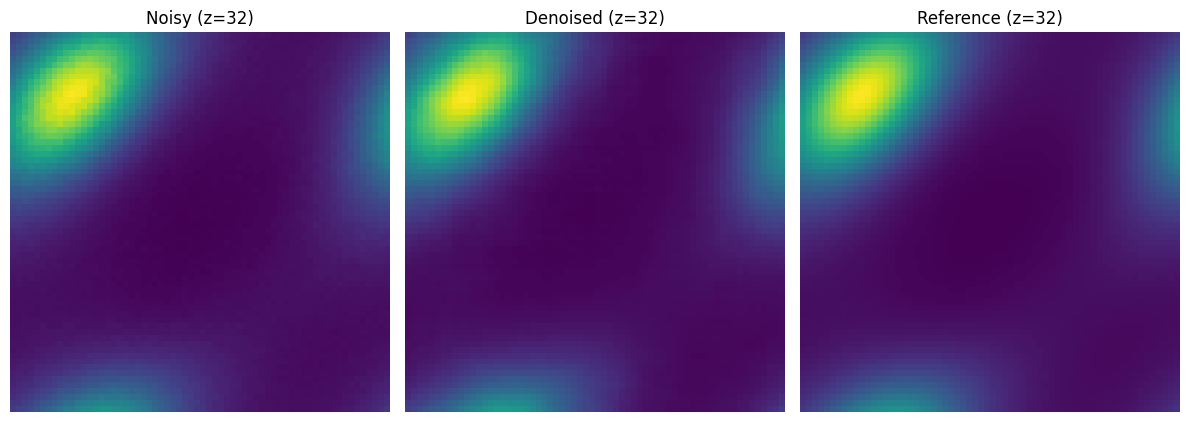


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0110100480_CAE_denoised.npy
Sample 110100480 | CAE JSD = 0.000923
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000951

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000951


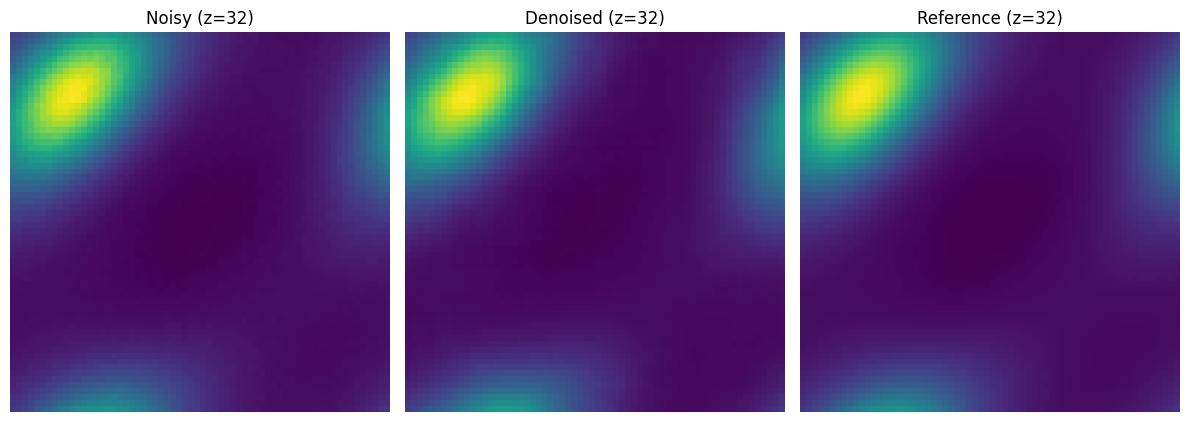


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0165150720_CAE_denoised.npy
Sample 165150720 | CAE JSD = 0.000951
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000965

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000965


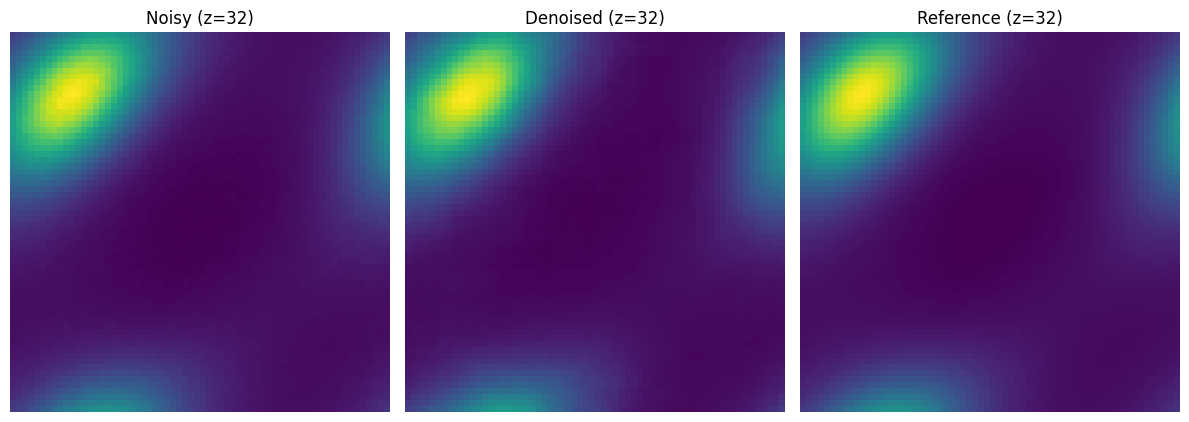


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0220200960_CAE_denoised.npy
Sample 220200960 | CAE JSD = 0.000965
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000991

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000991


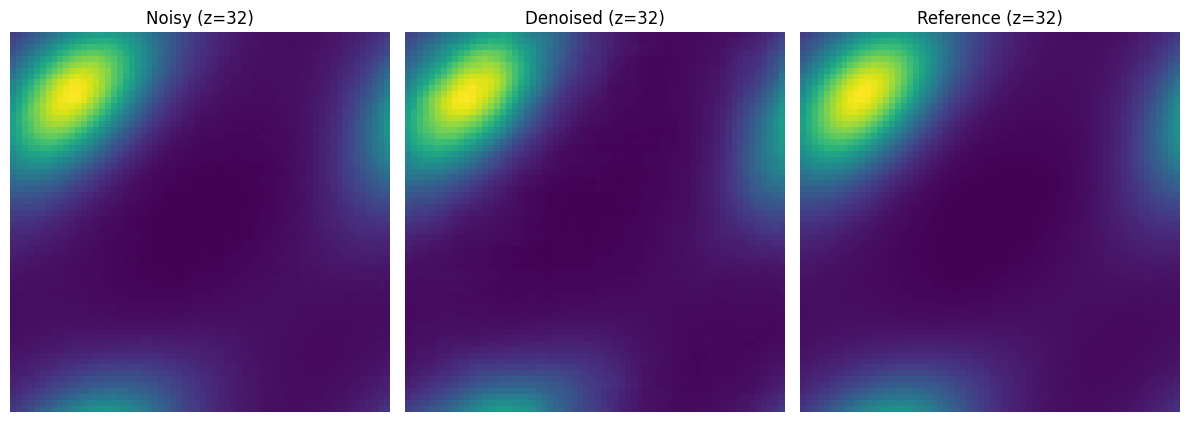


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0330301440_CAE_denoised.npy
Sample 330301440 | CAE JSD = 0.000991
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.001003

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.001003


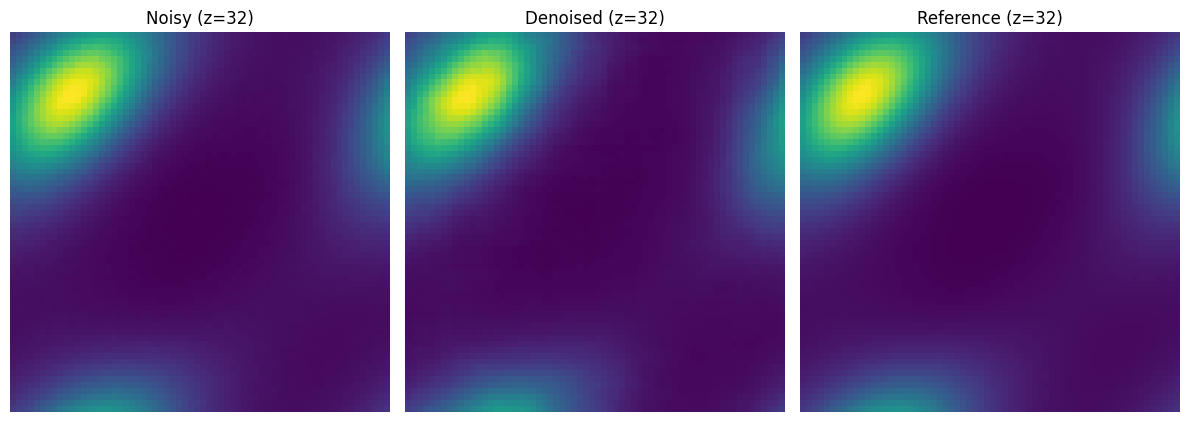


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0440401920_CAE_denoised.npy
Sample 440401920 | CAE JSD = 0.001003
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.001020

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.001020


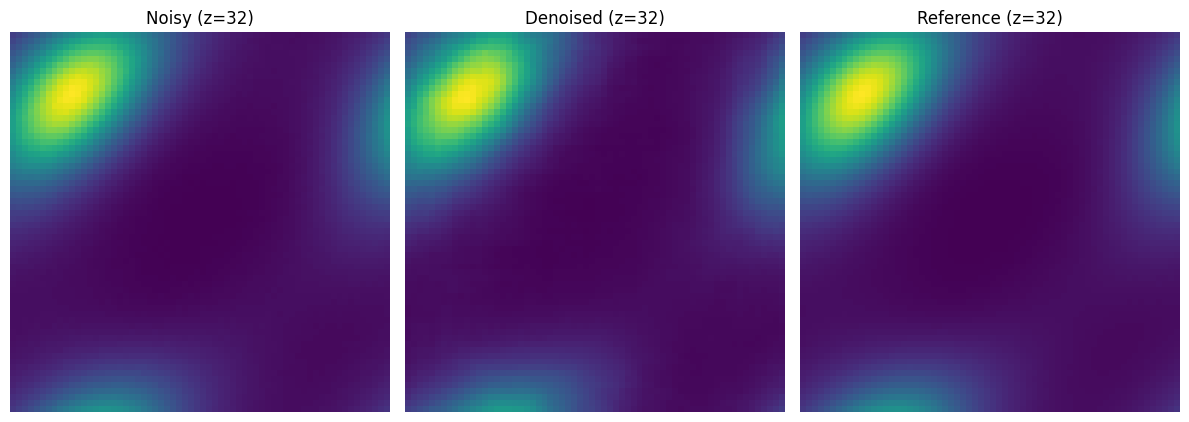


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0660602880_CAE_denoised.npy
Sample 660602880 | CAE JSD = 0.001020
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001036

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001036


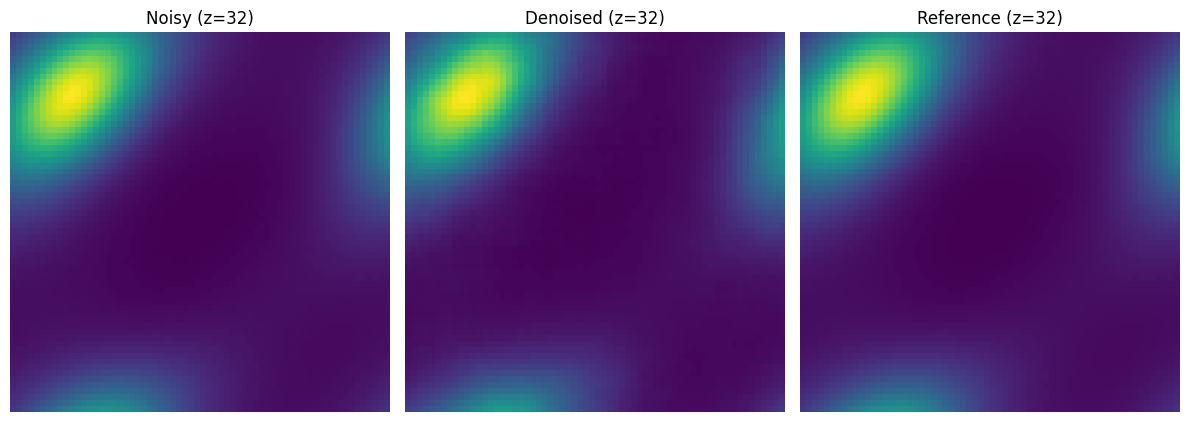


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_1321205760_CAE_denoised.npy
Sample 1321205760 | CAE JSD = 0.001036
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.001050

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.001050


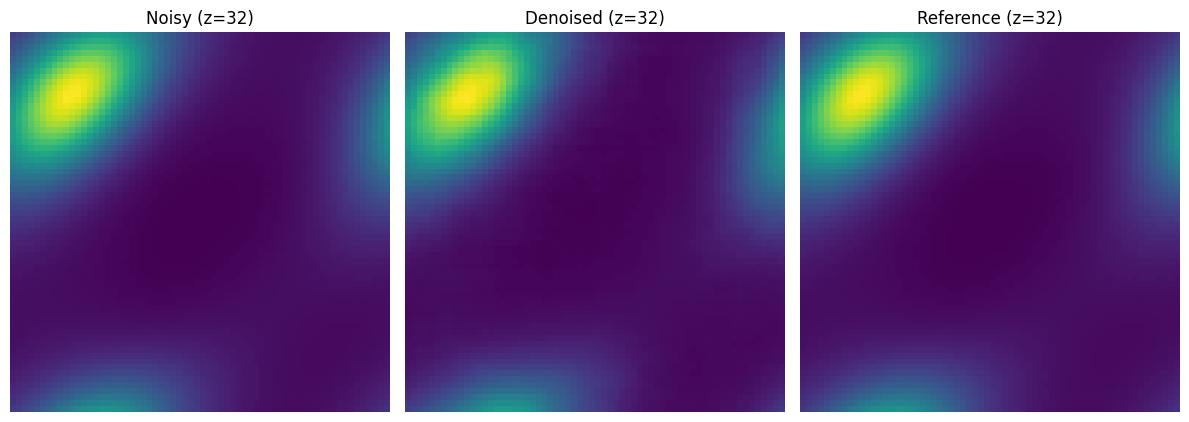


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_2642411520_CAE_denoised.npy
Sample 2642411520 | CAE JSD = 0.001050
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001057

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001057


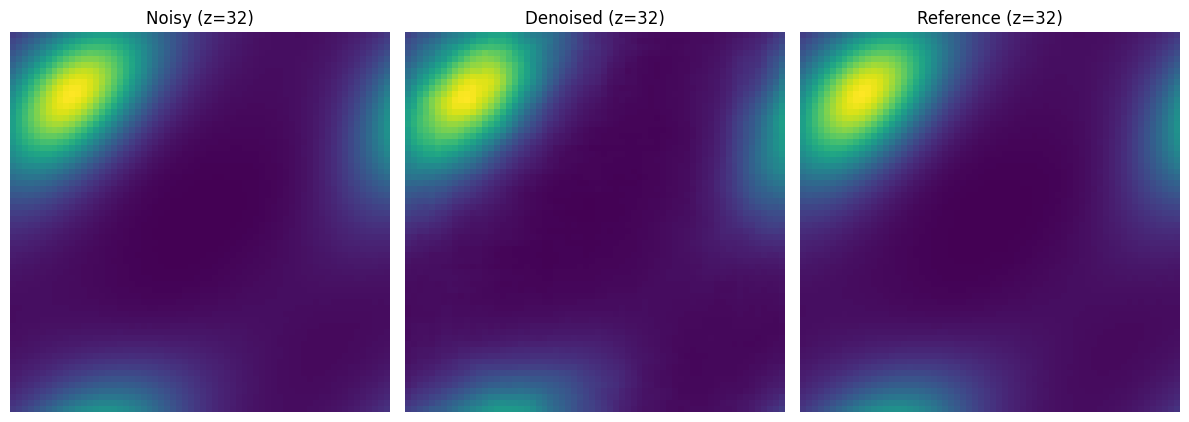


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_5284823040_CAE_denoised.npy
Sample 5284823040 | CAE JSD = 0.001057

=== Running model: bm3d ===
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0159
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.046333

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0159
JSD   (noisy vs ref):     0.442995
JSD   (denoised vs ref):  0.046333


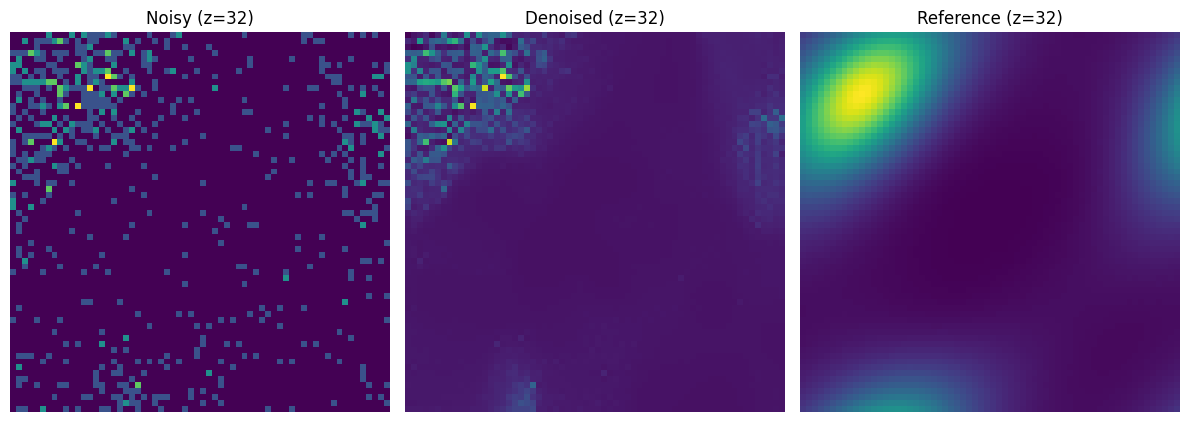


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000010240_bm3d_denoised.npy
Sample 10240 | bm3d JSD = 0.046333
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0143
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.033719

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0143
JSD   (noisy vs ref):     0.288600
JSD   (denoised vs ref):  0.033719


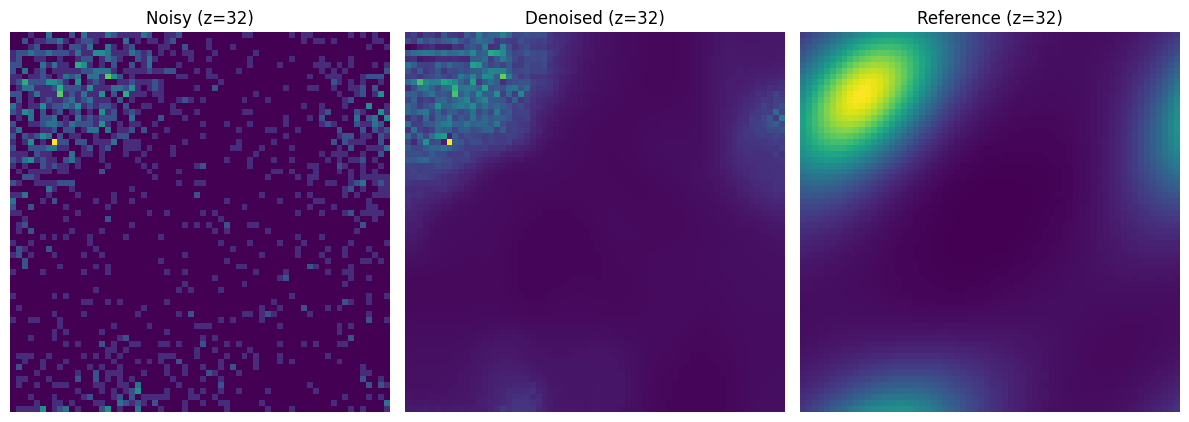


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000020480_bm3d_denoised.npy
Sample 20480 | bm3d JSD = 0.033719
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0125
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.021309

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0125
JSD   (noisy vs ref):     0.166613
JSD   (denoised vs ref):  0.021309


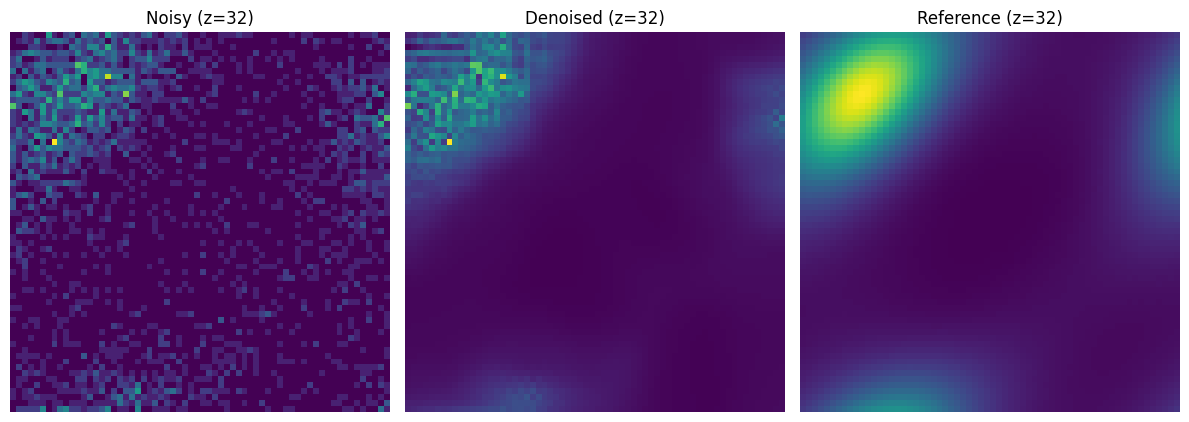


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000040960_bm3d_denoised.npy
Sample 40960 | bm3d JSD = 0.021309
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0105
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.013519

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0105
JSD   (noisy vs ref):     0.088605
JSD   (denoised vs ref):  0.013519


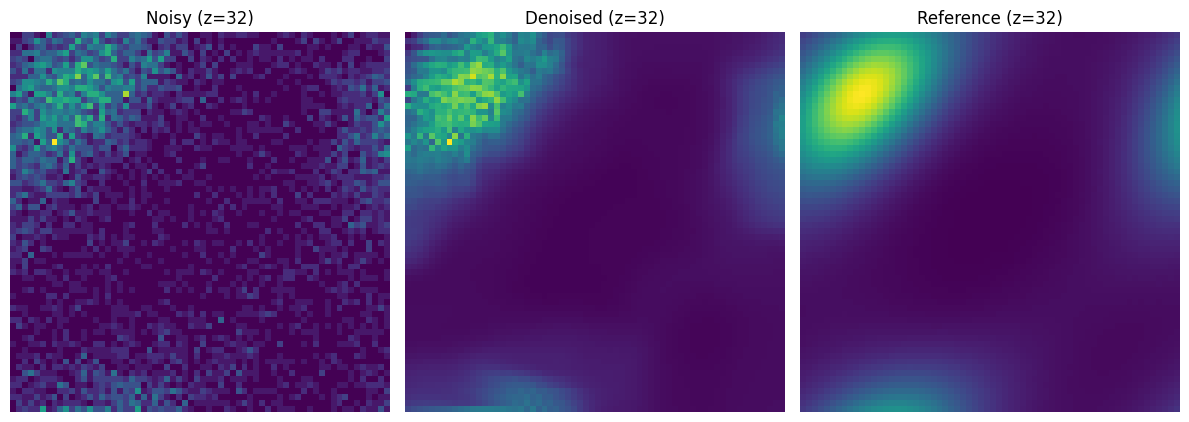


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000081920_bm3d_denoised.npy
Sample 81920 | bm3d JSD = 0.013519
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0083
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.009158

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0083
JSD   (noisy vs ref):     0.044269
JSD   (denoised vs ref):  0.009158


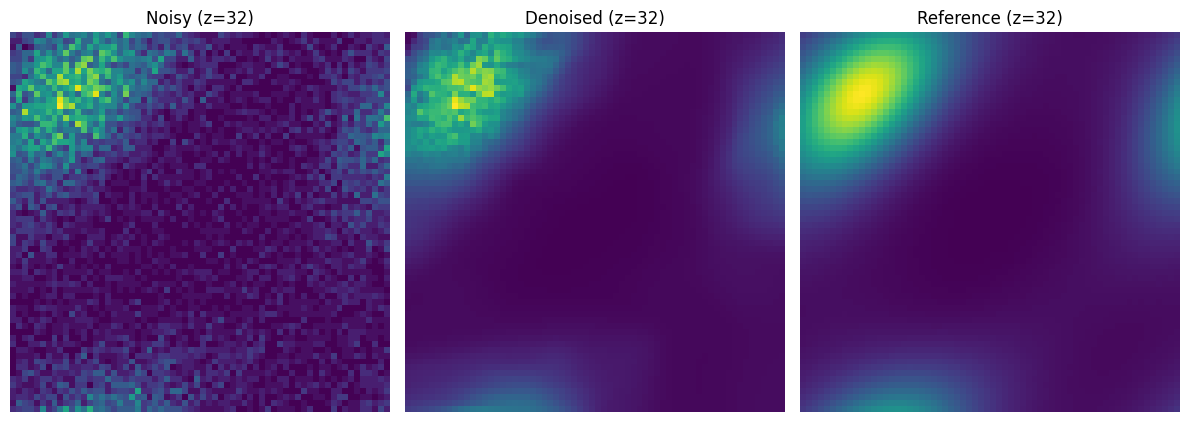


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000163840_bm3d_denoised.npy
Sample 163840 | bm3d JSD = 0.009158
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0062
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.006778

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0062
JSD   (noisy vs ref):     0.021132
JSD   (denoised vs ref):  0.006778


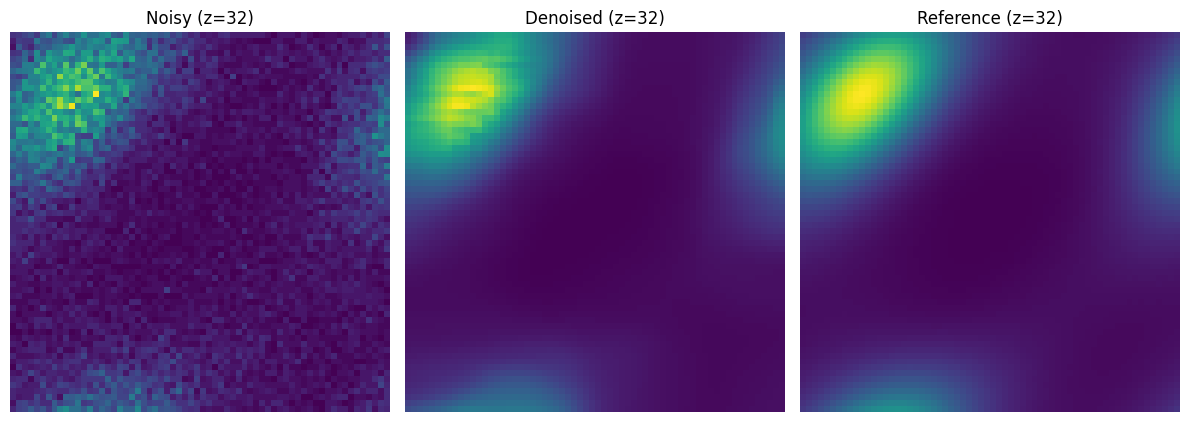


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000327680_bm3d_denoised.npy
Sample 327680 | bm3d JSD = 0.006778
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0054
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.005926

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0054
JSD   (noisy vs ref):     0.015695
JSD   (denoised vs ref):  0.005926


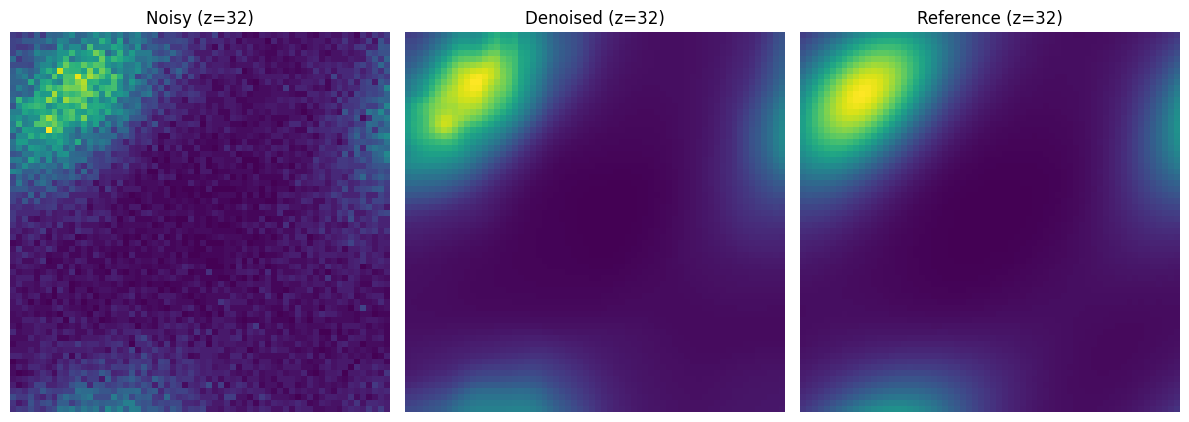


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000430080_bm3d_denoised.npy
Sample 430080 | bm3d JSD = 0.005926
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0043
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.004916

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0043
JSD   (noisy vs ref):     0.009897
JSD   (denoised vs ref):  0.004916


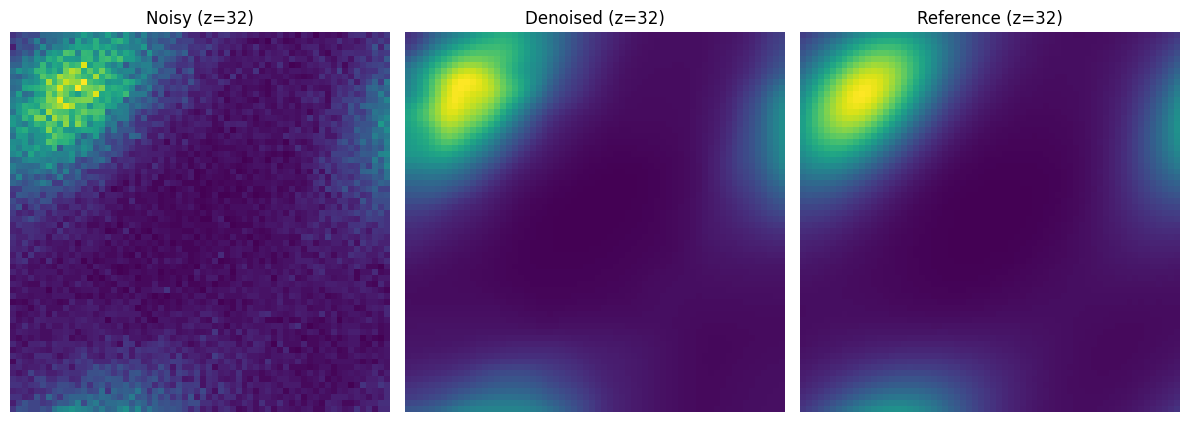


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360_bm3d_denoised.npy
Sample 655360 | bm3d JSD = 0.004916
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0039
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.004642

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0039
JSD   (noisy vs ref):     0.007465
JSD   (denoised vs ref):  0.004642


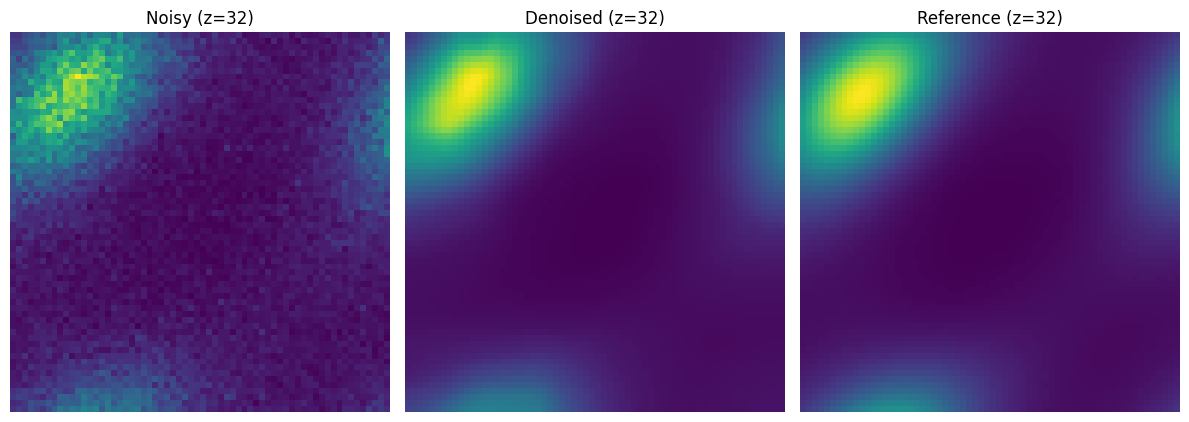


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000860160_bm3d_denoised.npy
Sample 860160 | bm3d JSD = 0.004642
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0032
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.004123

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0032
JSD   (noisy vs ref):     0.004798
JSD   (denoised vs ref):  0.004123


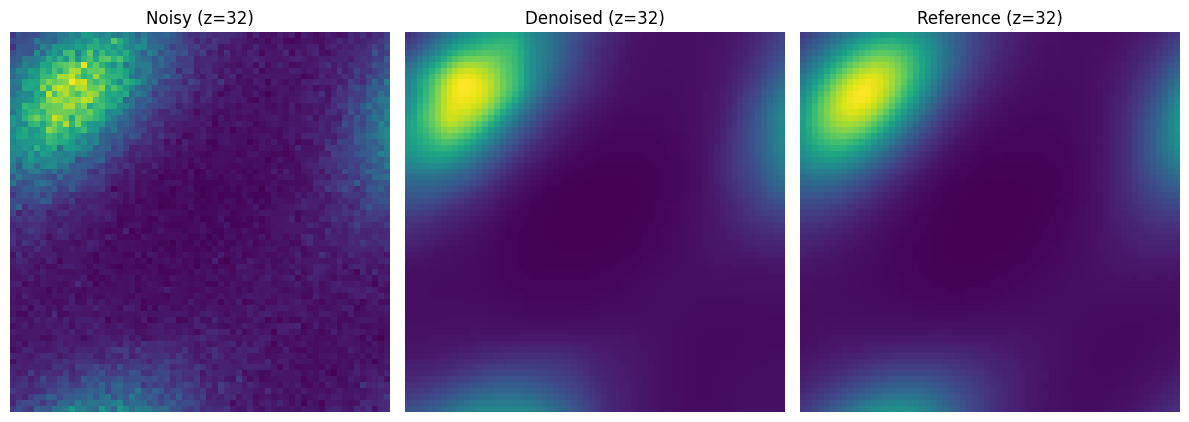


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001310720_bm3d_denoised.npy
Sample 1310720 | bm3d JSD = 0.004123
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0029
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.003421

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0029
JSD   (noisy vs ref):     0.003644
JSD   (denoised vs ref):  0.003421


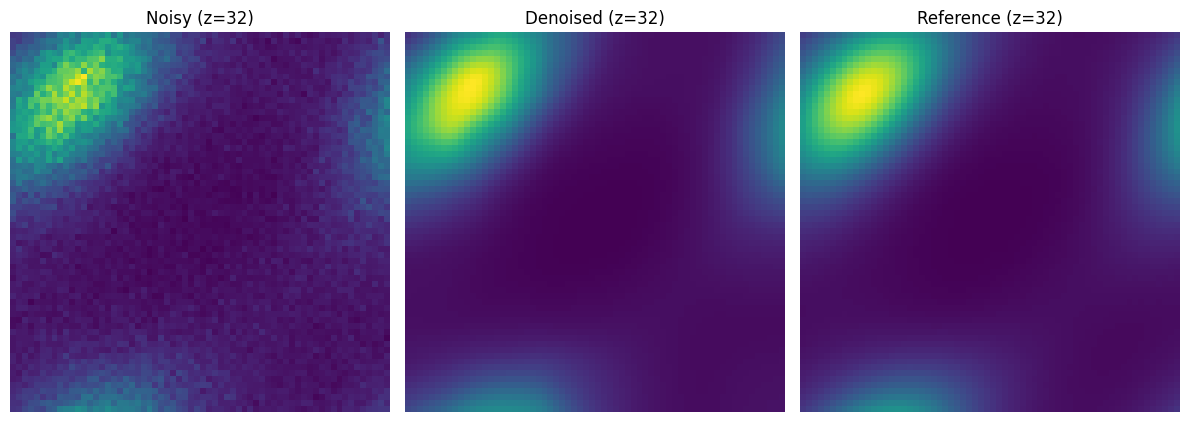


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0001720320_bm3d_denoised.npy
Sample 1720320 | bm3d JSD = 0.003421
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0023
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.002518

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0023
JSD   (noisy vs ref):     0.002372
JSD   (denoised vs ref):  0.002518


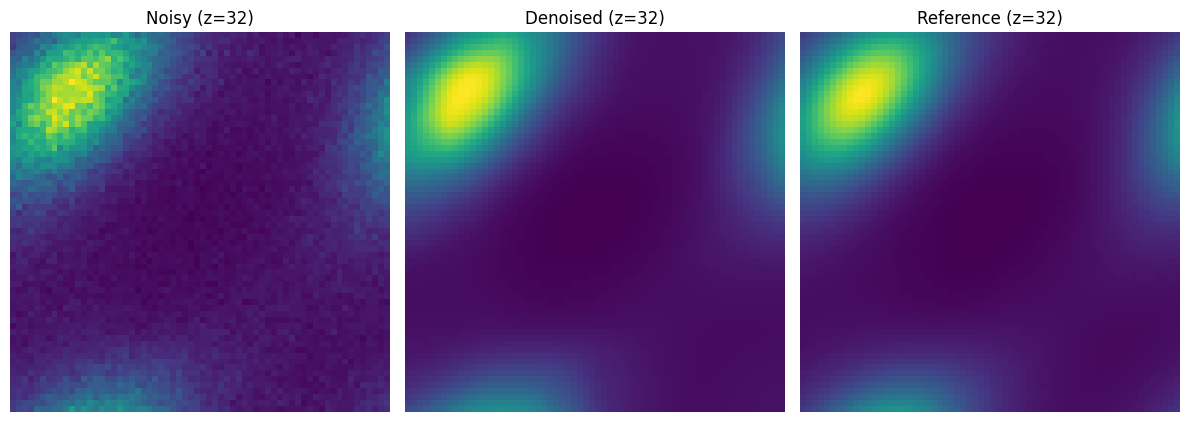


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0002621440_bm3d_denoised.npy
Sample 2621440 | bm3d JSD = 0.002518
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0020
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.002106

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0020
JSD   (noisy vs ref):     0.001803
JSD   (denoised vs ref):  0.002106


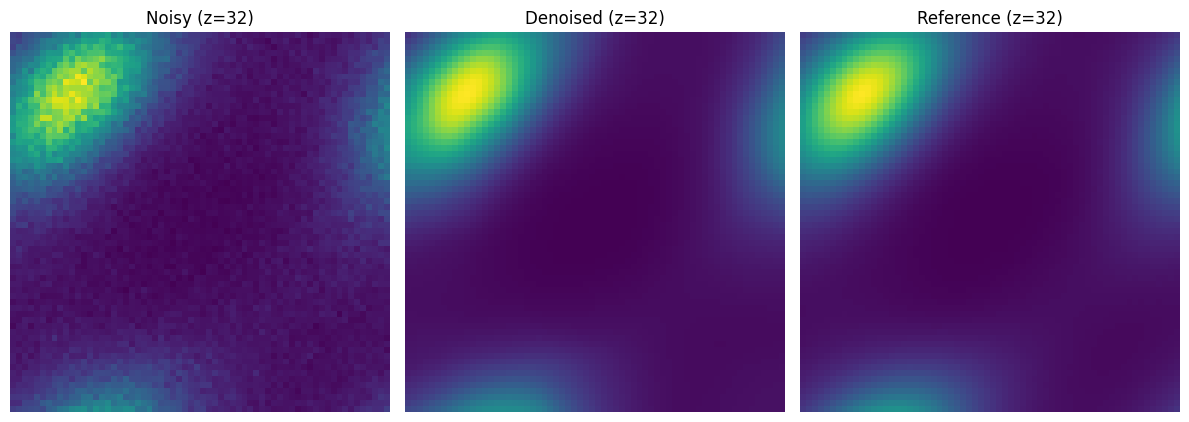


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0003440640_bm3d_denoised.npy
Sample 3440640 | bm3d JSD = 0.002106
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.001456

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.001201
JSD   (denoised vs ref):  0.001456


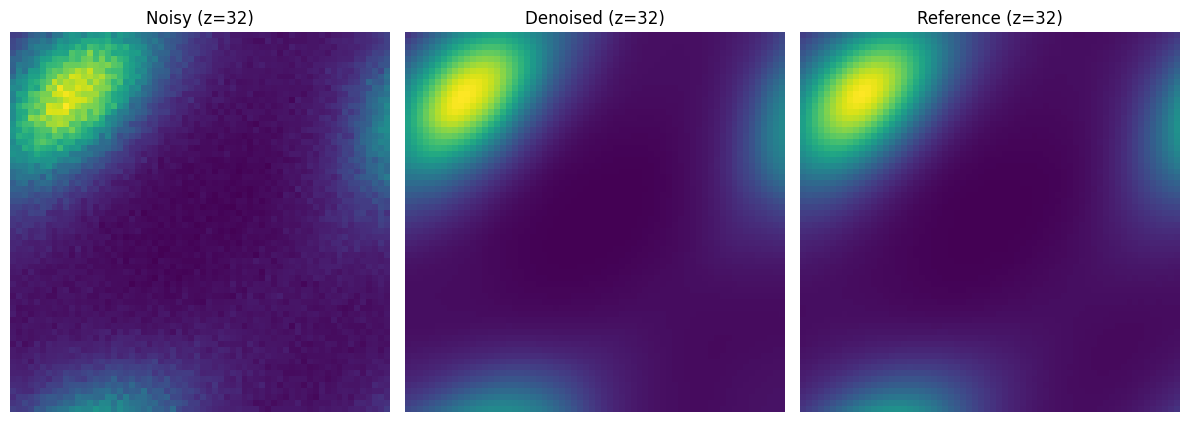


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005160960_bm3d_denoised.npy
Sample 5160960 | bm3d JSD = 0.001456
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.001371

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.001182
JSD   (denoised vs ref):  0.001371


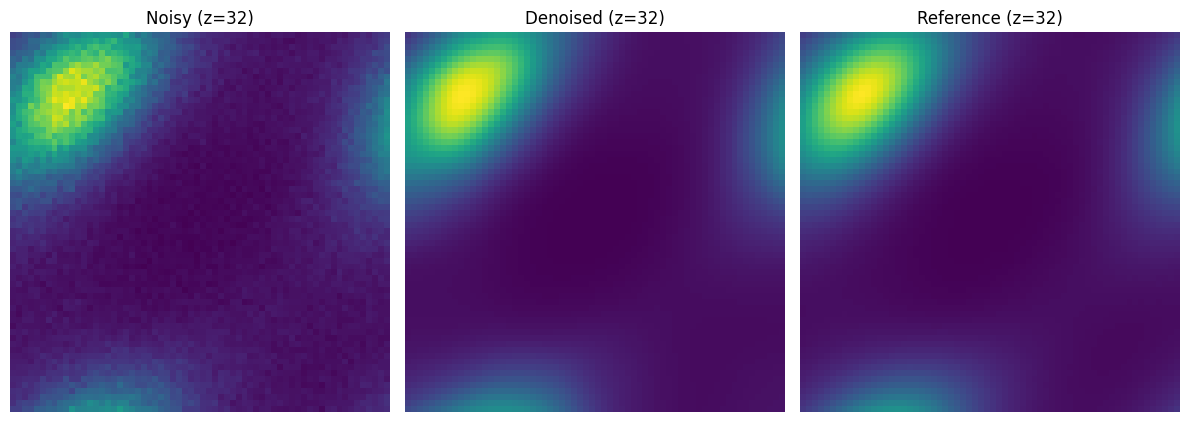


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0005242880_bm3d_denoised.npy
Sample 5242880 | bm3d JSD = 0.001371
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0015
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.001171

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0015
JSD   (noisy vs ref):     0.000899
JSD   (denoised vs ref):  0.001171


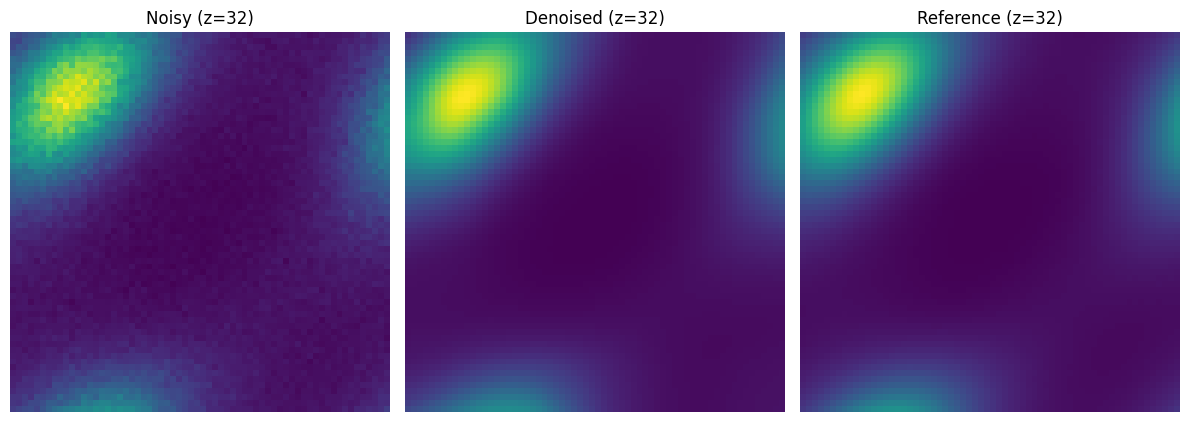


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0006881280_bm3d_denoised.npy
Sample 6881280 | bm3d JSD = 0.001171
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000790

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000790


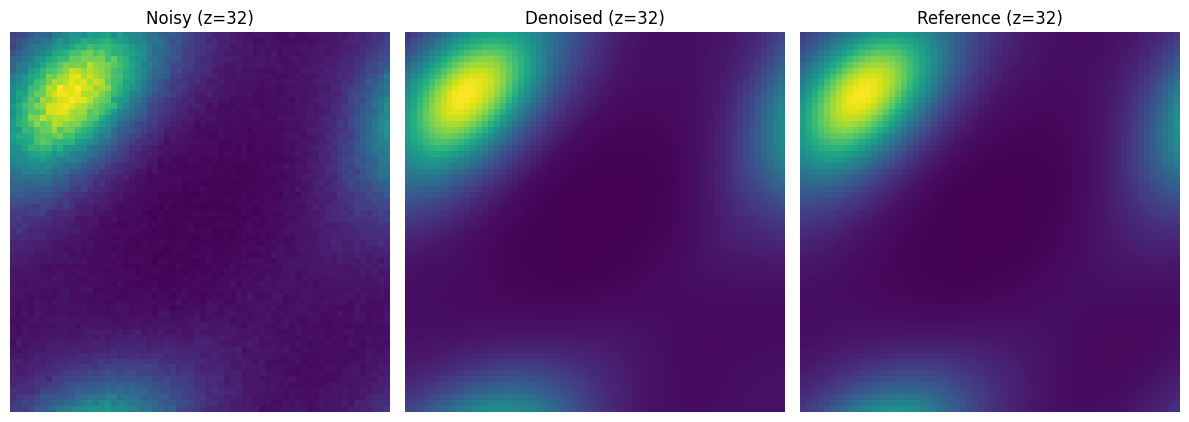


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010321920_bm3d_denoised.npy
Sample 10321920 | bm3d JSD = 0.000790
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000763

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000590
JSD   (denoised vs ref):  0.000763


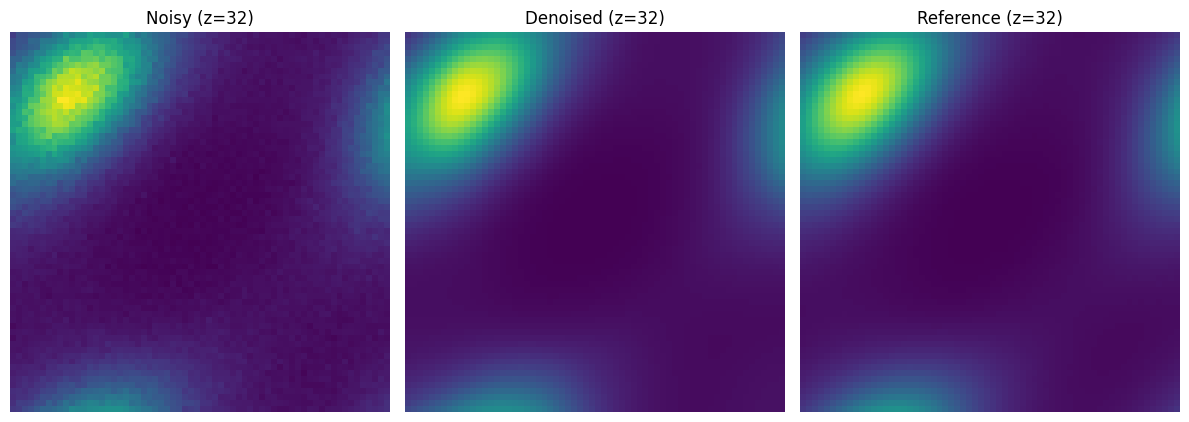


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0010485760_bm3d_denoised.npy
Sample 10485760 | bm3d JSD = 0.000763
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000648

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000449
JSD   (denoised vs ref):  0.000648


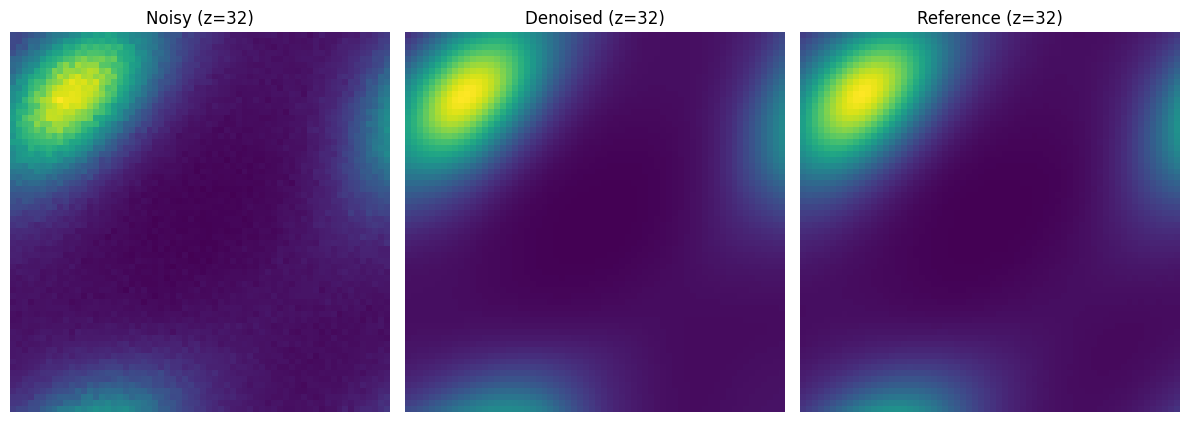


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0013762560_bm3d_denoised.npy
Sample 13762560 | bm3d JSD = 0.000648
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000438

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000438


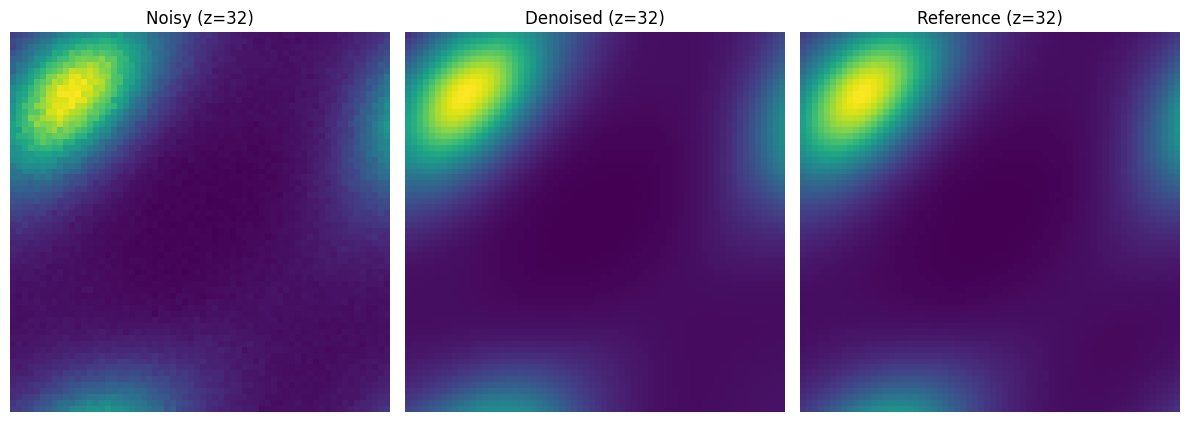


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0020643840_bm3d_denoised.npy
Sample 20643840 | bm3d JSD = 0.000438
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000334

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000225
JSD   (denoised vs ref):  0.000334


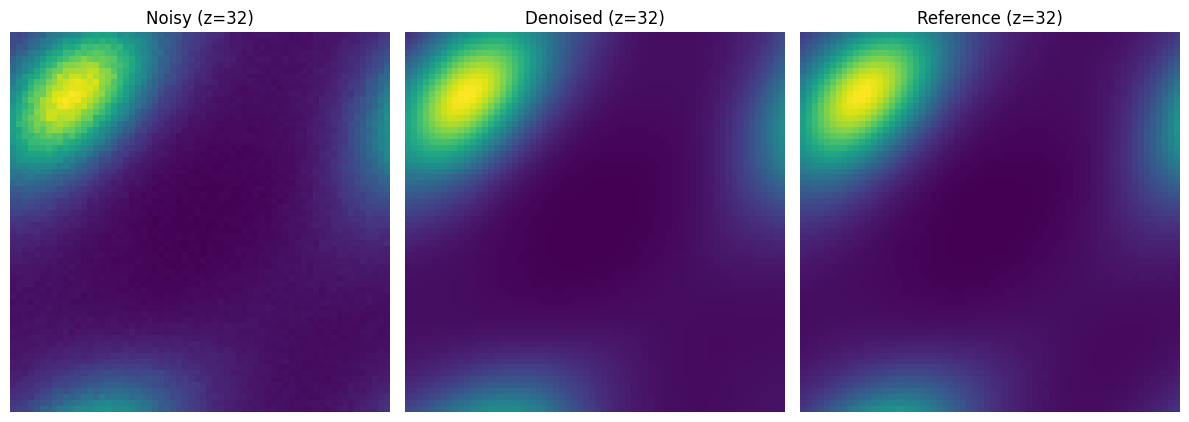


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0027525120_bm3d_denoised.npy
Sample 27525120 | bm3d JSD = 0.000334
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000263

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000150
JSD   (denoised vs ref):  0.000263


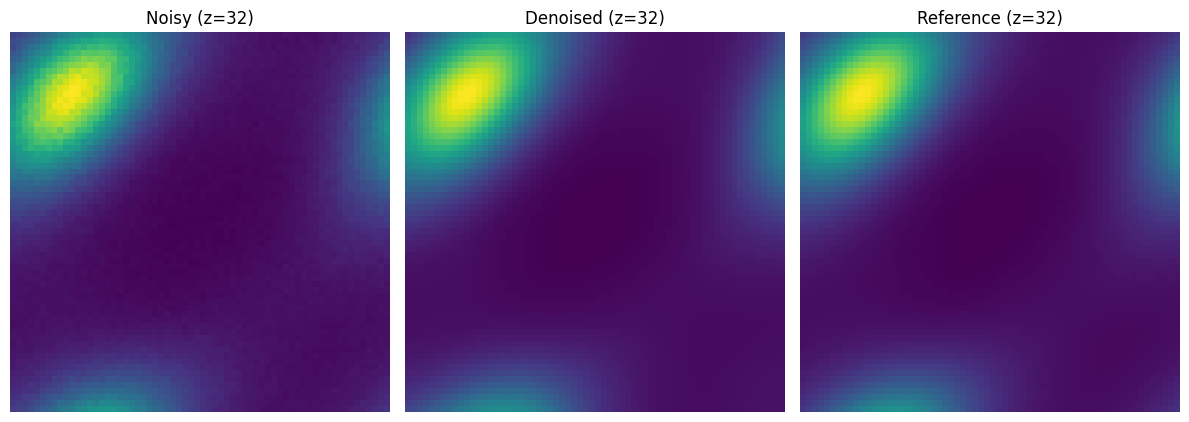


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0041287680_bm3d_denoised.npy
Sample 41287680 | bm3d JSD = 0.000263
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000214

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000113
JSD   (denoised vs ref):  0.000214


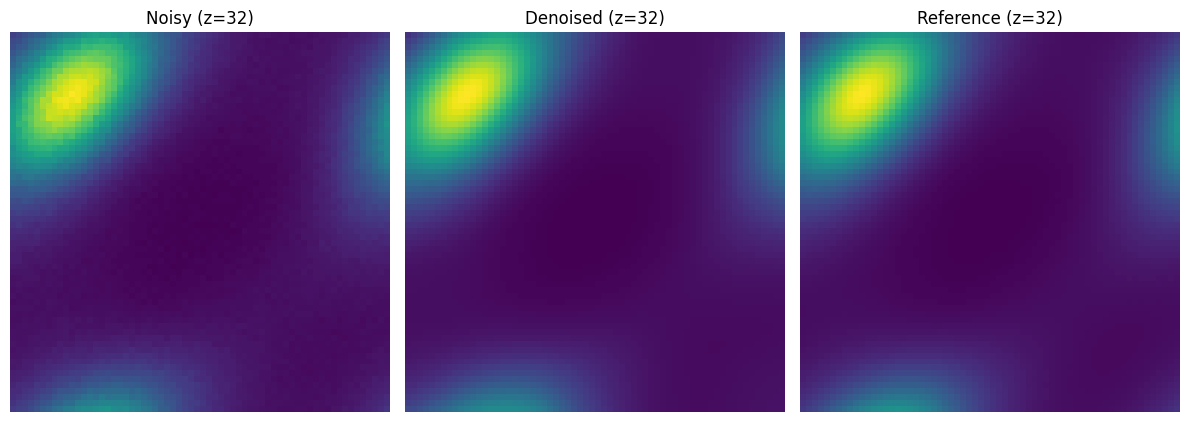


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0055050240_bm3d_denoised.npy
Sample 55050240 | bm3d JSD = 0.000214
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000179

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000179


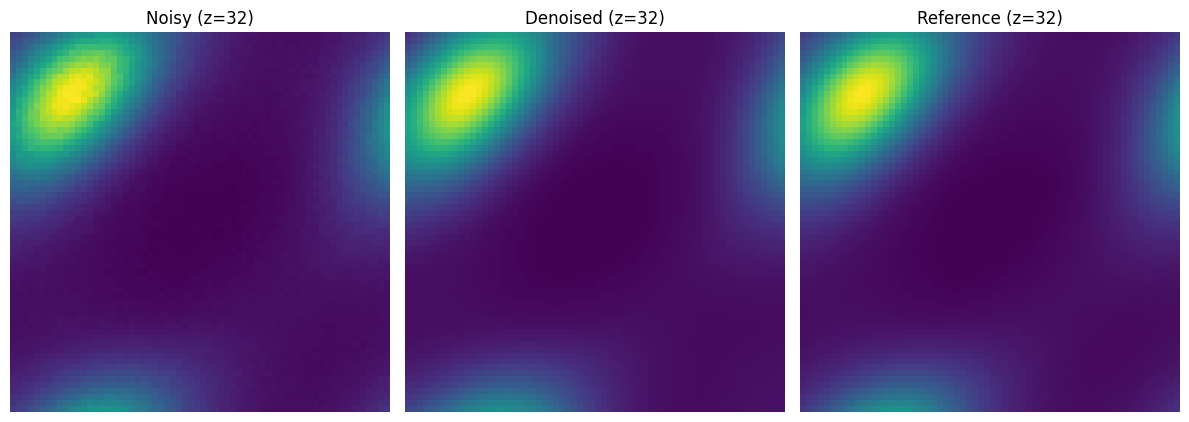


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0082575360_bm3d_denoised.npy
Sample 82575360 | bm3d JSD = 0.000179
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000152

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000152


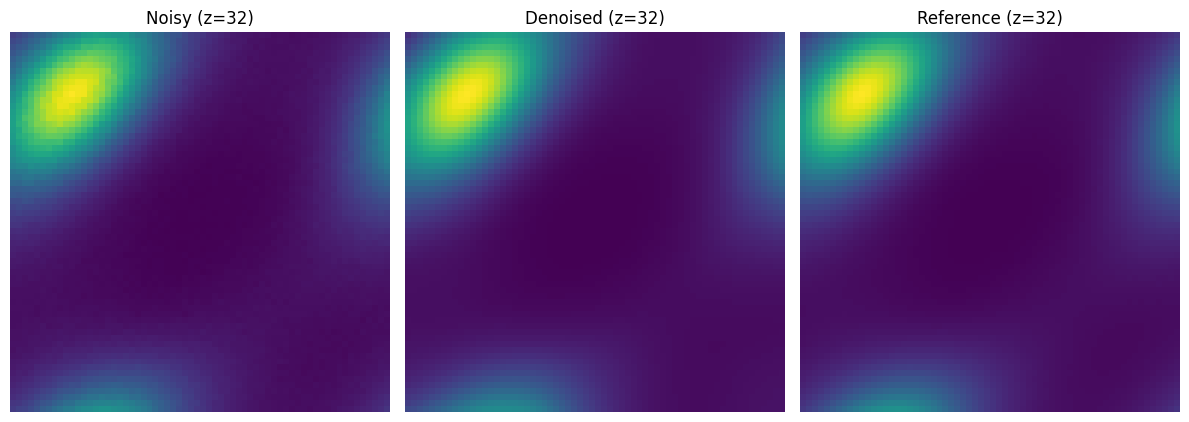


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0110100480_bm3d_denoised.npy
Sample 110100480 | bm3d JSD = 0.000152
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000133

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000038
JSD   (denoised vs ref):  0.000133


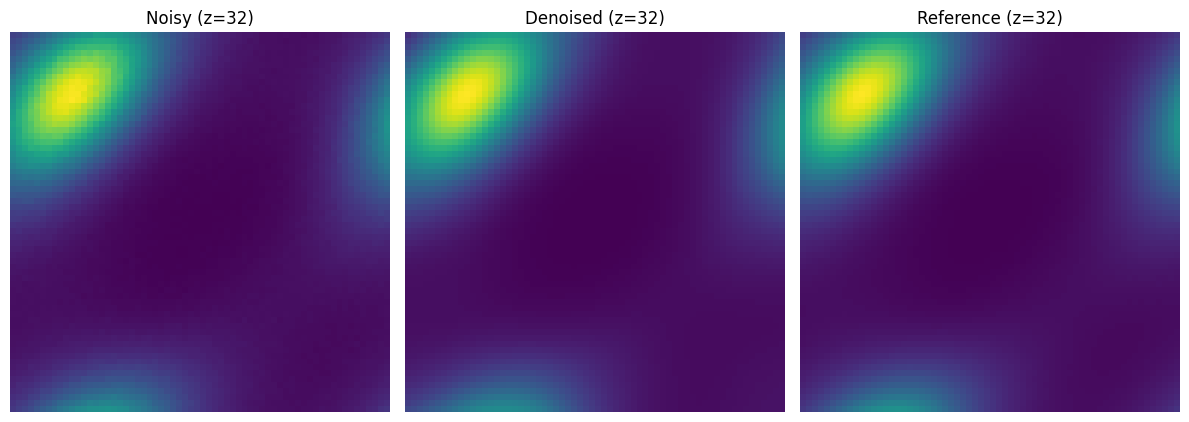


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0165150720_bm3d_denoised.npy
Sample 165150720 | bm3d JSD = 0.000133
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000125

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000125


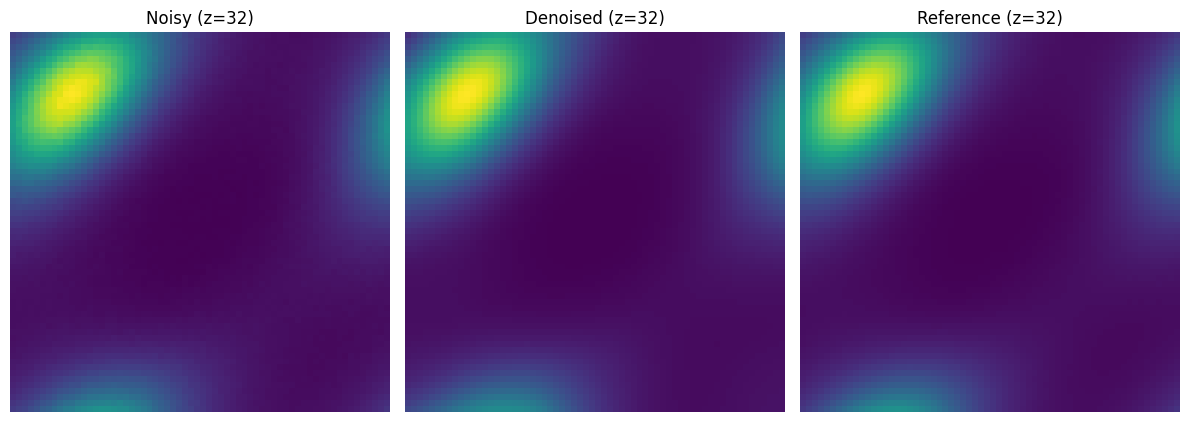


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0220200960_bm3d_denoised.npy
Sample 220200960 | bm3d JSD = 0.000125
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000115

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000115


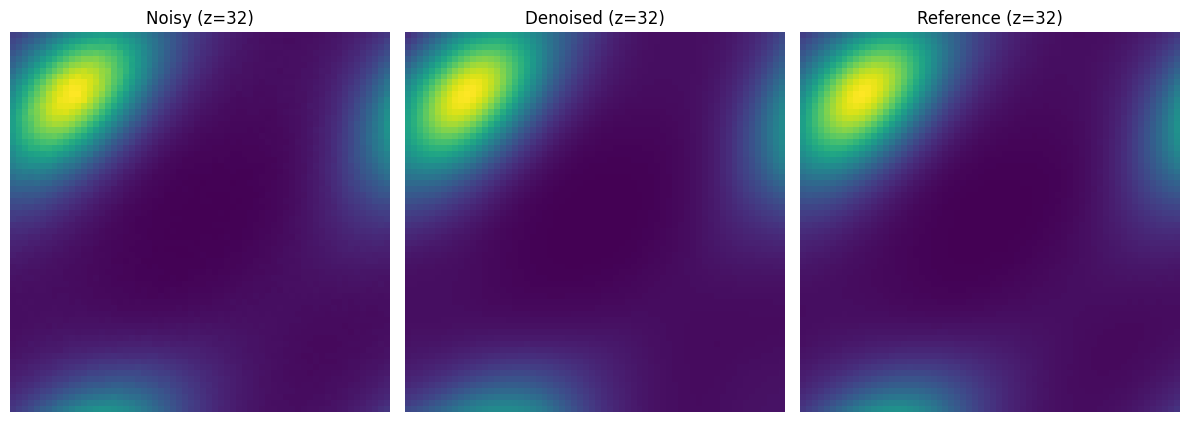


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0330301440_bm3d_denoised.npy
Sample 330301440 | bm3d JSD = 0.000115
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.000111

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.000111


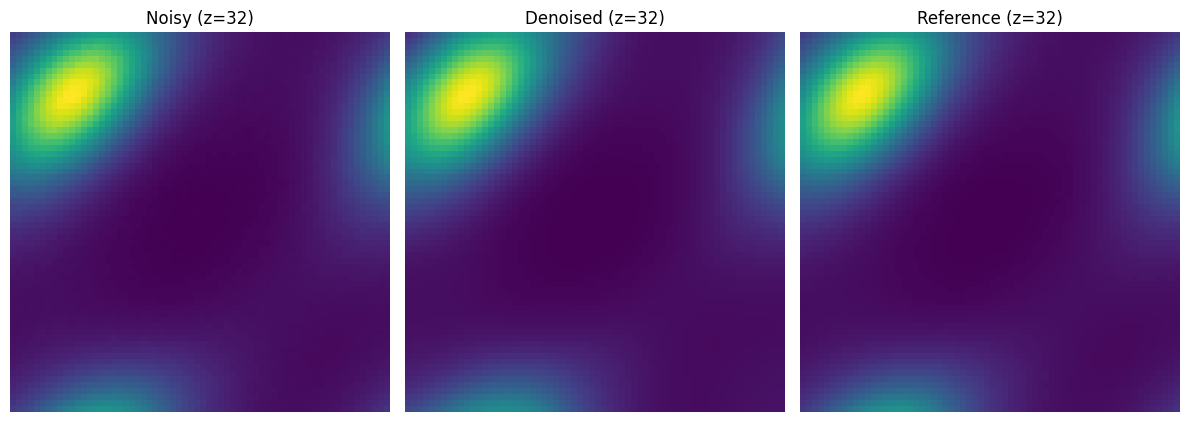


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0440401920_bm3d_denoised.npy
Sample 440401920 | bm3d JSD = 0.000111
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.000106

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.000106


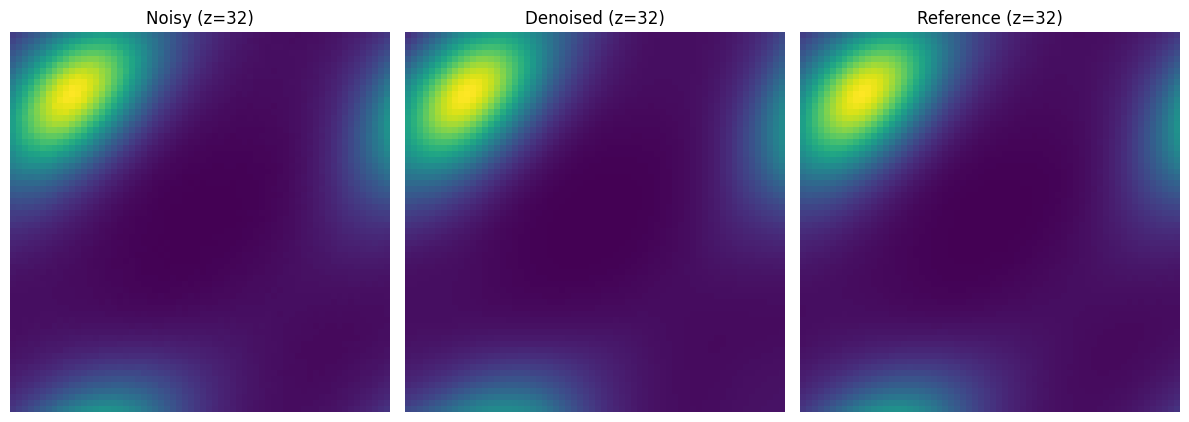


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0660602880_bm3d_denoised.npy
Sample 660602880 | bm3d JSD = 0.000106
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000104

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000104


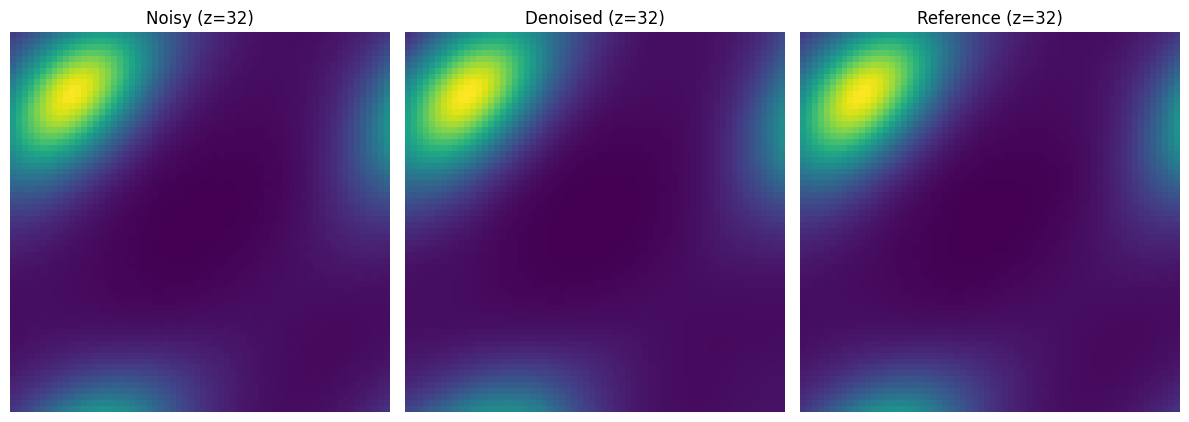


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_1321205760_bm3d_denoised.npy
Sample 1321205760 | bm3d JSD = 0.000104
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000103

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000103


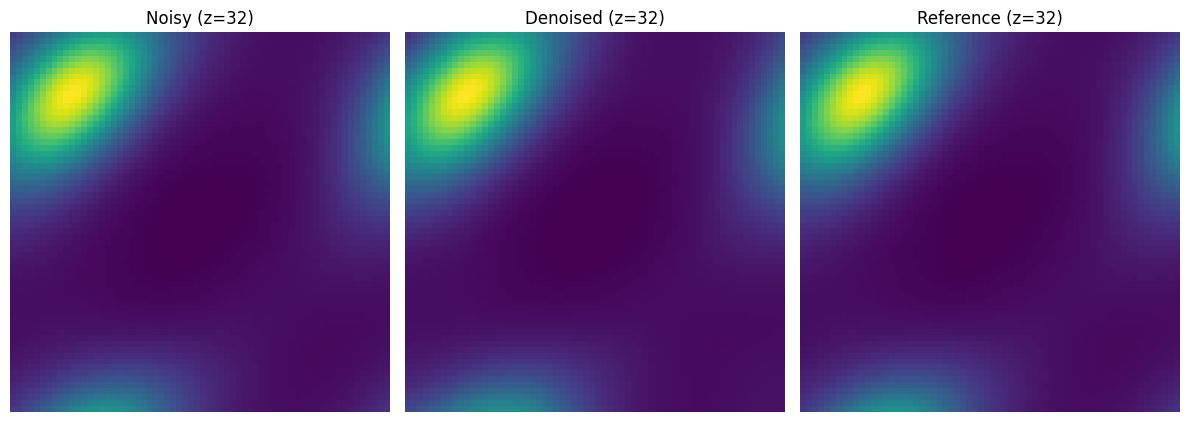


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_2642411520_bm3d_denoised.npy
Sample 2642411520 | bm3d JSD = 0.000103
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000103

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000103


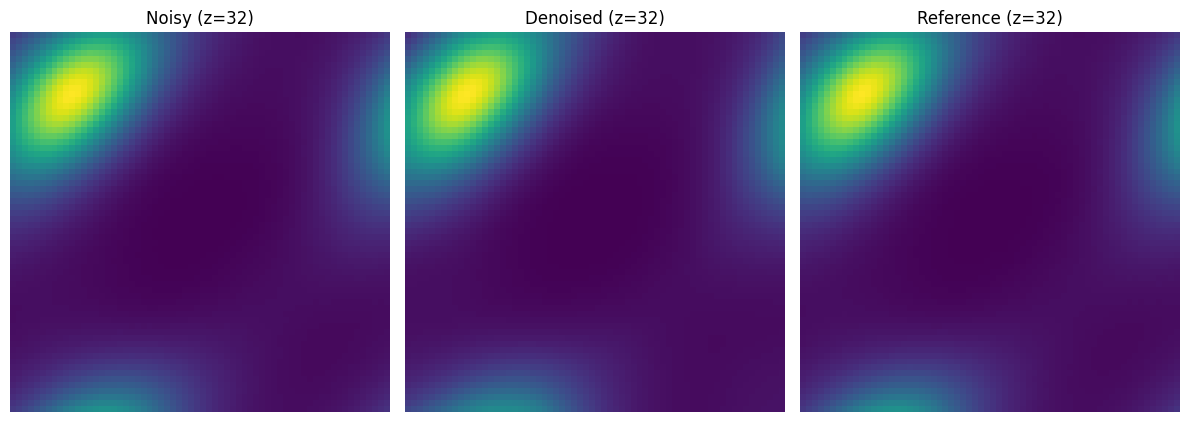


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_5284823040_bm3d_denoised.npy
Sample 5284823040 | bm3d JSD = 0.000103


In [24]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py

# ================= CPU-loading patch =================
_original_torch_load = torch.load
def torch_load_cpu(*args, **kwargs):
    if 'map_location' not in kwargs:
        kwargs['map_location'] = torch.device('cpu')
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_cpu

# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

models = [
    'scunet_trained',
    'scunet_pre',
    'scunet_ft',
    'nature',
    'CAE',
    'bm3d'
]

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ================= Run models =================
results_dict = {model: [] for model in models}

for model_name in models:
    print(f"\n=== Running model: {model_name} ===")

    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        output_file = os.path.splitext(os.path.basename(noisy_path))[0] + f"_{model_name}_denoised.npy"
        output_path = os.path.join(base_dir, output_file)

        denoised_den, jsd = run_denoising_pipeline(
            noisy_path,
            ref_path,
            model_name,
            output_file=output_path
        )

        results_dict[model_name].append((sample_num, jsd))
        print(f"Sample {sample_num} | {model_name} JSD = {jsd:.6f}")


In [25]:
import pandas as pd
df = pd.DataFrame(results_dict)
df.to_csv(model_samp+'_jsd_results_Full_noJ.csv', index=False)

print("Dictionary saved to results.csv")

Dictionary saved to results.csv


In [33]:
# ==== Reference JSD ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

In [34]:
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   

1.163116475064597e-06


In [35]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")





Found 33 noisy files.


In [36]:
import sys
import os
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


def div_js_dens(d1,d2):
    return D_JS(d1,d2)

model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d_full,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.00030547353158246447)), (20480, np.float64(0.0007193732675364871)), (40960, np.float64(0.000403883028636078)), (81920, np.float64(0.0002952493130213089)), (163840, np.float64(0.0002045092466274725)), (327680, np.float64(0.00010658820088579176)), (430080, np.float64(9.763654094806284e-05)), (655360, np.float64(5.626747728210412e-05)), (860160, np.float64(4.9503366189086714e-05)), (1310720, np.float64(3.9755254999375065e-05)), (1720320, np.float64(3.1669619194730114e-05)), (2621440, np.float64(2.2293148124423583e-05)), (3440640, np.float64(1.4951343920755806e-05)), (5160960, np.float64(1.1179644963263583e-05)), (5242880, np.float64(1.0923976287894798e-05)), (6881280, np.float64(7.67627580316259e-06)), (10321920, np.float64(8.359625987867603e-06)), (10485760, np.float64(5.6298681494378945e-06)), (13762560, np.float64(4.311085557613106e-06)), (20643840, np.float64(3.883544787977135e-06)), (27525120, np.float64(2.3791048082557056e-06)), (41287680, np.float64(2.41658717

In [37]:
import sys
import os
import h5py
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

ref_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5' #DFT
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.0002970744382134194)), (20480, np.float64(0.0007205100140901808)), (40960, np.float64(0.00040925875051319783)), (81920, np.float64(0.00029391249599870653)), (163840, np.float64(0.0002054001151567304)), (327680, np.float64(0.00010781193200350893)), (430080, np.float64(9.8702607532391e-05)), (655360, np.float64(5.727266189527444e-05)), (860160, np.float64(5.05874174749892e-05)), (1310720, np.float64(4.084120408324323e-05)), (1720320, np.float64(3.2870745908659405e-05)), (2621440, np.float64(2.3541685152622345e-05)), (3440640, np.float64(1.586999775298345e-05)), (5160960, np.float64(1.2341859667262089e-05)), (5242880, np.float64(1.2092527162038452e-05)), (6881280, np.float64(8.831812972066427e-06)), (10321920, np.float64(8.597730768827948e-06)), (10485760, np.float64(6.782759517112403e-06)), (13762560, np.float64(5.415873657192549e-06)), (20643840, np.float64(4.99862653452808e-06)), (27525120, np.float64(3.550556297431784e-06)), (41287680, np.float64(3.54109954810579

In [38]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   


1.163116475064597e-06


<Figure size 800x500 with 0 Axes>

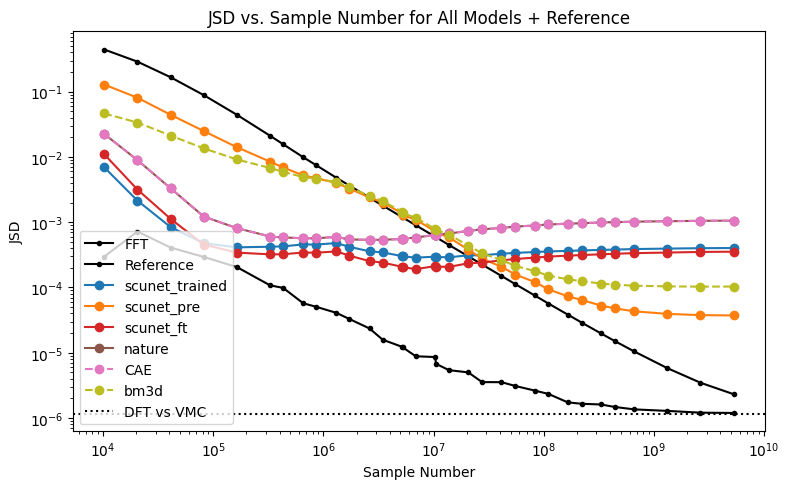

In [39]:
# ================= Plot =================
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))
x_values, y_values = zip(*model_results_FFT)
# === Plot ===
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))

plt.loglog(x_values, y_values,
           marker=".",             # Dot markers
           linestyle="-",          # Solid connecting line
           color="black", 
           label="FFT")
colors = plt.cm.tab10(np.linspace(0, 1, len(models) + 1))  # +1 for ref

# Plot reference first
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot each model
for color, model_name in zip(colors, models):
    results_array = np.array(sorted(results_dict[model_name], key=lambda x: x[0]))
    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"  # dotted for some
    plt.loglog(results_array[:, 0], results_array[:, 1],
               marker="o", linestyle=linestyle, label=model_name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs VMC")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
print("here")

here


In [41]:
import numpy as np

# Convert dict-of-pairs into dict-of-arrays so it saves cleanly
results_dict_arrays = {
    name: np.array(sorted(results_dict[name], key=lambda x: x[0]), dtype=float)
    for name in models
}

np.savez_compressed(
    "jsd_plot_data_full_range_noJ.npz",
    model_results_FFT=np.array(model_results_FFT, dtype=float),
    results_array_ref=np.array(results_array_ref, dtype=float),
    models=np.array(models),
    DFT_vs_VMC=float(DFT_vs_VMC),
    **{f"results_{k}": v for k, v in results_dict_arrays.items()}
)


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import logging
data = np.load("jsd_plot_data_full_range_noJ.npz", allow_pickle=True)

model_results_FFT = [tuple(x) for x in data["model_results_FFT"]]
results_array_ref = data["results_array_ref"]
models = list(data["models"])
DFT_vs_VMC = float(data["DFT_vs_VMC"])

results_dict = {m: data[f"results_{m}"] for m in models}  # each is an (N,2) array

# Reconstruct variables
model_results_FFT = [tuple(x) for x in data["model_results_FFT"]]
results_array_ref = data["results_array_ref"]
models = list(data["models"])
DFT_vs_VMC = float(data["DFT_vs_VMC"])

# Rebuild results_dict (each entry is (N,2))
results_dict = {m: data[f"results_{m}"] for m in models}



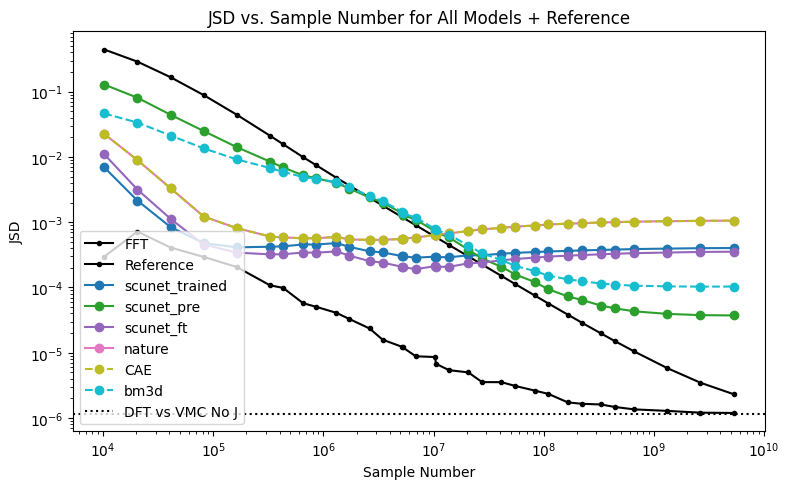

In [43]:
# ================= Plot =================
logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(8, 5))

# ---- FFT curve ----
x_values, y_values = zip(*model_results_FFT)
plt.loglog(
    x_values,
    y_values,
    marker=".",
    linestyle="-",
    color="black",
    label="FFT",
)

# ---- Reference curve ----
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker=".",
    linestyle="-",
    color="black",
    label="Reference",
)

# ---- Model curves ----
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]

    # Ensure sorted by sample number
    results_array = results_array[np.argsort(results_array[:, 0])]

    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker="o",
        linestyle=linestyle,
        label=model_name,
        color=color,
    )

# ---- Decorations ----
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    label="DFT vs VMC No J",
)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()
